In [1]:
# ============================================================
# CELL 1 : Setup, Imports & Global Config
# ============================================================
import os, gc, glob, time, warnings, math, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---------- إعدادات التحكم في الحجم (مهمة جداً مع 1M+ صف) ----------
FAST_MODE      = True        # True = تدريب على عينة (موصى به أول مرة) | False = الداتا كاملة
MAX_TRAIN_ROWS = 300_000     # أقصى عدد صفوف للنمذجة الأساسية
SAMPLE_SVM_KNN = 40_000      # عينة النماذج البطيئة (SVM-RBF / KNN)
SAMPLE_GB      = 120_000     # عينة GradientBoosting التقليدي (بطيء)
SAMPLE_CLUSTER = 60_000      # عينة التجميع
SAMPLE_HIER    = 8_000       # عينة Hierarchical (O(n²) ذاكرة)
TEST_SIZE      = 0.2

# ---------- مكتبات اختيارية (متاحة على Kaggle غالباً) ----------
HAS_LGB = HAS_XGB = HAS_CAT = HAS_IMB = False
try:
    import lightgbm as lgb;         HAS_LGB = True
except Exception: pass
try:
    import xgboost as xgb;          HAS_XGB = True
except Exception: pass
try:
    from catboost import CatBoostClassifier, CatBoostRegressor; HAS_CAT = True
except Exception: pass
try:
    from imblearn.over_sampling import SMOTE; HAS_IMB = True
except Exception: pass

print(f"LightGBM={HAS_LGB} | XGBoost={HAS_XGB} | CatBoost={HAS_CAT} | imblearn={HAS_IMB}")

import sklearn
print("sklearn:", sklearn.__version__)

LightGBM=True | XGBoost=True | CatBoost=True | imblearn=True
sklearn: 1.6.1


In [2]:
# ============================================================
# CELL 2 : Load Dataset (auto-detect CSV inside /kaggle/input)
# ============================================================
csv_files = glob.glob("/kaggle/input/**/*.csv", recursive=True)
print("الملفات الموجودة:")
for f in csv_files:
    print(f"  - {f}  ({os.path.getsize(f)/1e6:.1f} MB)")

assert len(csv_files) > 0, "ارفعي الداتا سِت من Add Data أولاً"

# نختار أكبر ملف (هو ملف الـ 1M عادةً)
DATA_PATH = max(csv_files, key=os.path.getsize)
print("\n>>> سيتم استخدام:", DATA_PATH)

t0 = time.time()
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"تم التحميل في {time.time()-t0:.1f} ثانية")
print("Shape:", df_raw.shape)
df_raw.head()

الملفات الموجودة:
  - /kaggle/input/datasets/isandeep06/customer-churn-prediction-dataset-1m/customer_churn_1M.csv  (170.5 MB)

>>> سيتم استخدام: /kaggle/input/datasets/isandeep06/customer-churn-prediction-dataset-1m/customer_churn_1M.csv
تم التحميل في 6.4 ثانية
Shape: (1000000, 32)


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,payment_method,paperless_billing,senior_citizen,monthlycharges,totalcharges,num_services,has_phone_service,has_internet_service,has_online_security,has_online_backup,has_device_protection,has_tech_support,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,electronic_check,Yes,0,67.20,144.39,1,1,1,0,0,1,1,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,bank_transfer,Yes,0,71.54,1602.22,2,0,1,0,1,0,0,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,credit_card,No,0,112.20,328.81,4,1,1,0,0,1,1,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,bank_transfer,Yes,0,107.49,643.45,3,1,1,0,0,1,1,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,credit_card,Yes,0,110.05,648.79,3,0,1,0,0,0,0,0,1,8.0,1.0,1,0,16.74,18,657.0,0


In [3]:
# ============================================================
# CELL 3 : Inspection + Memory Optimization
# ============================================================
def reduce_mem(df, verbose=True):
    start = df.memory_usage(deep=True).sum()/1024**2
    for c in df.columns:
        t = df[c].dtype
        if pd.api.types.is_integer_dtype(t):
            df[c] = pd.to_numeric(df[c], downcast="integer")
        elif pd.api.types.is_float_dtype(t):
            df[c] = pd.to_numeric(df[c], downcast="float")
        elif t == object:
            if df[c].nunique(dropna=False) / max(len(df),1) < 0.5:
                df[c] = df[c].astype("category")
    end = df.memory_usage(deep=True).sum()/1024**2
    if verbose: print(f"Memory: {start:.1f} MB -> {end:.1f} MB ({100*(start-end)/start:.1f}% أقل)")
    return df

print("### Info ###")
df_raw.info(show_counts=True)

print("\n### Missing Values ###")
miss = df_raw.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
display(miss.to_frame("missing").assign(pct=lambda d: (d.missing/len(df_raw)*100).round(2)))

print("\n### Duplicates ###", df_raw.duplicated().sum())

print("\n### Cardinality (Unique per column) ###")
card = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "nunique": df_raw.nunique(dropna=False),
    "missing_%": (df_raw.isna().mean()*100).round(2),
    "sample": [df_raw[c].dropna().iloc[0] if df_raw[c].notna().any() else None for c in df_raw.columns]
}).sort_values("nunique")
display(card)

df = reduce_mem(df_raw.copy())
del df_raw; gc.collect()

### Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  object 
 1   signup_date                  1000000 non-null  object 
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  object 
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  object 
 6   marital_status               1000000 non-null  object 
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  object 
 10  payment_method               1000000 non-null  object 
 11  paperless_billing            1000000 non-null  object 
 12  senior_citizen               1

,missing,pct
avg_monthly_gb,50012,5.00
credit_score,40395,4.04
annual_income,29959,3.00
num_complaints,29906,2.99
customer_satisfaction,19921,1.99



### Duplicates ### 0

### Cardinality (Unique per column) ###


,dtype,nunique,missing_%,sample
senior_citizen,int64,2,0.00,0
paperless_billing,object,2,0.00,Yes
has_tech_support,int64,2,0.00,1
has_device_protection,int64,2,0.00,1
has_online_backup,int64,2,0.00,0
has_online_security,int64,2,0.00,0
has_internet_service,int64,2,0.00,1
churn,int64,2,0.00,0
has_streaming_movies,int64,2,0.00,1
has_streaming_tv,int64,2,0.00,1


Memory: 636.6 MB -> 185.0 MB (70.9% أقل)


0

In [4]:
# ============================================================
# CELL 4 : Auto-detect Targets, IDs, Constants & Leakage columns
# ============================================================
# ---- لو عرفتي أسماء الأعمدة بعد Cell 3 اكتبيها هنا يدوياً (الأفضل) ----
CLF_TARGET = None    # مثال: "Churn"
REG_TARGET = None    # مثال: "MonthlyCharges" أو "TotalCharges"

cols = list(df.columns)
low  = {c: c.lower().replace(" ", "").replace("_", "") for c in cols}

# 1) هدف التصنيف: أي عمود فيه كلمة churn / exited / attrition
if CLF_TARGET is None:
    cand = [c for c in cols if any(k in low[c] for k in ["churn", "exited", "attrition", "target", "label"])]
    cand = [c for c in cand if df[c].nunique(dropna=True) <= 5]           # لازم binary
    cand = [c for c in cand if "reason" not in low[c] and "score" not in low[c]]
    CLF_TARGET = cand[0] if cand else None
assert CLF_TARGET is not None, f"لم أجد عمود Churn — اكتبيه يدوياً. الأعمدة: {cols}"

# 2) هدف الانحدار: عمود رقمي مستمر (فواتير / استهلاك / رصيد)
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
if REG_TARGET is None:
    kw = ["cltv","lifetimevalue","totalcharge","monthlycharge","charges","revenue","spend",
          "bill","amount","balance","usage","datausage","minutes","payment","salary","value"]
    ranked = []
    for c in num_cols_all:
        if c == CLF_TARGET: continue
        if df[c].nunique() < 50: continue                                  # نتجنب الأعمدة الفئوية المشفرة
        score = sum(10 for k in kw if k in low[c]) + min(df[c].nunique()/len(df), 1)
        ranked.append((score, c))
    ranked.sort(reverse=True)
    REG_TARGET = ranked[0][1] if ranked else None
assert REG_TARGET is not None, "لم أجد عمود رقمي مناسب للانحدار — اختاريه يدوياً"

# 3) أعمدة يجب حذفها: IDs / ثوابت / نصوص عالية التفرد (leakage / noise)
id_like    = [c for c in cols if df[c].nunique() > 0.95*len(df) or
              any(k in low[c] for k in ["id","customerid","uuid","index","unnamed"])]
constants  = [c for c in cols if df[c].nunique(dropna=False) <= 1]
leakage    = [c for c in cols if any(k in low[c] for k in ["churnreason","churnscore","churnvalue","churnlabel"])
              and c != CLF_TARGET]
DROP_COLS  = sorted(set(id_like + constants + leakage))

print("🎯 Classification Target :", CLF_TARGET, "->", dict(df[CLF_TARGET].value_counts(dropna=False)))
print("📈 Regression  Target    :", REG_TARGET, "-> mean =", round(float(df[REG_TARGET].mean()),2))
print("🗑️  Dropped columns      :", DROP_COLS)

# ---- تحويل هدف التصنيف لـ 0/1 ----
y_map_used = None
if df[CLF_TARGET].dtype.name in ("object", "category", "bool"):
    vals = df[CLF_TARGET].astype(str).str.strip().str.lower()
    pos  = {"yes","true","1","churn","churned","y","left","exited"}
    df["_CHURN_"] = vals.isin(pos).astype("int8")
    y_map_used = "text -> 1 if in {yes,true,1,churn,...}"
else:
    df["_CHURN_"] = (df[CLF_TARGET] > 0).astype("int8")
    y_map_used = "numeric > 0 -> 1"

churn_rate = df["_CHURN_"].mean()
print(f"\nMapping: {y_map_used}")
print(f"Churn Rate = {churn_rate:.2%}  | Imbalance Ratio = 1:{(1-churn_rate)/max(churn_rate,1e-9):.1f}")

🎯 Classification Target : churn -> {0: np.int64(900773), 1: np.int64(99227)}
📈 Regression  Target    : totalcharges -> mean = 1837.32
🗑️  Dropped columns      : ['customer_id', 'signup_date']

Mapping: numeric > 0 -> 1
Churn Rate = 9.92%  | Imbalance Ratio = 1:9.1


In [5]:
# ============================================================
# CELL 5 : Cleaning Pipeline (missing, dtypes, outliers)
# ============================================================
work = df.drop(columns=DROP_COLS, errors="ignore").copy()

# 1) أعمدة رقمية مخزنة كنص (زي TotalCharges في تيلكو)
for c in work.select_dtypes(include=["object","category"]).columns:
    s = work[c].astype(str).str.strip()
    conv = pd.to_numeric(s, errors="coerce")
    if conv.notna().mean() > 0.9:                      # 90%+ أرقام => رقمي فعلاً
        work[c] = conv
        print(f"تم تحويل '{c}' إلى رقمي")

num_cols = work.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in work.columns if c not in num_cols]
for t in ["_CHURN_", CLF_TARGET]:
    if t in num_cols: num_cols.remove(t)
    if t in cat_cols: cat_cols.remove(t)

# 2) معالجة القيم المفقودة
for c in num_cols:
    if work[c].isna().any(): work[c] = work[c].fillna(work[c].median())
for c in cat_cols:
    if work[c].isna().any():
        work[c] = work[c].astype(str).fillna("Unknown").replace("nan","Unknown")

# 3) الشواذ (Outliers) — Capping بـ IQR (أفضل من الحذف مع بيانات فوترة)
def iqr_cap(s, k=1.5):
    q1, q3 = s.quantile([.25,.75]); iqr = q3-q1
    lo, hi = q1-k*iqr, q3+k*iqr
    return s.clip(lo, hi), int(((s<lo)|(s>hi)).sum())

outlier_report = {}
for c in num_cols:
    capped, n = iqr_cap(work[c])
    if n > 0 and n/len(work) < 0.10:                  # نعالج فقط لو أقل من 10%
        work[c] = capped
    outlier_report[c] = n

print("\nOutliers per column (IQR):")
display(pd.Series(outlier_report).sort_values(ascending=False).head(15).to_frame("n_outliers"))

print(f"\n✅ بعد التنظيف: {work.shape} | Numeric={len(num_cols)} | Categorical={len(cat_cols)}")
print("Numeric   :", num_cols)
print("Categorical:", cat_cols)


Outliers per column (IQR):


,n_outliers
has_phone_service,230449
senior_citizen,199511
has_internet_service,150258
avg_monthly_gb,63909
annual_income,48960
dependents,47406
days_since_last_interaction,47040
totalcharges,45654
num_complaints,33220
monthlycharges,9740



✅ بعد التنظيف: (1000000, 31) | Numeric=23 | Categorical=6
Numeric   : ['age', 'annual_income', 'dependents', 'tenure', 'senior_citizen', 'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service', 'has_internet_service', 'has_online_security', 'has_online_backup', 'has_device_protection', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'customer_satisfaction', 'num_complaints', 'num_service_calls', 'late_payments', 'avg_monthly_gb', 'days_since_last_interaction', 'credit_score']
Categorical: ['gender', 'education', 'marital_status', 'contract', 'payment_method', 'paperless_billing']


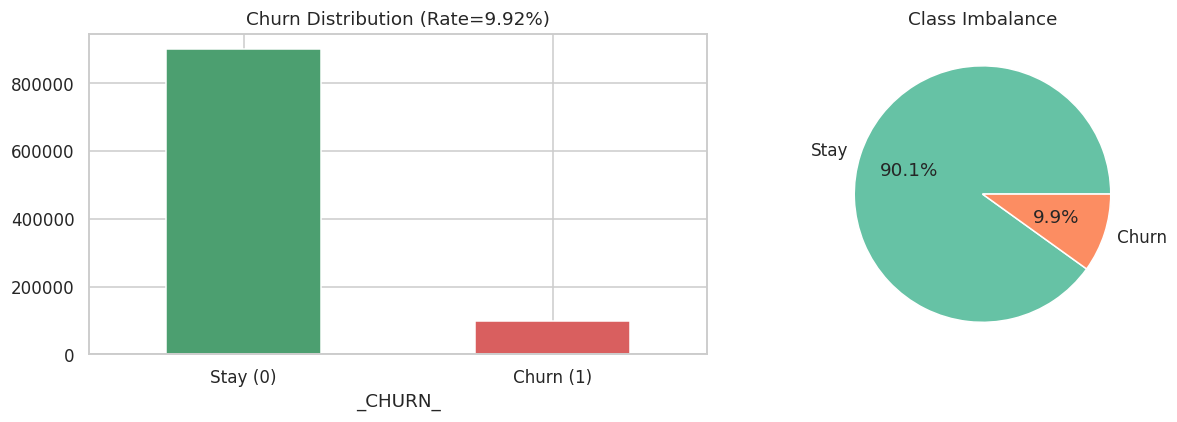

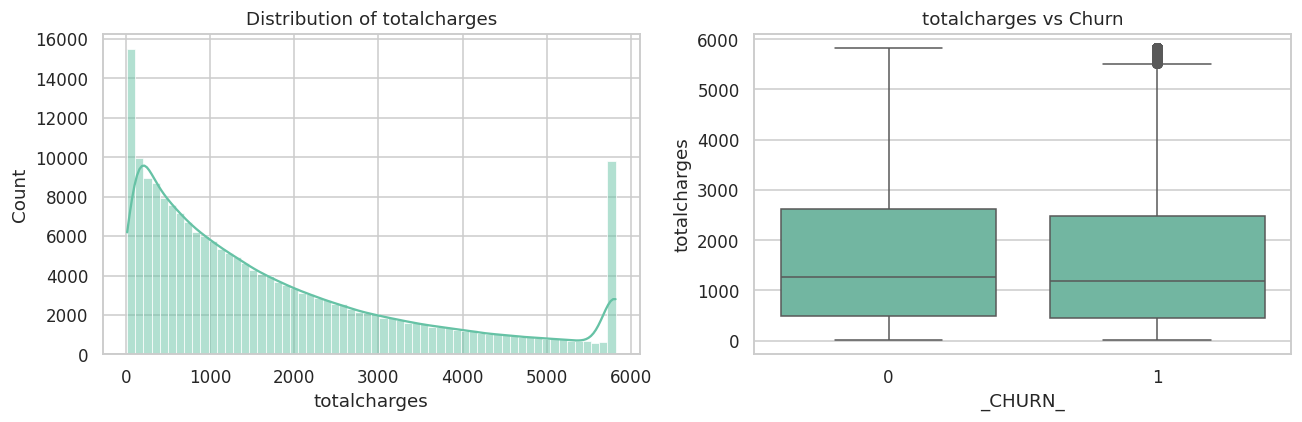

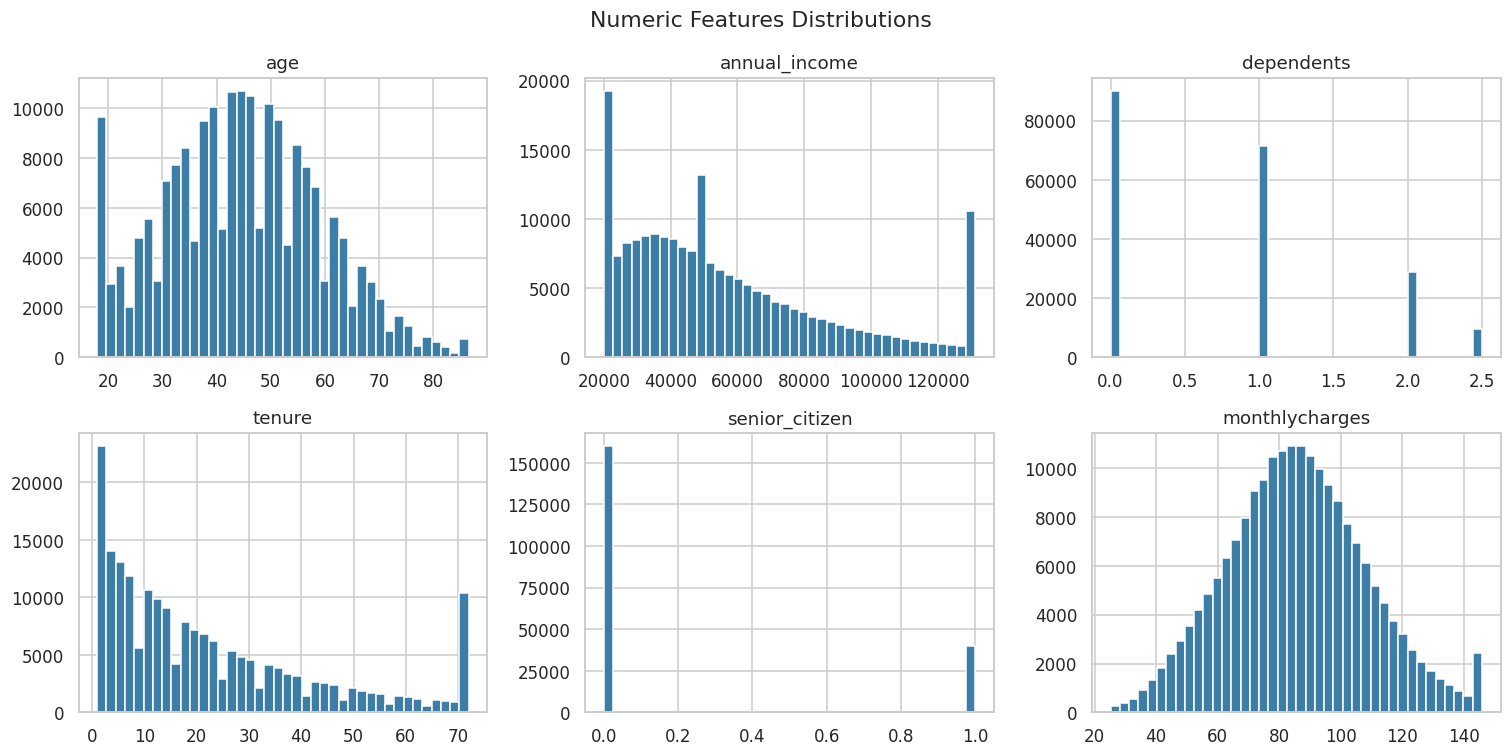

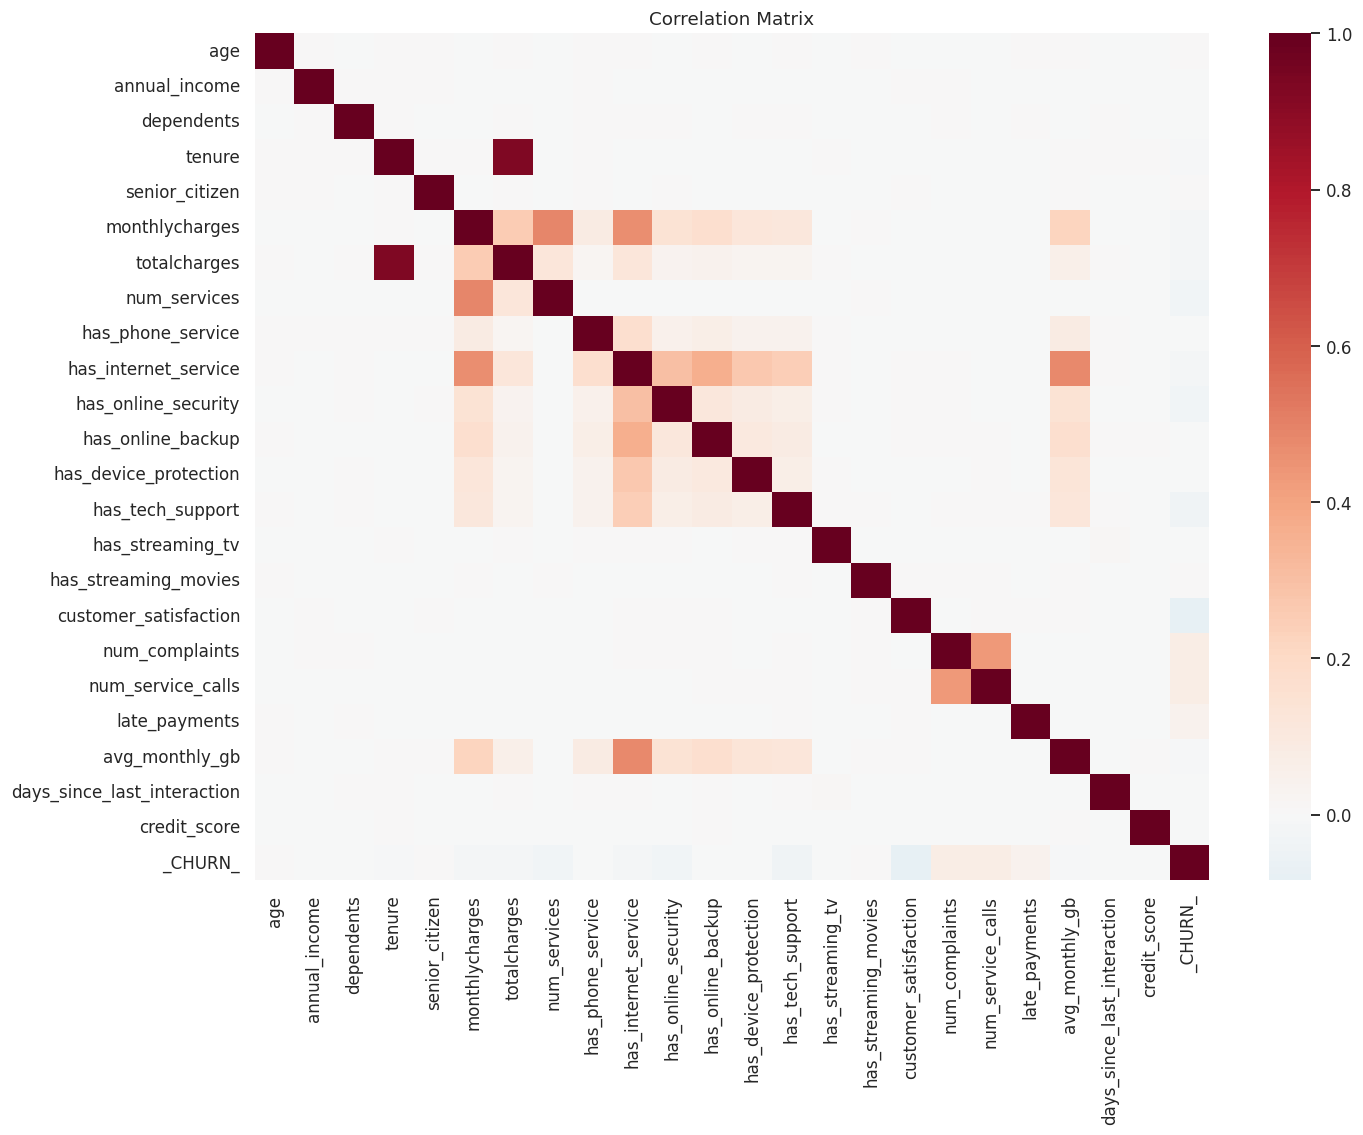

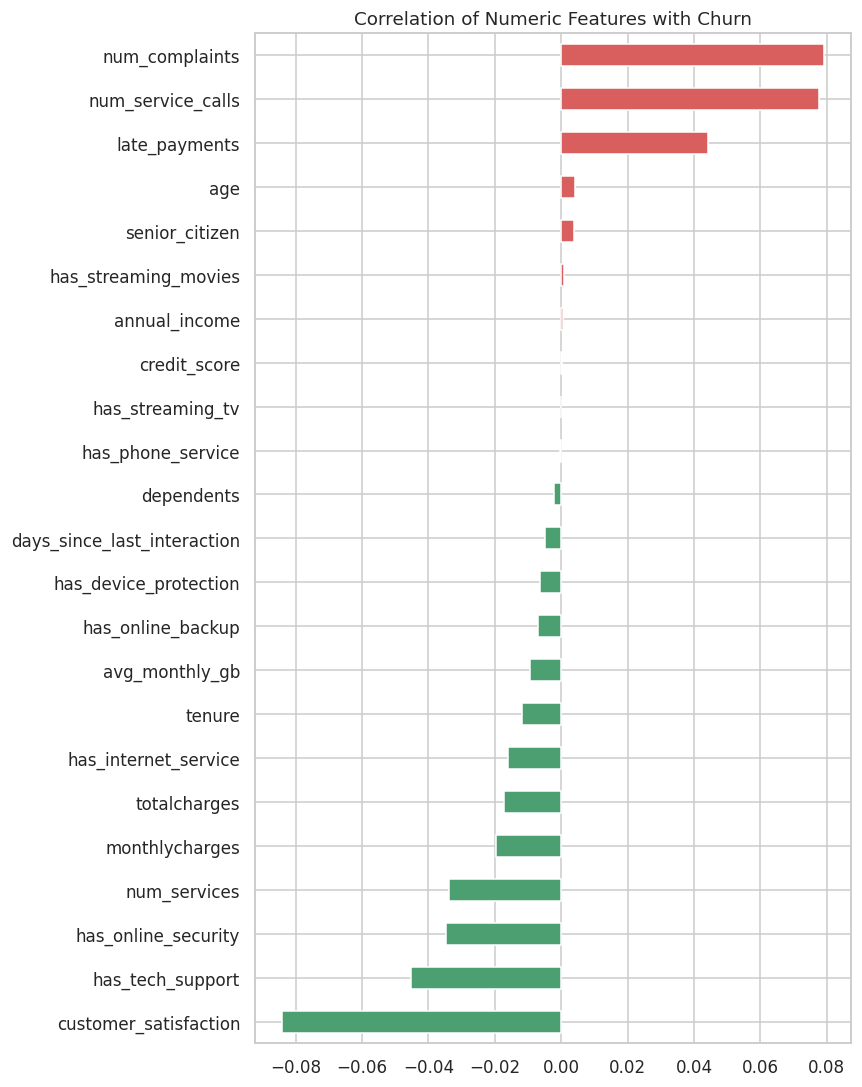

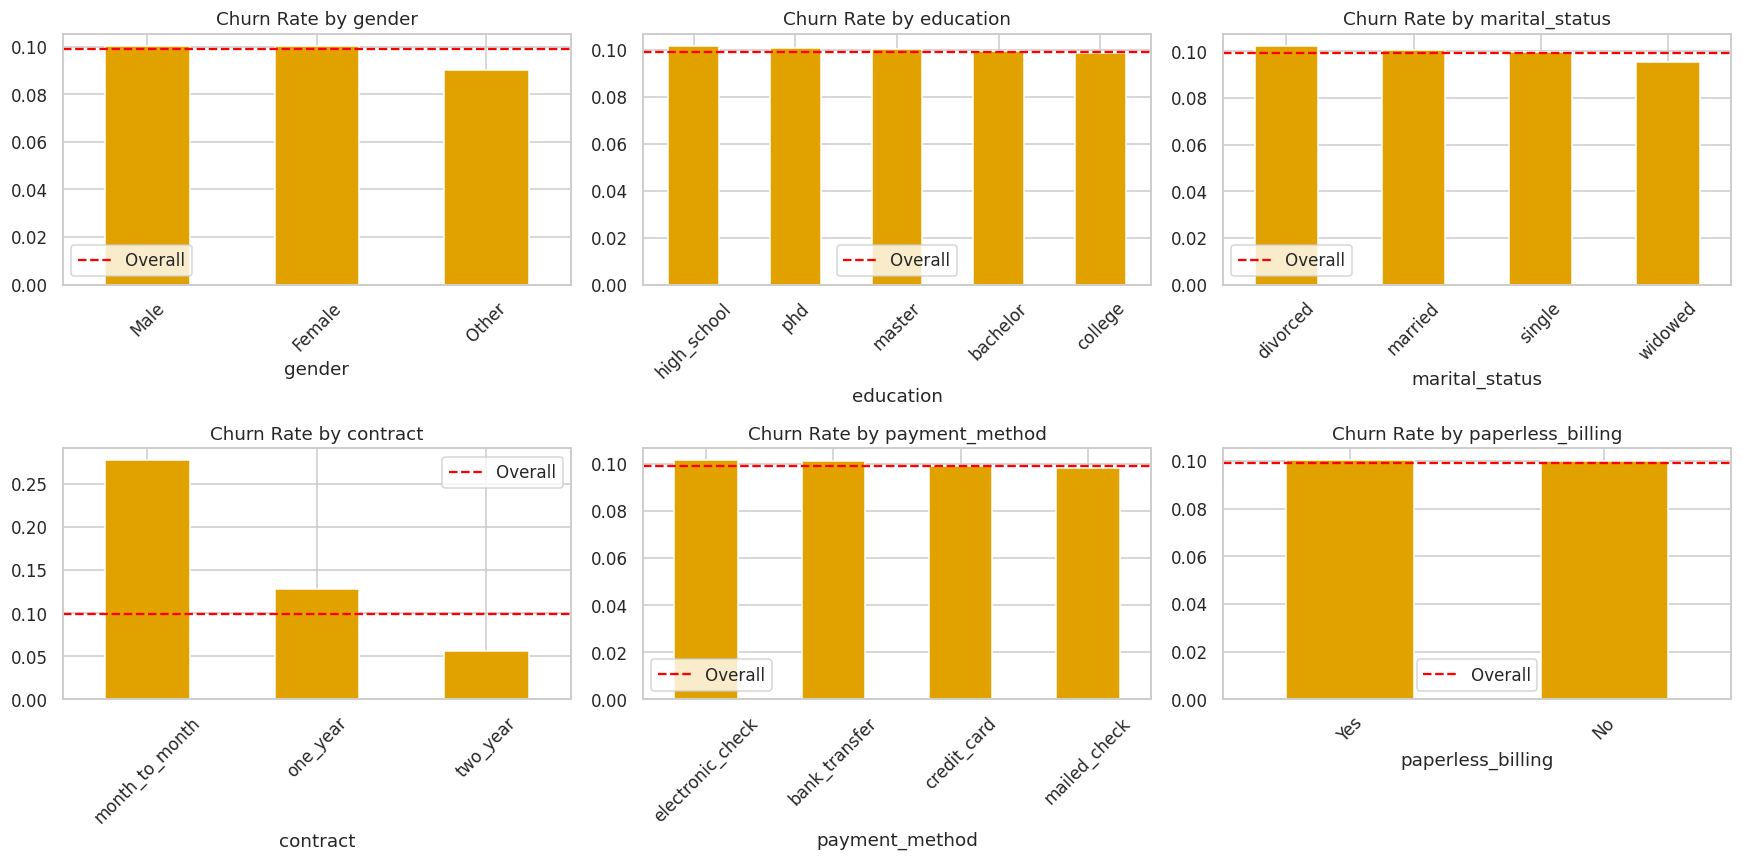

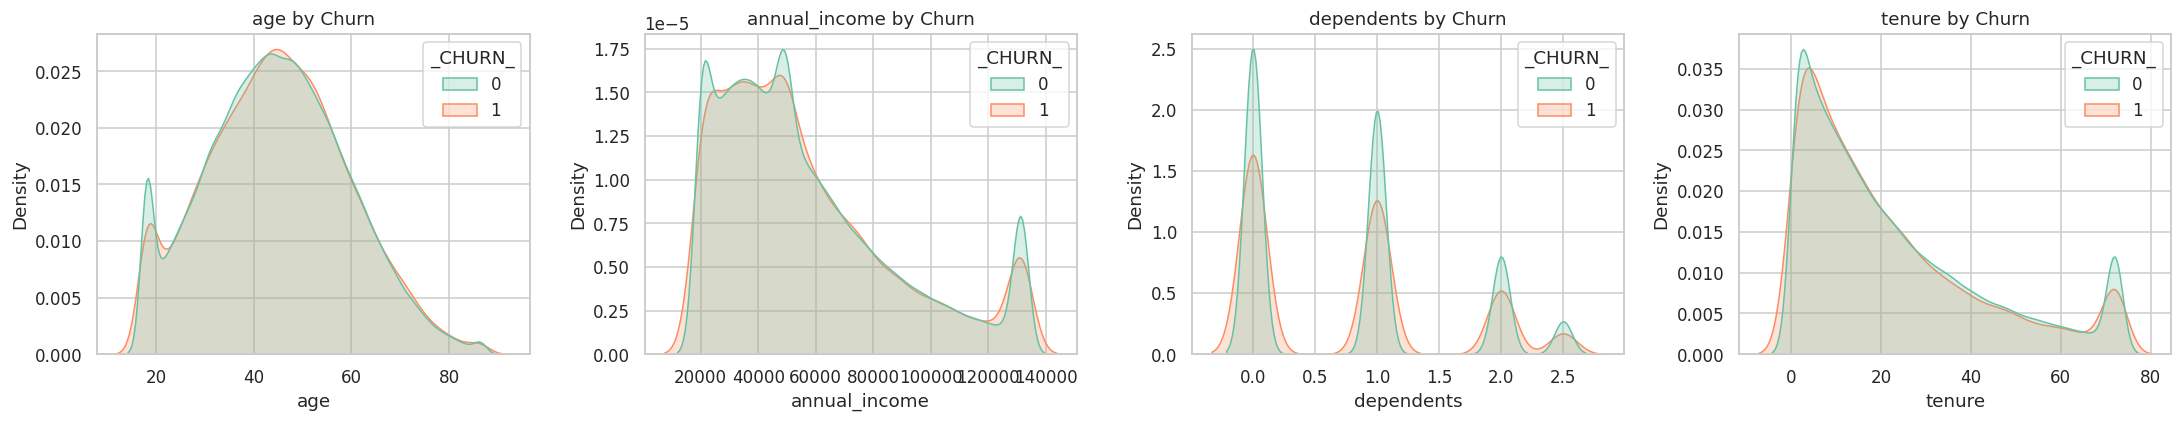

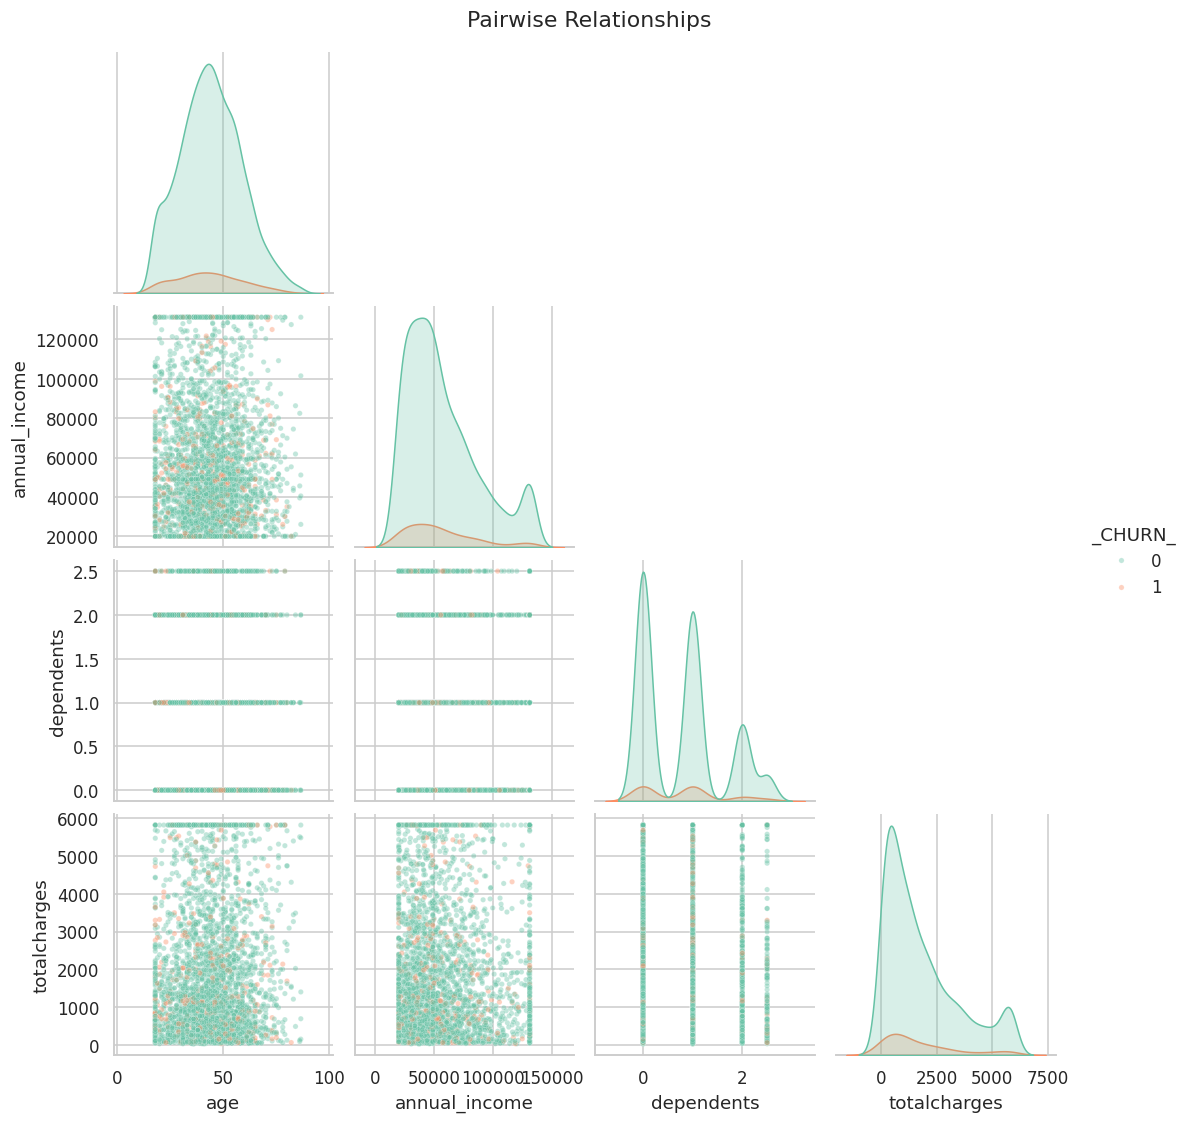


📌 رؤى EDA (اكتبيها في التقرير):
 1. نسبة الـ Churn = 9.92% => البيانات غير متوازنة، لا نعتمد على Accuracy وحدها.
 2. أقوى الميزات ارتباطاً بالـ Churn موضحة في الرسم رقم 5.
 3. توزيع totalcharges يوضح مدى انتشار قيمة العميل وأثر الشواذ.



In [6]:
# ============================================================
# CELL 6 : EDA — 10+ Visualizations
# ============================================================
eda = work.sample(min(200_000, len(work)), random_state=RANDOM_STATE)   # عينة للرسم السريع

# 1) Churn distribution
fig, ax = plt.subplots(1,2, figsize=(12,4))
work["_CHURN_"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C9F70","#D95F5F"])
ax[0].set_title(f"Churn Distribution (Rate={churn_rate:.2%})"); ax[0].set_xticklabels(["Stay (0)","Churn (1)"], rotation=0)
work["_CHURN_"].value_counts(normalize=True).plot(kind="pie", autopct="%1.1f%%", ax=ax[1], labels=["Stay","Churn"])
ax[1].set_ylabel(""); ax[1].set_title("Class Imbalance")
plt.tight_layout(); plt.show()

# 2) توزيع هدف الانحدار
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(eda[REG_TARGET], bins=60, kde=True, ax=ax[0]); ax[0].set_title(f"Distribution of {REG_TARGET}")
sns.boxplot(x=eda["_CHURN_"], y=eda[REG_TARGET], ax=ax[1]); ax[1].set_title(f"{REG_TARGET} vs Churn")
plt.tight_layout(); plt.show()

# 3) هيستوجرام لأهم الأعمدة الرقمية
plot_num = [c for c in num_cols if c != REG_TARGET][:6]
if plot_num:
    eda[plot_num].hist(bins=40, figsize=(14,7), layout=(2,3), color="#3D7EA6")
    plt.suptitle("Numeric Features Distributions"); plt.tight_layout(); plt.show()

# 4) Correlation Heatmap
corr_cols = num_cols + ["_CHURN_"]
corr = eda[corr_cols].corr(numeric_only=True)
plt.figure(figsize=(min(14, 1+len(corr_cols)), min(10, 1+len(corr_cols))))
sns.heatmap(corr, annot=len(corr_cols)<=15, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation Matrix"); plt.show()

# 5) أعلى ارتباط مع Churn
churn_corr = corr["_CHURN_"].drop("_CHURN_").sort_values()
plt.figure(figsize=(8, 0.35*len(churn_corr)+2))
churn_corr.plot(kind="barh", color=np.where(churn_corr>0, "#D95F5F", "#4C9F70"))
plt.title("Correlation of Numeric Features with Churn"); plt.tight_layout(); plt.show()

# 6) Churn rate حسب كل عمود فئوي
show_cats = [c for c in cat_cols if eda[c].nunique() <= 12][:6]
if show_cats:
    n = len(show_cats); r = math.ceil(n/3)
    fig, axes = plt.subplots(r, 3, figsize=(16, 4*r)); axes = np.array(axes).ravel()
    for i, c in enumerate(show_cats):
        g = eda.groupby(c, observed=True)["_CHURN_"].mean().sort_values(ascending=False)
        g.plot(kind="bar", ax=axes[i], color="#E1A200")
        axes[i].axhline(churn_rate, ls="--", c="red", label="Overall")
        axes[i].set_title(f"Churn Rate by {c}"); axes[i].legend(); axes[i].tick_params(axis='x', rotation=45)
    for j in range(i+1, len(axes)): axes[j].axis("off")
    plt.tight_layout(); plt.show()

# 7) KDE للأعمدة الرقمية مقسمة على Churn
if plot_num:
    n = len(plot_num[:4]); fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    axes = np.atleast_1d(axes)
    for i, c in enumerate(plot_num[:4]):
        sns.kdeplot(data=eda, x=c, hue="_CHURN_", fill=True, common_norm=False, ax=axes[i])
        axes[i].set_title(f"{c} by Churn")
    plt.tight_layout(); plt.show()

# 8) Pairplot مصغّر
pp_cols = (plot_num[:3] + [REG_TARGET]) if plot_num else [REG_TARGET]
sns.pairplot(eda.sample(min(3000,len(eda)), random_state=1)[pp_cols + ["_CHURN_"]],
             hue="_CHURN_", corner=True, plot_kws={"alpha":0.4,"s":12})
plt.suptitle("Pairwise Relationships", y=1.02); plt.show()

print("""
📌 رؤى EDA (اكتبيها في التقرير):
 1. نسبة الـ Churn = {:.2%} => البيانات غير متوازنة، لا نعتمد على Accuracy وحدها.
 2. أقوى الميزات ارتباطاً بالـ Churn موضحة في الرسم رقم 5.
 3. توزيع {} يوضح مدى انتشار قيمة العميل وأثر الشواذ.
""".format(churn_rate, REG_TARGET))

In [7]:
# ============================================================
# CELL 7 : Preprocessing Pipelines (Linear vs Tree)
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, OrdinalEncoder,
                                   PolynomialFeatures, RobustScaler)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

def make_ohe():
    """OneHotEncoder متوافق مع كل نسخ sklearn + يدمج الفئات النادرة."""
    try:
        return OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=0.01, sparse_output=True)
    except TypeError:
        try:    return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
        except TypeError: return OneHotEncoder(handle_unknown="ignore", sparse=True)

def build_preprocessors(numeric, categorical):
    """يرجع (prep_linear, prep_tree)"""
    lin = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())]), numeric),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", make_ohe())]), categorical),
    ], remainder="drop", sparse_threshold=0.3, n_jobs=None)

    tree = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), numeric),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ord", OrdinalEncoder(handle_unknown="use_encoded_value",
                                                 unknown_value=-1, encoded_missing_value=-1))]), categorical),
    ], remainder="drop")
    return lin, tree

def subsample(X, y, n, stratify=None, seed=RANDOM_STATE):
    """أخذ عينة عشوائية للنماذج البطيئة."""
    if n is None or n >= len(X): return X, y
    idx = (train_test_split(np.arange(len(X)), train_size=n, random_state=seed,
                            stratify=stratify)[0])
    return X.iloc[idx], y.iloc[idx] if hasattr(y,"iloc") else y[idx]

print("✅ Preprocessors ready")

✅ Preprocessors ready


In [8]:
# ============================================================
# CELL 8 : Regression Data Preparation
# ============================================================
reg_df = work.copy()
if FAST_MODE and len(reg_df) > MAX_TRAIN_ROWS:
    reg_df = reg_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE)
    print(f"⚡ FAST_MODE: تم أخذ عينة {len(reg_df):,} صف")

y_reg = reg_df[REG_TARGET].astype("float32")
X_reg = reg_df.drop(columns=[REG_TARGET, CLF_TARGET, "_CHURN_"], errors="ignore")

reg_num = [c for c in X_reg.columns if pd.api.types.is_numeric_dtype(X_reg[c])]
reg_cat = [c for c in X_reg.columns if c not in reg_num]
X_reg[reg_cat] = X_reg[reg_cat].astype(str)

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE)
prep_lin_r, prep_tree_r = build_preprocessors(reg_num, reg_cat)

print(f"Train={Xr_tr.shape} | Test={Xr_te.shape}")
print(f"Target '{REG_TARGET}': mean={y_reg.mean():.2f}, std={y_reg.std():.2f}, min={y_reg.min():.2f}, max={y_reg.max():.2f}")

⚡ FAST_MODE: تم أخذ عينة 300,000 صف
Train=(240000, 28) | Test=(60000, 28)
Target 'totalcharges': mean=1780.66, std=1631.40, min=16.30, max=5817.35


In [9]:
# ============================================================
# CELL 9 : Train & Compare ALL Regression Models - FAST VERSION
# ============================================================

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    SGDRegressor, HuberRegressor
)
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, AdaBoostRegressor,
    HistGradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import math
import time
import numpy as np
import pandas as pd


def reg_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": math.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
        "MAPE%": float(
            np.mean(
                np.abs(
                    (y_true - y_pred) /
                    np.clip(np.abs(y_true), 1e-6, None)
                )
            ) * 100
        )
    }


reg_results = []
reg_fitted = {}


def run_reg(name, model, prep, n_sample=None, poly=None, note=""):

    t0 = time.time()

    # --------------------------------------------------------
    # Sampling
    # --------------------------------------------------------
    Xtr, ytr = subsample(Xr_tr, yr_tr, n_sample)

    # --------------------------------------------------------
    # Pipeline
    # --------------------------------------------------------
    steps = [("prep", prep)]

    if poly is not None:
        steps.append(
            (
                "poly",
                PolynomialFeatures(
                    degree=poly,
                    include_bias=False
                )
            )
        )

    steps.append(("model", model))

    pipe = Pipeline(steps)

    try:

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------
        pipe.fit(Xtr, ytr)

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------
        pred_te = pipe.predict(Xr_te)
        pred_tr = pipe.predict(Xtr)

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------
        m_te = reg_metrics(yr_te, pred_te)
        m_tr = reg_metrics(ytr, pred_tr)

        elapsed = time.time() - t0

        reg_results.append({
            "Model": name,
            **{k: round(v, 4) for k, v in m_te.items()},
            "Train_R2": round(m_tr["R2"], 4),
            "Overfit_Gap": round(
                m_tr["R2"] - m_te["R2"], 4
            ),
            "Train_Rows": len(Xtr),
            "Time_s": round(elapsed, 1),
            "Note": note
        })

        reg_fitted[name] = pipe

        print(
            f"✔ {name:<28} "
            f"R2={m_te['R2']:.4f} "
            f"RMSE={m_te['RMSE']:.2f} "
            f"({elapsed:.1f}s)"
        )

    except Exception as e:

        print(
            f"✘ {name}: "
            f"{type(e).__name__} -> {e}"
        )


# ============================================================
# ① LINEAR / REGULARIZED
# ============================================================

print(
    "=" * 70,
    "\nخطية / منتظمة (Linear family)\n",
    "=" * 70
)

run_reg(
    "Linear Regression",
    LinearRegression(),
    prep_lin_r,
    note="Baseline"
)

run_reg(
    "Ridge (L2)",
    Ridge(alpha=1.0),
    prep_lin_r
)

run_reg(
    "Lasso (L1)",
    Lasso(
        alpha=0.001,
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    prep_lin_r,
    note="Feature selection"
)

run_reg(
    "ElasticNet (L1+L2)",
    ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    prep_lin_r
)

run_reg(
    "SGD Regressor",
    SGDRegressor(
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ),
    prep_lin_r,
    note="Scalable"
)

run_reg(
    "Huber (robust)",
    HuberRegressor(
        max_iter=200
    ),
    prep_lin_r,
    n_sample=50_000,
    note="Outlier-robust"
)


# ============================================================
# ② POLYNOMIAL
# ============================================================

print(
    "\n" + "=" * 70,
    "\nمتعدد الحدود (Polynomial)\n",
    "=" * 70
)

run_reg(
    "Polynomial deg=2 + Ridge",
    Ridge(alpha=1.0),
    prep_lin_r,
    n_sample=50_000,
    poly=2,
    note="Non-linear"
)

# degree 3 فقط بعينة صغيرة لأنه مكلف جدًا
run_reg(
    "Polynomial deg=3 + Ridge",
    Ridge(alpha=10.0),
    prep_lin_r,
    n_sample=15_000,
    poly=3,
    note="Small sample"
)


# ============================================================
# ③ TREES & ENSEMBLES
# ============================================================

print(
    "\n" + "=" * 70,
    "\nأشجار وتجميعية (Trees & Ensembles)\n",
    "=" * 70
)


# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

run_reg(
    "Decision Tree",
    DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=50,
        random_state=RANDOM_STATE
    ),
    prep_tree_r
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

run_reg(
    "Random Forest",
    RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=30,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    prep_tree_r,
    n_sample=150_000,
    note="Fast RF"
)


# ------------------------------------------------------------
# Extra Trees
# ------------------------------------------------------------

run_reg(
    "Extra Trees",
    ExtraTreesRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=30,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    prep_tree_r,
    n_sample=150_000,
    note="Fast Extra Trees"
)


# ------------------------------------------------------------
# AdaBoost
# ------------------------------------------------------------

run_reg(
    "AdaBoost",
    AdaBoostRegressor(
        n_estimators=80,
        learning_rate=0.08,
        random_state=RANDOM_STATE
    ),
    prep_tree_r,
    n_sample=80_000
)


# ------------------------------------------------------------
# Gradient Boosting
# ------------------------------------------------------------

run_reg(
    "Gradient Boosting",
    GradientBoostingRegressor(
        n_estimators=80,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),
    prep_tree_r,
    n_sample=80_000,
    note="Fast sample"
)


# ------------------------------------------------------------
# HistGradientBoosting
# ------------------------------------------------------------

run_reg(
    "HistGradientBoosting",
    HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        early_stopping=True,
        random_state=RANDOM_STATE
    ),
    prep_tree_r,
    note="Fast"
)


# ============================================================
# ④ XGBOOST
# ============================================================

if HAS_XGB:

    run_reg(
        "XGBoost",
        xgb.XGBRegressor(
            n_estimators=250,
            learning_rate=0.08,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0
        ),
        prep_tree_r,
        n_sample=150_000,
        note="Fast XGB"
    )


# ============================================================
# ⑤ LIGHTGBM
# ============================================================

if HAS_LGB:

    run_reg(
        "LightGBM",
        lgb.LGBMRegressor(
            n_estimators=300,
            learning_rate=0.06,
            num_leaves=31,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1
        ),
        prep_tree_r,
        n_sample=150_000,
        note="Fast LightGBM"
    )


# ============================================================
# ⑥ CATBOOST
# ============================================================

if HAS_CAT:

    run_reg(
        "CatBoost",
        CatBoostRegressor(
            iterations=300,
            learning_rate=0.08,
            depth=7,
            random_seed=RANDOM_STATE,
            verbose=0,
            thread_count=-1
        ),
        prep_tree_r,
        n_sample=150_000,
        note="Fast CatBoost"
    )


# ============================================================
# FINAL COMPARISON
# ============================================================

reg_table = (
    pd.DataFrame(reg_results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)


print("\n\n📊 REGRESSION MODEL COMPARISON")

display(
    reg_table.style
    .background_gradient(
        subset=["R2"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["RMSE", "MAE"],
        cmap="Reds_r"
    )
)

خطية / منتظمة (Linear family)
✔ Linear Regression            R2=0.9252 RMSE=445.49 (4.6s)
✔ Ridge (L2)                   R2=0.9252 RMSE=445.49 (4.3s)
✔ Lasso (L1)                   R2=0.9252 RMSE=445.49 (6.2s)
✔ ElasticNet (L1+L2)           R2=0.9252 RMSE=445.49 (16.0s)
✔ SGD Regressor                R2=0.9249 RMSE=446.33 (5.2s)
✔ Huber (robust)               R2=0.9208 RMSE=458.41 (2.4s)

متعدد الحدود (Polynomial)
✔ Polynomial deg=2 + Ridge     R2=0.9572 RMSE=336.95 (3.2s)
✔ Polynomial deg=3 + Ridge     R2=0.9276 RMSE=438.29 (52.7s)

أشجار وتجميعية (Trees & Ensembles)
✔ Decision Tree                R2=0.9695 RMSE=284.49 (4.8s)
✔ Random Forest                R2=0.9702 RMSE=281.03 (36.7s)
✔ Extra Trees                  R2=0.9703 RMSE=280.51 (20.0s)
✔ AdaBoost                     R2=0.9382 RMSE=404.87 (18.8s)
✔ Gradient Boosting            R2=0.9697 RMSE=283.68 (14.9s)
✔ HistGradientBoosting         R2=0.9707 RMSE=278.84 (6.9s)
✔ XGBoost                      R2=0.9704 RMSE=280.23 (4.8s)
✔

,Model,MAE,MSE,RMSE,R2,MAPE%,Train_R2,Overfit_Gap,Train_Rows,Time_s,Note
0,HistGradientBoosting,155.916100,77753.983800,278.844000,0.970700,10.679200,0.971900,0.001200,240000,6.900000,Fast
1,CatBoost,155.845500,77665.919800,278.686100,0.970700,10.790300,0.972300,0.001600,150000,6.600000,Fast CatBoost
2,LightGBM,157.541300,78107.899600,279.477900,0.970600,11.943800,0.973400,0.002800,150000,4.900000,Fast LightGBM
3,XGBoost,157.930200,78526.460900,280.225700,0.970400,11.616900,0.974700,0.004300,150000,4.800000,Fast XGB
4,Extra Trees,157.004700,78685.510300,280.509400,0.970300,10.593100,0.973400,0.003100,150000,20.000000,Fast Extra Trees
5,Random Forest,157.209300,78978.209100,281.030600,0.970200,10.601900,0.974500,0.004300,150000,36.700000,Fast RF
6,Gradient Boosting,163.898200,80474.703800,283.680600,0.969700,13.476000,0.969600,-0.000100,80000,14.900000,Fast sample
7,Decision Tree,159.815200,80935.377400,284.491400,0.969500,10.765800,0.971300,0.001800,240000,4.800000,
8,Polynomial deg=2 + Ridge,209.016900,113533.665700,336.947600,0.957200,28.779000,0.958200,0.001000,50000,3.200000,Non-linear
9,AdaBoost,284.791800,163922.268900,404.873200,0.938200,41.064700,0.937600,-0.000600,80000,18.800000,


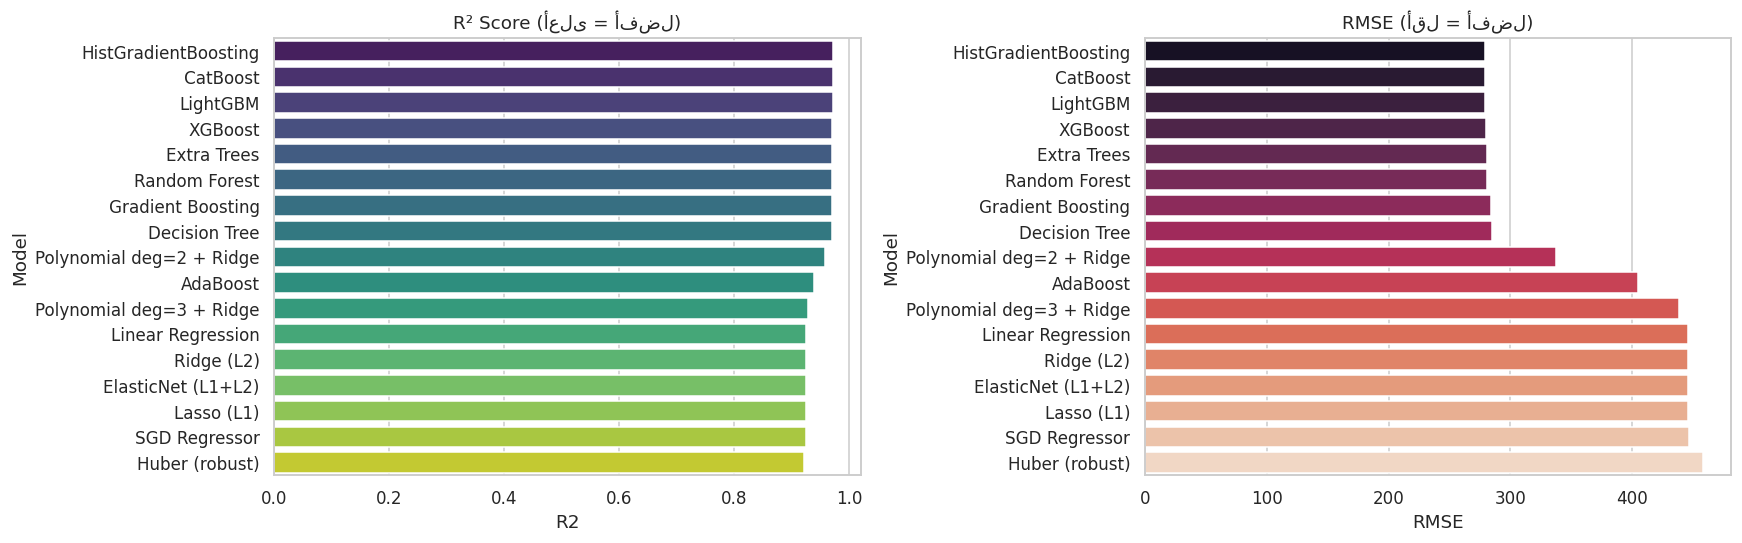

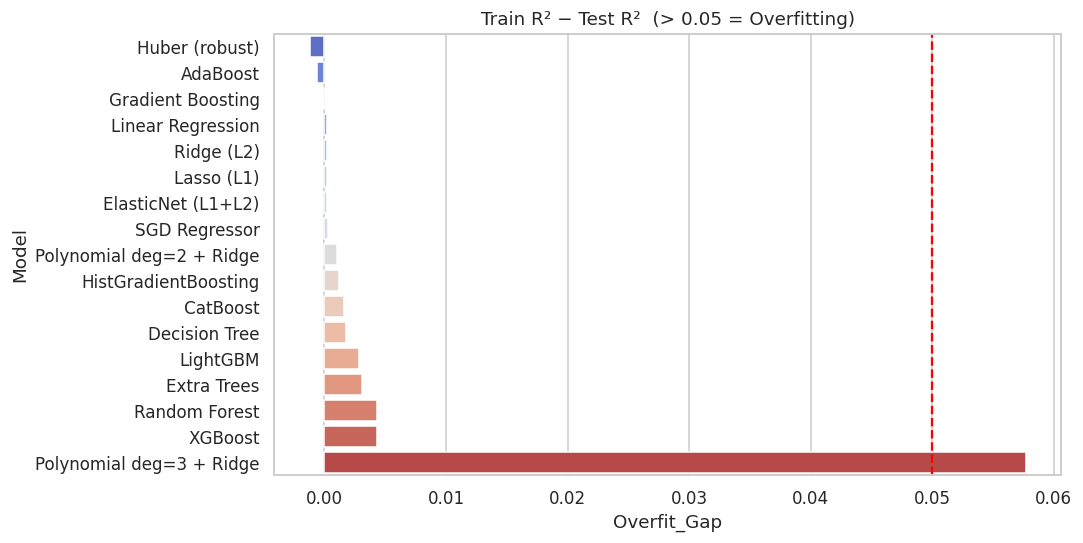

🔍 Lasso صفّر 4 من أصل 43 ميزة (9.3%)


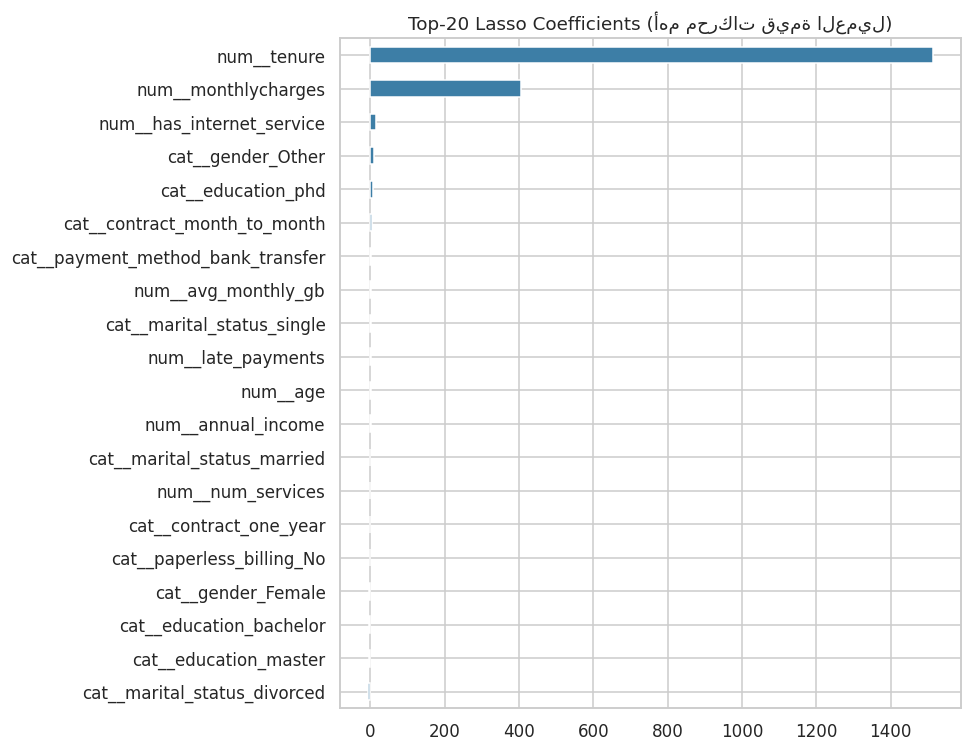

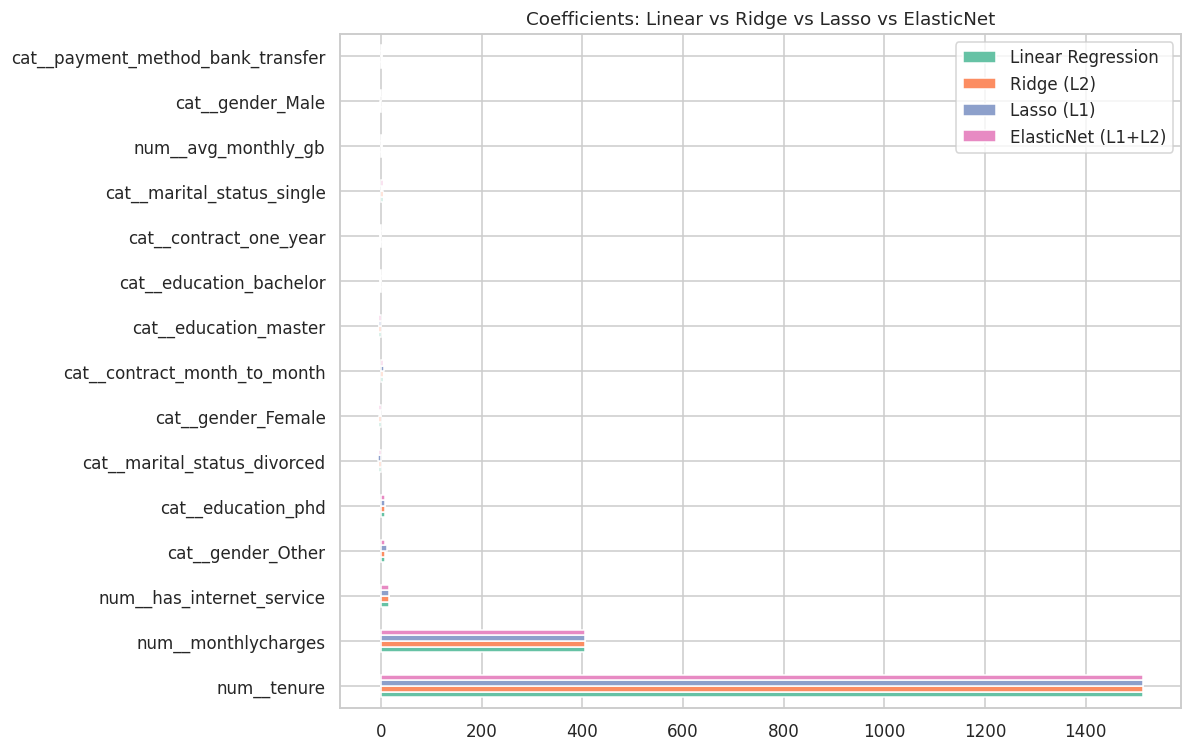

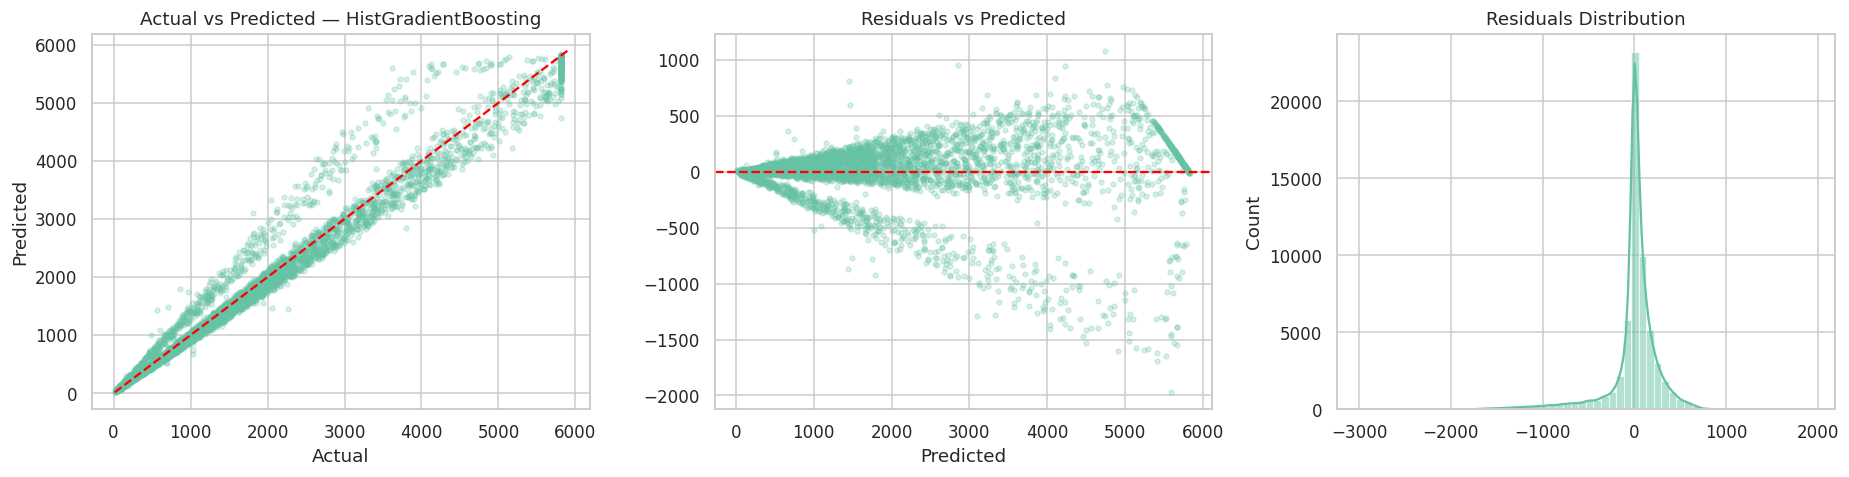


🏆 أفضل نموذج انحدار: HistGradientBoosting
   R² = 0.9707 | RMSE = 278.844 | MAE = 155.9161



In [10]:
# ============================================================
# CELL 10 : Regression Analysis (plots + Lasso feature selection)
# ============================================================
fig, ax = plt.subplots(1,2, figsize=(16,max(5,0.3*len(reg_table))))
sns.barplot(data=reg_table, y="Model", x="R2", ax=ax[0], palette="viridis"); ax[0].set_title("R² Score (أعلى = أفضل)")
sns.barplot(data=reg_table, y="Model", x="RMSE", ax=ax[1], palette="rocket"); ax[1].set_title("RMSE (أقل = أفضل)")
plt.tight_layout(); plt.show()

# Overfitting gap
plt.figure(figsize=(10, max(4,0.3*len(reg_table))))
sns.barplot(data=reg_table.sort_values("Overfit_Gap"), y="Model", x="Overfit_Gap", palette="coolwarm")
plt.axvline(0.05, ls="--", c="red"); plt.title("Train R² − Test R²  (> 0.05 = Overfitting)")
plt.tight_layout(); plt.show()

# --- Lasso: كم عمود تم تصفيره؟ (مطلوب في الجدول بتاعك) ---
if "Lasso (L1)" in reg_fitted:
    lp = reg_fitted["Lasso (L1)"]
    try:
        names = lp.named_steps["prep"].get_feature_names_out()
    except Exception:
        names = np.array([f"f{i}" for i in range(len(lp.named_steps['model'].coef_))])
    coefs = lp.named_steps["model"].coef_
    zeroed = int((coefs == 0).sum())
    print(f"🔍 Lasso صفّر {zeroed} من أصل {len(coefs)} ميزة ({zeroed/len(coefs):.1%})")
    imp = pd.Series(coefs, index=names).sort_values(key=np.abs, ascending=False).head(20)
    plt.figure(figsize=(9,7)); imp.sort_values().plot(kind="barh", color="#3D7EA6")
    plt.title("Top-20 Lasso Coefficients (أهم محركات قيمة العميل)"); plt.tight_layout(); plt.show()

# --- Ridge vs Lasso vs Linear مقارنة المعاملات ---
comp = {}
for n in ["Linear Regression","Ridge (L2)","Lasso (L1)","ElasticNet (L1+L2)"]:
    if n in reg_fitted:
        try: comp[n] = pd.Series(reg_fitted[n].named_steps["model"].coef_,
                                 index=reg_fitted[n].named_steps["prep"].get_feature_names_out())
        except Exception: pass
if len(comp) >= 2:
    cdf = pd.DataFrame(comp)
    top = cdf.abs().mean(axis=1).sort_values(ascending=False).head(15).index
    cdf.loc[top].plot(kind="barh", figsize=(11,7))
    plt.title("Coefficients: Linear vs Ridge vs Lasso vs ElasticNet"); plt.tight_layout(); plt.show()

# --- Actual vs Predicted + Residuals لأفضل نموذج ---
best_reg_name = reg_table.iloc[0]["Model"]
best_reg = reg_fitted[best_reg_name]
pred = best_reg.predict(Xr_te)
s = np.random.choice(len(yr_te), min(5000, len(yr_te)), replace=False)
fig, ax = plt.subplots(1,3, figsize=(17,4.5))
ax[0].scatter(yr_te.values[s], pred[s], alpha=.25, s=10)
lims=[min(yr_te.min(),pred.min()), max(yr_te.max(),pred.max())]
ax[0].plot(lims, lims, "r--"); ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted")
ax[0].set_title(f"Actual vs Predicted — {best_reg_name}")
res = yr_te.values - pred
ax[1].scatter(pred[s], res[s], alpha=.25, s=10); ax[1].axhline(0, c="r", ls="--")
ax[1].set_title("Residuals vs Predicted"); ax[1].set_xlabel("Predicted")
sns.histplot(res, bins=60, kde=True, ax=ax[2]); ax[2].set_title("Residuals Distribution")
plt.tight_layout(); plt.show()

print(f"""
🏆 أفضل نموذج انحدار: {best_reg_name}
   R² = {reg_table.iloc[0]['R2']} | RMSE = {reg_table.iloc[0]['RMSE']} | MAE = {reg_table.iloc[0]['MAE']}
""")
reg_table.to_csv("regression_comparison.csv", index=False)

In [11]:
# ============================================================
# CELL 11 : Classification Data Prep + Imbalance Handling
# ============================================================
clf_df = work.copy()
if FAST_MODE and len(clf_df) > MAX_TRAIN_ROWS:
    clf_df, _ = train_test_split(clf_df, train_size=MAX_TRAIN_ROWS,
                                 stratify=clf_df["_CHURN_"], random_state=RANDOM_STATE)
    print(f"⚡ FAST_MODE: عينة طبقية {len(clf_df):,} صف")

y_clf = clf_df["_CHURN_"].astype("int8")
X_clf = clf_df.drop(columns=["_CHURN_", CLF_TARGET], errors="ignore")

clf_num = [c for c in X_clf.columns if pd.api.types.is_numeric_dtype(X_clf[c])]
clf_cat = [c for c in X_clf.columns if c not in clf_num]
X_clf[clf_cat] = X_clf[clf_cat].astype(str)

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_clf, y_clf, test_size=TEST_SIZE,
                                              stratify=y_clf, random_state=RANDOM_STATE)
prep_lin_c, prep_tree_c = build_preprocessors(clf_num, clf_cat)

pos, neg = int(yc_tr.sum()), int((yc_tr==0).sum())
SPW = neg/max(pos,1)                      # scale_pos_weight للـ Boosting
print(f"Train={Xc_tr.shape} | Test={Xc_te.shape}")
print(f"Train churn={yc_tr.mean():.2%} | Test churn={yc_te.mean():.2%} | scale_pos_weight={SPW:.2f}")
print("\n📌 استراتيجية الـ Imbalance: class_weight='balanced' للنماذج الخطية/الأشجار + scale_pos_weight للـ Boosting")

⚡ FAST_MODE: عينة طبقية 300,000 صف
Train=(240000, 29) | Test=(60000, 29)
Train churn=9.92% | Test churn=9.92% | scale_pos_weight=9.08

📌 استراتيجية الـ Imbalance: class_weight='balanced' للنماذج الخطية/الأشجار + scale_pos_weight للـ Boosting


In [12]:
# ============================================================
# CELL 12 : Train & Compare Classification Models
# FAST BENCHMARK VERSION
# ============================================================

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    BaggingClassifier
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.kernel_approximation import Nystroem

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    matthews_corrcoef
)

clf_results = []
clf_fitted = {}
clf_scores = {}


# ============================================================
# SCORE FUNCTION
# ============================================================

def get_scores(pipe, X):

    if hasattr(pipe, "predict_proba"):
        try:
            p = pipe.predict_proba(X)[:, 1]
            return p, p
        except Exception:
            pass

    if hasattr(pipe, "decision_function"):
        d = pipe.decision_function(X)
        return None, d

    return None, None


# ============================================================
# RUN CLASSIFIER
# ============================================================

def run_clf(name, model, prep, n_sample=None, note=""):

    t0 = time.time()

    Xtr, ytr = subsample(
        Xc_tr,
        yc_tr,
        n_sample,
        stratify=yc_tr
    )

    pipe = Pipeline([
        ("prep", prep),
        ("model", model)
    ])

    try:

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        pipe.fit(Xtr, ytr)

        # ----------------------------------------------------
        # Prediction
        # ----------------------------------------------------

        pred = pipe.predict(Xc_te)

        proba, score = get_scores(
            pipe,
            Xc_te
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        row = {
            "Model": name,

            "Accuracy":
                round(
                    accuracy_score(yc_te, pred),
                    4
                ),

            "BalancedAcc":
                round(
                    balanced_accuracy_score(yc_te, pred),
                    4
                ),

            "Precision":
                round(
                    precision_score(
                        yc_te,
                        pred,
                        zero_division=0
                    ),
                    4
                ),

            "Recall":
                round(
                    recall_score(
                        yc_te,
                        pred,
                        zero_division=0
                    ),
                    4
                ),

            "F1":
                round(
                    f1_score(
                        yc_te,
                        pred,
                        zero_division=0
                    ),
                    4
                ),

            "ROC_AUC":
                round(
                    roc_auc_score(
                        yc_te,
                        score
                    ),
                    4
                ) if score is not None else np.nan,

            "PR_AUC":
                round(
                    average_precision_score(
                        yc_te,
                        score
                    ),
                    4
                ) if score is not None else np.nan,

            "LogLoss":
                round(
                    log_loss(
                        yc_te,
                        np.clip(
                            proba,
                            1e-6,
                            1 - 1e-6
                        )
                    ),
                    4
                ) if proba is not None else np.nan,

            "MCC":
                round(
                    matthews_corrcoef(
                        yc_te,
                        pred
                    ),
                    4
                ),

            "Train_Rows":
                len(Xtr),

            "Time_s":
                round(
                    time.time() - t0,
                    1
                ),

            "Note":
                note
        }

        clf_results.append(row)

        clf_fitted[name] = pipe

        clf_scores[name] = (
            proba,
            score,
            pred
        )

        print(
            f"✔ {name:<30} "
            f"F1={row['F1']:.4f} "
            f"Recall={row['Recall']:.4f} "
            f"AUC={row['ROC_AUC']} "
            f"({row['Time_s']}s)"
        )

    except Exception as e:

        print(
            f"✘ {name}: "
            f"{type(e).__name__} -> {e}"
        )


# ============================================================
# ① LINEAR / DISTANCE MODELS
# ============================================================

print(
    "=" * 75,
    "\n① النماذج الخطية والمسافية\n",
    "=" * 75
)


run_clf(
    "Logistic Regression",
    LogisticRegression(
        max_iter=700,
        class_weight="balanced",
        solver="lbfgs"
    ),
    prep_lin_c,
    note="Baseline"
)


run_clf(
    "Logistic (no weight)",
    LogisticRegression(
        max_iter=700
    ),
    prep_lin_c
)


run_clf(
    "SGD Classifier (log)",
    SGDClassifier(
        loss="log_loss",
        class_weight="balanced",
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE
    ),
    prep_lin_c,
    note="Scalable"
)


run_clf(
    "LDA",
    LinearDiscriminantAnalysis(),
    prep_lin_c
)


run_clf(
    "Gaussian Naive Bayes",
    GaussianNB(),
    prep_tree_c
)


run_clf(
    "Bernoulli Naive Bayes",
    BernoulliNB(),
    prep_lin_c
)


# KNN → smaller sample
run_clf(
    "KNN (k=15)",
    KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        n_jobs=-1
    ),
    prep_lin_c,
    n_sample=20_000,
    note="Small sample"
)


# Linear SVM
run_clf(
    "Linear SVM",
    LinearSVC(
        class_weight="balanced",
        max_iter=1500,
        dual="auto"
    ),
    prep_lin_c,
    note="Scalable SVM"
)


# RBF SVM → VERY small sample
run_clf(
    "SVM (RBF)",
    SVC(
        kernel="rbf",
        class_weight="balanced",
        cache_size=1000,
        probability=False,
        random_state=RANDOM_STATE
    ),
    prep_lin_c,
    n_sample=15_000,
    note="Small sample"
)


# ============================================================
# ② TREES & ENSEMBLES
# ============================================================

print(
    "\n" + "=" * 75,
    "\n② الأشجار والنماذج التجميعية\n",
    "=" * 75
)


# ------------------------------------------------------------
# Decision Tree
# ------------------------------------------------------------

run_clf(
    "Decision Tree",
    DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    prep_tree_c
)


# ------------------------------------------------------------
# Bagging
# ------------------------------------------------------------

run_clf(
    "Bagging (DT)",
    BaggingClassifier(
        DecisionTreeClassifier(
            max_depth=10,
            min_samples_leaf=30
        ),
        n_estimators=25,
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    prep_tree_c,
    n_sample=150_000,
    note="Fast sample"
)


# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

run_clf(
    "Random Forest",
    RandomForestClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=20,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    prep_tree_c,
    n_sample=150_000,
    note="Fast RF"
)


# ------------------------------------------------------------
# Extra Trees
# ------------------------------------------------------------

run_clf(
    "Extra Trees",
    ExtraTreesClassifier(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),
    prep_tree_c,
    n_sample=150_000,
    note="Fast Extra Trees"
)


# ------------------------------------------------------------
# AdaBoost
# ------------------------------------------------------------

run_clf(
    "AdaBoost",
    AdaBoostClassifier(
        n_estimators=80,
        learning_rate=0.08,
        random_state=RANDOM_STATE
    ),
    prep_tree_c,
    n_sample=80_000,
    note="Fast sample"
)


# ------------------------------------------------------------
# Gradient Boosting
# ------------------------------------------------------------

run_clf(
    "Gradient Boosting",
    GradientBoostingClassifier(
        n_estimators=80,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.8,
        random_state=RANDOM_STATE
    ),
    prep_tree_c,
    n_sample=80_000,
    note="Fast sample"
)


# ------------------------------------------------------------
# HistGradientBoosting
# ------------------------------------------------------------

run_clf(
    "HistGradientBoosting",
    HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.08,
        max_leaf_nodes=31,
        class_weight="balanced",
        early_stopping=True,
        random_state=RANDOM_STATE
    ),
    prep_tree_c,
    note="Fast + balanced"
)


# ============================================================
# ③ XGBOOST
# ============================================================

if HAS_XGB:

    run_clf(
        "XGBoost",
        xgb.XGBClassifier(
            n_estimators=250,
            learning_rate=0.08,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            scale_pos_weight=SPW,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0
        ),
        prep_tree_c,
        n_sample=150_000,
        note="Fast XGB"
    )


# ============================================================
# ④ LIGHTGBM
# ============================================================

if HAS_LGB:

    run_clf(
        "LightGBM",
        lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.06,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1
        ),
        prep_tree_c,
        n_sample=150_000,
        note="Fast LightGBM"
    )


# ============================================================
# ⑤ CATBOOST
# ============================================================

if HAS_CAT:

    run_clf(
        "CatBoost",
        CatBoostClassifier(
            iterations=300,
            learning_rate=0.08,
            depth=7,
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=0,
            thread_count=-1
        ),
        prep_tree_c,
        n_sample=150_000,
        note="Fast CatBoost"
    )


# ============================================================
# FINAL TABLE
# ============================================================

clf_table = (
    pd.DataFrame(clf_results)
    .sort_values(
        ["F1", "ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\n\n📊 CLASSIFICATION MODEL COMPARISON"
)


display(
    clf_table.style
    .background_gradient(
        subset=[
            "F1",
            "Recall",
            "ROC_AUC",
            "PR_AUC"
        ],
        cmap="Greens"
    )
    .background_gradient(
        subset=["LogLoss"],
        cmap="Reds"
    )
)


clf_table.to_csv(
    "classification_comparison.csv",
    index=False
)

① النماذج الخطية والمسافية
✔ Logistic Regression            F1=0.2551 Recall=0.6414 AUC=0.6858 (4.9s)
✔ Logistic (no weight)           F1=0.0050 Recall=0.0025 AUC=0.6859 (4.7s)
✔ SGD Classifier (log)           F1=0.2464 Recall=0.6753 AUC=0.6757 (5.7s)
✔ LDA                            F1=0.0260 Recall=0.0134 AUC=0.6847 (4.4s)
✔ Gaussian Naive Bayes           F1=0.0000 Recall=0.0000 AUC=0.6453 (2.5s)
✔ Bernoulli Naive Bayes          F1=0.0007 Recall=0.0003 AUC=0.6685 (3.9s)
✔ KNN (k=15)                     F1=0.0003 Recall=0.0002 AUC=0.5563 (8.4s)
✔ Linear SVM                     F1=0.2554 Recall=0.6454 AUC=0.6859 (5.2s)
✔ SVM (RBF)                      F1=0.2358 Recall=0.4310 AUC=0.6369 (117.5s)

② الأشجار والنماذج التجميعية
✔ Decision Tree                  F1=0.2371 Recall=0.6265 AUC=0.6524 (5.0s)
✔ Bagging (DT)                   F1=0.0023 Recall=0.0012 AUC=0.6742 (14.8s)
✔ Random Forest                  F1=0.2582 Recall=0.3979 AUC=0.6769 (14.0s)
✔ Extra Trees                    F1=0.2

,Model,Accuracy,BalancedAcc,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC,Train_Rows,Time_s,Note
0,Extra Trees,0.688400,0.629800,0.171100,0.556600,0.261700,0.680700,0.193500,0.592400,0.166000,150000,7.200000,Fast Extra Trees
1,Random Forest,0.773100,0.606200,0.191100,0.397900,0.258200,0.676900,0.187200,0.524700,0.156800,150000,14.000000,Fast RF
2,LightGBM,0.665700,0.628800,0.164900,0.582600,0.257000,0.679100,0.195500,0.604000,0.161300,150000,4.700000,Fast LightGBM
3,HistGradientBoosting,0.637700,0.633500,0.160800,0.628100,0.256000,0.684000,0.200600,0.627800,0.163800,240000,5.800000,Fast + balanced
4,Linear SVM,0.626600,0.635000,0.159200,0.645400,0.255400,0.685900,0.199000,nan,0.164600,240000,5.200000,Scalable SVM
5,Logistic Regression,0.628200,0.634100,0.159200,0.641400,0.255100,0.685800,0.199000,0.637300,0.163700,240000,4.900000,Baseline
6,CatBoost,0.664600,0.626000,0.163400,0.577900,0.254800,0.678500,0.195500,0.603200,0.157900,150000,9.000000,Fast CatBoost
7,XGBoost,0.689200,0.620600,0.167100,0.534900,0.254600,0.669300,0.187800,0.582000,0.154800,150000,4.200000,Fast XGB
8,SGD Classifier (log),0.590100,0.628000,0.150700,0.675300,0.246400,0.675700,0.188200,0.675100,0.154000,240000,5.700000,Scalable
9,Decision Tree,0.600000,0.611800,0.146200,0.626500,0.237100,0.652400,0.173500,0.650200,0.135200,240000,5.000000,


In [14]:
# ============================================================
# CELL 13 : FAST ENSEMBLE BENCHMARK
# Voting + Stacking
# ============================================================

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

print("=" * 75)
print("③ FAST ENSEMBLE MODELS")
print("=" * 75)

# ============================================================
# BASE MODELS
# ============================================================

base = []

# ------------------------------------------------------------
# LightGBM
# ------------------------------------------------------------

if HAS_LGB:
    base.append((
        "lgb",
        lgb.LGBMClassifier(
            n_estimators=250,
            learning_rate=0.06,
            num_leaves=31,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    ))


# ------------------------------------------------------------
# XGBoost
# ------------------------------------------------------------

if HAS_XGB:
    base.append((
        "xgb",
        xgb.XGBClassifier(
            n_estimators=200,
            learning_rate=0.08,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method="hist",
            scale_pos_weight=SPW,
            eval_metric="logloss",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0
        )
    ))


# ------------------------------------------------------------
# HistGradientBoosting
# ------------------------------------------------------------

base.append((
    "hgb",
    HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.08,
        max_leaf_nodes=31,
        class_weight="balanced",
        early_stopping=True,
        random_state=RANDOM_STATE
    )
))


# ------------------------------------------------------------
# Extra Trees
# ------------------------------------------------------------

base.append((
    "et",
    ExtraTreesClassifier(
        n_estimators=80,
        max_depth=15,
        min_samples_leaf=20,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
))


print(f"\nBase models: {[name for name, _ in base]}")


# ============================================================
# VOTING
# ============================================================

voting_model = VotingClassifier(
    estimators=base,
    voting="soft",
    n_jobs=-1
)

run_clf(
    "Voting (Soft)",
    voting_model,
    prep_tree_c,
    n_sample=100_000,
    note="Fast ensemble"
)


# ============================================================
# STACKING
# ============================================================

stacking_model = StackingClassifier(
    estimators=base,
    final_estimator=LogisticRegression(
        max_iter=500,
        class_weight="balanced"
    ),
    cv=2,
    n_jobs=-1,
    passthrough=False
)

run_clf(
    "Stacking (LR meta)",
    stacking_model,
    prep_tree_c,
    n_sample=80_000,
    note="Fast stacking"
)


# ============================================================
# UPDATED TABLE
# ============================================================

clf_table = (
    pd.DataFrame(clf_results)
    .sort_values(
        ["F1", "PR_AUC", "ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n📊 UPDATED CLASSIFICATION COMPARISON")

display(
    clf_table.head(20).style
    .background_gradient(
        subset=[
            "F1",
            "Recall",
            "ROC_AUC",
            "PR_AUC"
        ],
        cmap="Greens"
    )
    .background_gradient(
        subset=["LogLoss"],
        cmap="Reds"
    )
)


clf_table.to_csv(
    "classification_comparison.csv",
    index=False
)

③ FAST ENSEMBLE MODELS

Base models: ['lgb', 'xgb', 'hgb', 'et']
✔ Voting (Soft)                  F1=0.2612 Recall=0.5620 AUC=0.6801 (12.7s)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✔ Stacking (LR meta)             F1=0.2498 Recall=0.6740 AUC=0.681 (17.9s)

📊 UPDATED CLASSIFICATION COMPARISON


,Model,Accuracy,BalancedAcc,Precision,Recall,F1,ROC_AUC,PR_AUC,LogLoss,MCC,Train_Rows,Time_s,Note
0,Extra Trees,0.688400,0.629800,0.171100,0.556600,0.261700,0.680700,0.193500,0.592400,0.166000,150000,7.200000,Fast Extra Trees
1,Voting (Soft),0.684500,0.630000,0.170100,0.562000,0.261200,0.680100,0.194500,0.590500,0.165500,100000,12.700000,Fast ensemble
2,Random Forest,0.773100,0.606200,0.191100,0.397900,0.258200,0.676900,0.187200,0.524700,0.156800,150000,14.000000,Fast RF
3,LightGBM,0.665700,0.628800,0.164900,0.582600,0.257000,0.679100,0.195500,0.604000,0.161300,150000,4.700000,Fast LightGBM
4,HistGradientBoosting,0.637700,0.633500,0.160800,0.628100,0.256000,0.684000,0.200600,0.627800,0.163800,240000,5.800000,Fast + balanced
5,Linear SVM,0.626600,0.635000,0.159200,0.645400,0.255400,0.685900,0.199000,nan,0.164600,240000,5.200000,Scalable SVM
6,Logistic Regression,0.628200,0.634100,0.159200,0.641400,0.255100,0.685800,0.199000,0.637300,0.163700,240000,4.900000,Baseline
7,CatBoost,0.664600,0.626000,0.163400,0.577900,0.254800,0.678500,0.195500,0.603200,0.157900,150000,9.000000,Fast CatBoost
8,XGBoost,0.689200,0.620600,0.167100,0.534900,0.254600,0.669300,0.187800,0.582000,0.154800,150000,4.200000,Fast XGB
9,Stacking (LR meta),0.598200,0.631900,0.153300,0.674000,0.249800,0.681000,0.193600,0.658100,0.159100,80000,17.900000,Fast stacking


Models used for visualization:
['Extra Trees', 'HistGradientBoosting', 'LightGBM', 'Logistic Regression', 'Linear SVM', 'CatBoost', 'XGBoost']


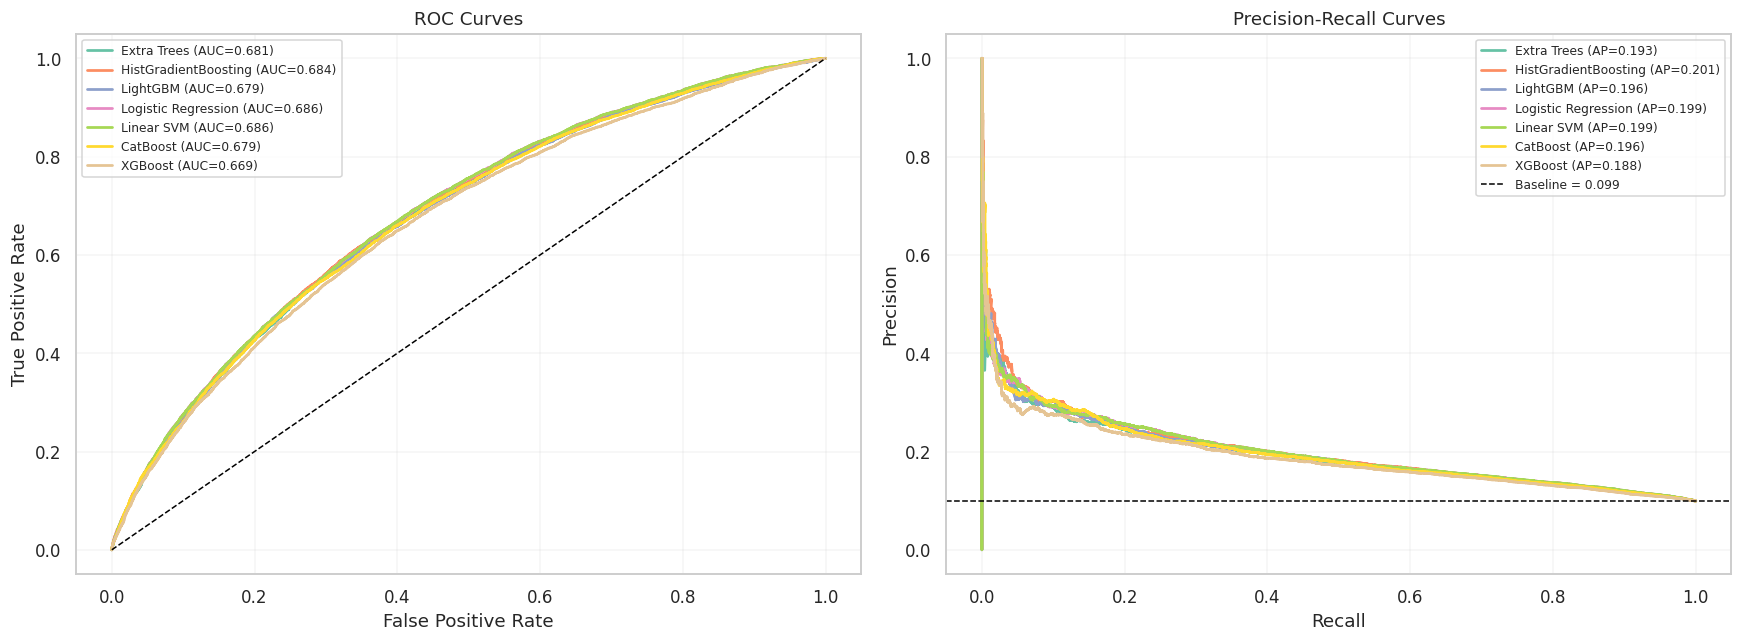

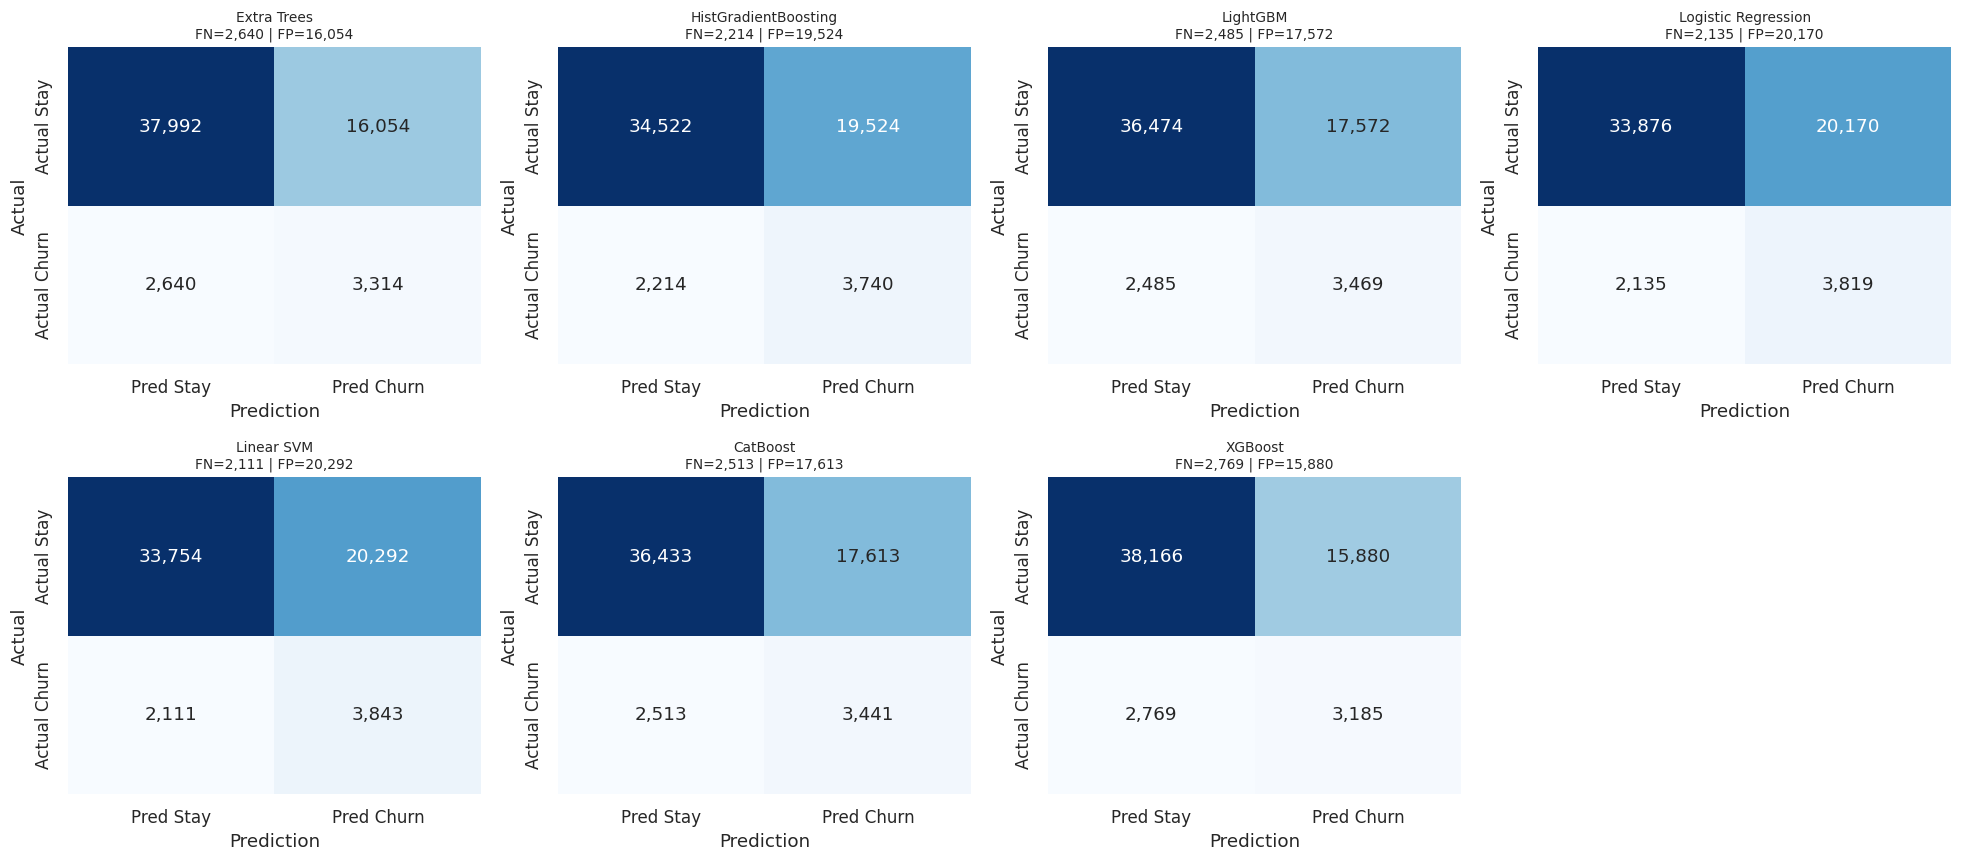

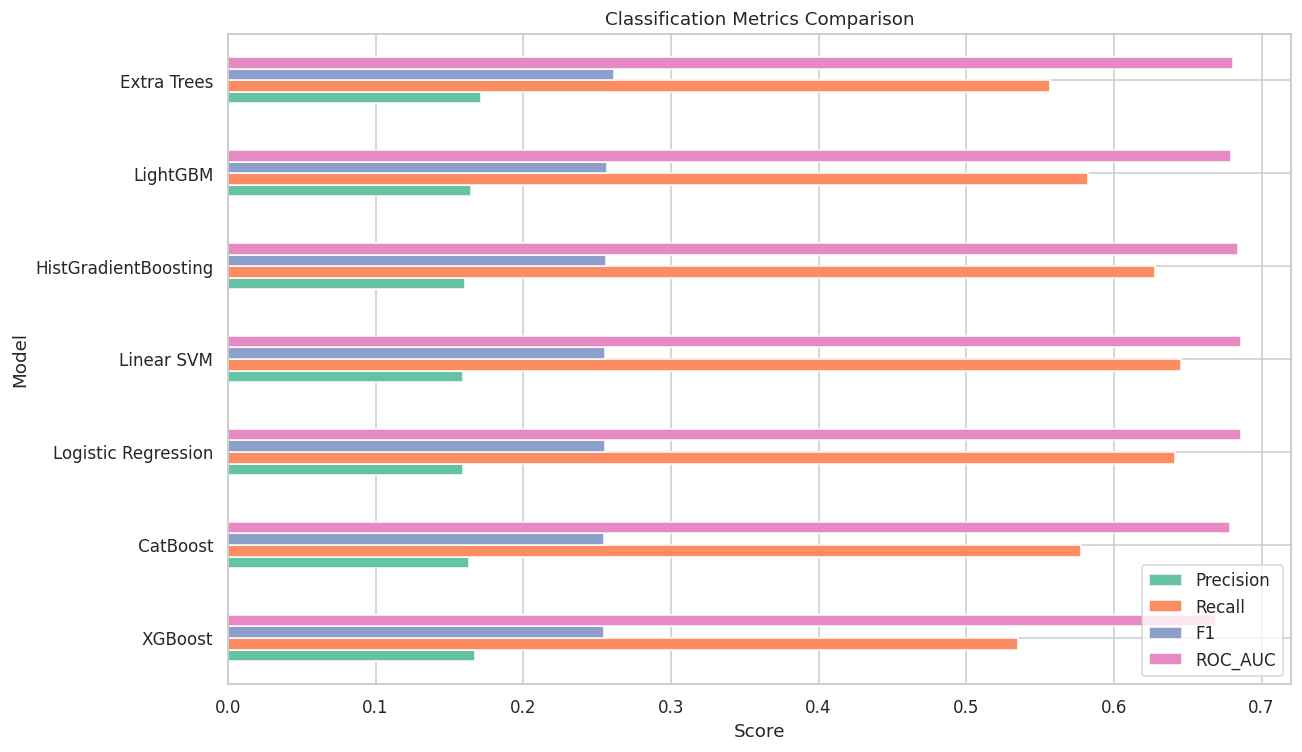


⚠ MODEL SELECTION

No final model is selected in this cell.

The current test-set results are for visualization/comparison only.
Final model selection will be done after validation + threshold tuning.



In [16]:
# ============================================================
# CELL 14 : ROC, Precision-Recall & Confusion Matrices
# VISUALIZATION ONLY
# ============================================================

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# SELECT CANDIDATE MODELS
# ============================================================

candidate_models = [
    "Extra Trees",
    "HistGradientBoosting",
    "LightGBM",
    "Logistic Regression",
    "Linear SVM",
    "CatBoost",
    "XGBoost"
]

top_models = [
    name for name in candidate_models
    if name in clf_scores
]

print("Models used for visualization:")
print(top_models)


# ============================================================
# 1. ROC + PRECISION-RECALL CURVES
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(16, 6))


for name in top_models:

    proba, score, _ = clf_scores[name]

    if score is None:
        continue

    # -------------------------
    # ROC
    # -------------------------

    fpr, tpr, _ = roc_curve(
        yc_te,
        score
    )

    auc_value = roc_auc_score(
        yc_te,
        score
    )

    ax[0].plot(
        fpr,
        tpr,
        lw=1.8,
        label=f"{name} (AUC={auc_value:.3f})"
    )

    # -------------------------
    # Precision-Recall
    # -------------------------

    precision, recall, _ = precision_recall_curve(
        yc_te,
        score
    )

    ap_value = average_precision_score(
        yc_te,
        score
    )

    ax[1].plot(
        recall,
        precision,
        lw=1.8,
        label=f"{name} (AP={ap_value:.3f})"
    )


# Random baseline for ROC
ax[0].plot(
    [0, 1],
    [0, 1],
    "k--",
    lw=1
)

ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")
ax[0].set_title("ROC Curves")
ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.2)


# Random baseline for PR
ax[1].axhline(
    yc_te.mean(),
    ls="--",
    color="k",
    lw=1,
    label=f"Baseline = {yc_te.mean():.3f}"
)

ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision-Recall Curves")
ax[1].legend(fontsize=8)
ax[1].grid(alpha=0.2)


plt.tight_layout()
plt.show()


# ============================================================
# 2. CONFUSION MATRICES
# ============================================================

n = len(top_models)

cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, 4 * rows)
)

axes = np.array(axes).ravel()


for i, name in enumerate(top_models):

    pred = clf_scores[name][2]

    cm = confusion_matrix(
        yc_te,
        pred
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        ax=axes[i],
        xticklabels=[
            "Pred Stay",
            "Pred Churn"
        ],
        yticklabels=[
            "Actual Stay",
            "Actual Churn"
        ]
    )

    tn, fp, fn, tp = cm.ravel()

    axes[i].set_title(
        f"{name}\n"
        f"FN={fn:,} | FP={fp:,}",
        fontsize=9
    )

    axes[i].set_xlabel("Prediction")
    axes[i].set_ylabel("Actual")


# Hide unused axes
for j in range(len(top_models), len(axes)):
    axes[j].axis("off")


plt.tight_layout()
plt.show()


# ============================================================
# 3. METRICS COMPARISON
# ============================================================

metrics_to_plot = [
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]

mm = (
    clf_table[
        clf_table["Model"].isin(top_models)
    ]
    .set_index("Model")[metrics_to_plot]
    .sort_values("F1")
)


mm.plot(
    kind="barh",
    figsize=(12, 7)
)

plt.title(
    "Classification Metrics Comparison"
)

plt.xlabel("Score")
plt.ylabel("Model")
plt.legend(
    loc="lower right"
)

plt.tight_layout()
plt.show()


# ============================================================
# IMPORTANT
# ============================================================

print("\n" + "=" * 75)
print("⚠ MODEL SELECTION")
print("=" * 75)

print(
    """
No final model is selected in this cell.

The current test-set results are for visualization/comparison only.
Final model selection will be done after validation + threshold tuning.
"""
)

⑤ THRESHOLD ANALYSIS — EXPLORATORY

Models analyzed:
• Extra Trees
• HistGradientBoosting
• LightGBM
• Logistic Regression
• CatBoost
• XGBoost

📊 BEST F1 THRESHOLD — EXPLORATORY


,Model,Threshold,Precision,Recall,F1,Cost,FN,FP
0,Logistic Regression,0.580000,0.190800,0.449300,0.267900,2206700,3279,11344
1,LightGBM,0.550000,0.187000,0.470800,0.267700,2184900,3151,12188
2,HistGradientBoosting,0.580000,0.195100,0.426100,0.267600,2231850,3417,10467
3,CatBoost,0.560000,0.188900,0.439500,0.264200,2230350,3337,11237
4,Extra Trees,0.540000,0.191100,0.423600,0.263400,2249600,3432,10672
5,XGBoost,0.540000,0.181100,0.442600,0.257100,2255050,3319,11911



💰 LOWEST BUSINESS COST — EXPLORATORY


,Model,Threshold,Precision,Recall,F1,Cost,FN,FP
0,Logistic Regression,0.47,0.1506,0.7068,0.2483,2059450,1746,23729
1,HistGradientBoosting,0.47,0.1513,0.6960,0.2485,2067450,1810,23249
2,Extra Trees,0.45,0.1501,0.6916,0.2466,2084250,1836,23325
3,CatBoost,0.44,0.1471,0.7098,0.2438,2088650,1728,24493
4,LightGBM,0.47,0.1553,0.6503,0.2507,2094050,2082,21061
5,XGBoost,0.42,0.1452,0.6980,0.2405,2121900,1798,24458


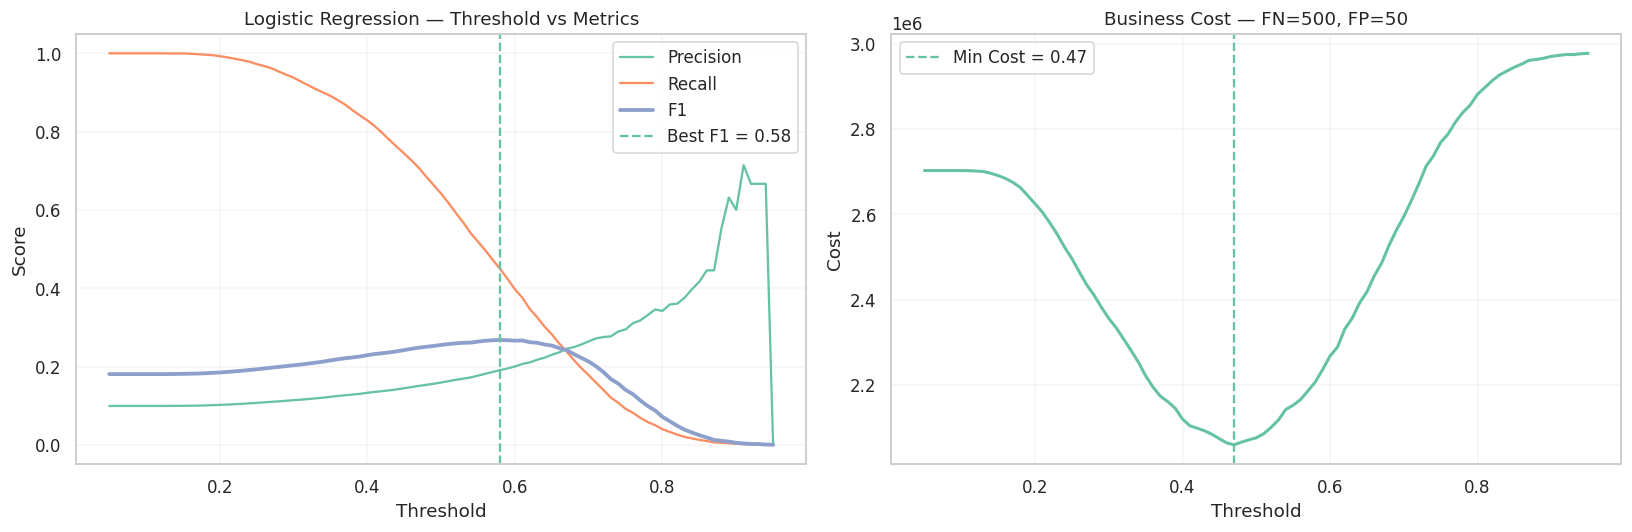


⚠ IMPORTANT

These threshold results are EXPLORATORY because they use the test set.

Do NOT save this threshold as the final production threshold yet.

Next step:
1. Create a validation set from the training data.
2. Select/tune the model using validation data.
3. Select the threshold using validation data.
4. Retrain the selected model on the training data.
5. Evaluate ONCE on the untouched test set.



In [17]:
# ============================================================
# CELL 15 : THRESHOLD ANALYSIS + BUSINESS COST
# EXPLORATORY ONLY
# ============================================================

print("=" * 75)
print("⑤ THRESHOLD ANALYSIS — EXPLORATORY")
print("=" * 75)

# ============================================================
# BUSINESS COST ASSUMPTIONS
# ============================================================

# These are scenario assumptions for analysis only.
# Replace them with real business costs if available.

COST_FN = 500
COST_FP = 50


# ============================================================
# CANDIDATE MODELS
# ============================================================

candidate_models = [
    "Extra Trees",
    "HistGradientBoosting",
    "LightGBM",
    "Logistic Regression",
    "Linear SVM",
    "CatBoost",
    "XGBoost"
]

candidate_models = [
    name for name in candidate_models
    if name in clf_scores
    and clf_scores[name][0] is not None
]

print("\nModels analyzed:")
for name in candidate_models:
    print("•", name)


# ============================================================
# THRESHOLD RANGE
# ============================================================

thresholds = np.arange(
    0.05,
    0.96,
    0.01
)

all_threshold_results = []


# ============================================================
# ANALYZE EACH MODEL
# ============================================================

for model_name in candidate_models:

    proba = clf_scores[model_name][0]

    for threshold in thresholds:

        pred = (
            proba >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            yc_te,
            pred
        ).ravel()

        precision = precision_score(
            yc_te,
            pred,
            zero_division=0
        )

        recall = recall_score(
            yc_te,
            pred,
            zero_division=0
        )

        f1 = f1_score(
            yc_te,
            pred,
            zero_division=0
        )

        cost = (
            fn * COST_FN
            + fp * COST_FP
        )

        all_threshold_results.append({

            "Model": model_name,

            "Threshold": round(
                float(threshold),
                2
            ),

            "Precision": round(
                precision,
                4
            ),

            "Recall": round(
                recall,
                4
            ),

            "F1": round(
                f1,
                4
            ),

            "Cost": cost,

            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })


threshold_table = pd.DataFrame(
    all_threshold_results
)


# ============================================================
# BEST F1 PER MODEL
# ============================================================

best_f1_table = (
    threshold_table
    .sort_values(
        ["Model", "F1"],
        ascending=[True, False]
    )
    .groupby(
        "Model",
        as_index=False
    )
    .head(1)
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 75)
print("📊 BEST F1 THRESHOLD — EXPLORATORY")
print("=" * 75)

display(
    best_f1_table[
        [
            "Model",
            "Threshold",
            "Precision",
            "Recall",
            "F1",
            "Cost",
            "FN",
            "FP"
        ]
    ].style.background_gradient(
        subset=[
            "Precision",
            "Recall",
            "F1"
        ],
        cmap="Greens"
    )
)


# ============================================================
# BEST COST PER MODEL
# ============================================================

best_cost_table = (
    threshold_table
    .sort_values(
        ["Model", "Cost"],
        ascending=[True, True]
    )
    .groupby(
        "Model",
        as_index=False
    )
    .head(1)
    .sort_values(
        "Cost",
        ascending=True
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 75)
print("💰 LOWEST BUSINESS COST — EXPLORATORY")
print("=" * 75)

display(
    best_cost_table[
        [
            "Model",
            "Threshold",
            "Precision",
            "Recall",
            "F1",
            "Cost",
            "FN",
            "FP"
        ]
    ]
)


# ============================================================
# PLOT BEST CANDIDATE CURVES
# ============================================================

# Use the model with the highest exploratory F1
plot_model = best_f1_table.iloc[0]["Model"]

model_df = threshold_table[
    threshold_table["Model"] == plot_model
]


fig, ax = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

ax[0].plot(
    model_df["Threshold"],
    model_df["Precision"],
    label="Precision"
)

ax[0].plot(
    model_df["Threshold"],
    model_df["Recall"],
    label="Recall"
)

ax[0].plot(
    model_df["Threshold"],
    model_df["F1"],
    label="F1",
    lw=2.5
)

best_row = best_f1_table[
    best_f1_table["Model"] == plot_model
].iloc[0]


ax[0].axvline(
    best_row["Threshold"],
    ls="--",
    label=f"Best F1 = {best_row['Threshold']:.2f}"
)

ax[0].set_xlabel(
    "Threshold"
)

ax[0].set_ylabel(
    "Score"
)

ax[0].set_title(
    f"{plot_model} — Threshold vs Metrics"
)

ax[0].legend()
ax[0].grid(alpha=0.2)


# ------------------------------------------------------------
# Business Cost
# ------------------------------------------------------------

ax[1].plot(
    model_df["Threshold"],
    model_df["Cost"],
    lw=2
)

best_cost_row = best_cost_table[
    best_cost_table["Model"] == plot_model
].iloc[0]


ax[1].axvline(
    best_cost_row["Threshold"],
    ls="--",
    label=(
        f"Min Cost = "
        f"{best_cost_row['Threshold']:.2f}"
    )
)

ax[1].set_xlabel(
    "Threshold"
)

ax[1].set_ylabel(
    "Cost"
)

ax[1].set_title(
    f"Business Cost — "
    f"FN={COST_FN}, FP={COST_FP}"
)

ax[1].legend()
ax[1].grid(alpha=0.2)


plt.tight_layout()
plt.show()


# ============================================================
# IMPORTANT NOTE
# ============================================================

print("\n" + "=" * 75)
print("⚠ IMPORTANT")
print("=" * 75)

print("""
These threshold results are EXPLORATORY because they use the test set.

Do NOT save this threshold as the final production threshold yet.

Next step:
1. Create a validation set from the training data.
2. Select/tune the model using validation data.
3. Select the threshold using validation data.
4. Retrain the selected model on the training data.
5. Evaluate ONCE on the untouched test set.
""")


# ============================================================
# SAVE
# ============================================================

threshold_table.to_csv(
    "threshold_analysis_exploratory.csv",
    index=False
)

best_f1_table.to_csv(
    "best_f1_thresholds_exploratory.csv",
    index=False
)

best_cost_table.to_csv(
    "best_cost_thresholds_exploratory.csv",
    index=False
)

⑥ FEATURE IMPORTANCE & INTERPRETABILITY

Exploratory model: Extra Trees
⚠ This model is NOT declared as the final model.

📊 TOP 20 MODEL FEATURES


,importance
cat__contract,0.260912
num__customer_satisfaction,0.108179
num__num_service_calls,0.061972
num__num_complaints,0.060618
num__has_tech_support,0.039678
num__num_services,0.030571
num__late_payments,0.029856
num__has_streaming_movies,0.023908
num__has_online_security,0.023258
num__has_streaming_tv,0.023067


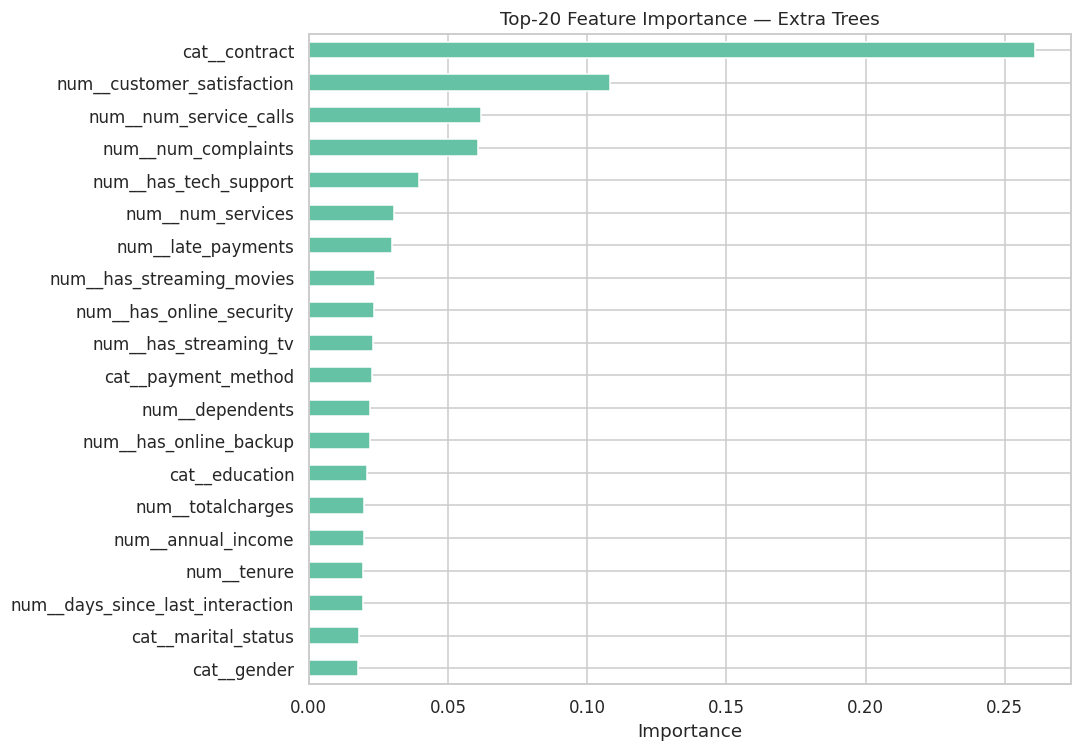


⏳ Calculating permutation importance...
Using 5,000 test rows for permutation importance...

📊 TOP 15 ORIGINAL FEATURES BY PERMUTATION IMPORTANCE


,F1_importance
contract,0.048825
has_tech_support,0.015876
late_payments,0.010831
has_online_security,0.009923
customer_satisfaction,0.009686
num_complaints,0.009082
num_service_calls,0.007439
num_services,0.004320
totalcharges,0.002621
has_streaming_tv,0.001628


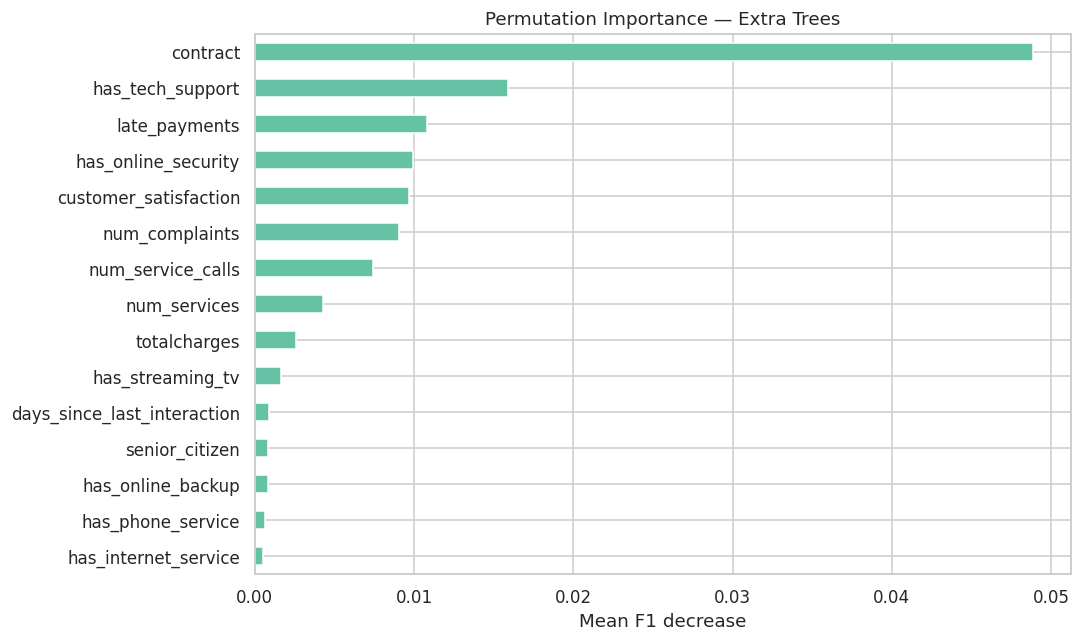


✅ CELL 16 COMPLETED

Model analyzed:
Extra Trees

Methods:
✓ Built-in Feature Importance
✓ Permutation Importance
✗ SHAP skipped intentionally

Reason:
SHAP can be computationally expensive on this dataset,
and it is not necessary for the current model benchmark.

⚠ IMPORTANT:
This is exploratory interpretation only.

The final model will be selected after:
1. Validation
2. Hyperparameter tuning
3. Threshold selection
4. Final evaluation on untouched test data



In [19]:
# ============================================================
# CELL 16 : Feature Importance & Interpretability
# EXPLORATORY ONLY
# ============================================================

from sklearn.inspection import permutation_importance

print("=" * 75)
print("⑥ FEATURE IMPORTANCE & INTERPRETABILITY")
print("=" * 75)


# ============================================================
# SELECT MODEL FOR EXPLORATION
# ============================================================

# Temporary exploratory model only.
# This is NOT the final production model.

candidate_for_interpretation = [
    "Extra Trees",
    "HistGradientBoosting",
    "LightGBM",
    "CatBoost",
    "XGBoost",
    "Logistic Regression"
]

available = [
    name
    for name in candidate_for_interpretation
    if name in clf_fitted
]

if not available:
    raise ValueError(
        "No suitable fitted model found."
    )

interpret_model_name = available[0]

best_pipe = clf_fitted[
    interpret_model_name
]

print(
    f"\nExploratory model: {interpret_model_name}"
)

print(
    "⚠ This model is NOT declared as the final model."
)


# ============================================================
# FEATURE NAMES
# ============================================================

try:

    feat_names = (
        best_pipe
        .named_steps["prep"]
        .get_feature_names_out()
    )

except Exception:

    feat_names = np.array(
        clf_num + clf_cat
    )


model = best_pipe.named_steps["model"]


# ============================================================
# 1. BUILT-IN FEATURE IMPORTANCE
# ============================================================

imp_series = None


if hasattr(
    model,
    "feature_importances_"
):

    importances = np.ravel(
        model.feature_importances_
    )

    n = min(
        len(importances),
        len(feat_names)
    )

    imp_series = pd.Series(
        importances[:n],
        index=feat_names[:n]
    )


elif hasattr(
    model,
    "coef_"
):

    coefficients = np.abs(
        np.ravel(
            model.coef_
        )
    )

    n = min(
        len(coefficients),
        len(feat_names)
    )

    imp_series = pd.Series(
        coefficients[:n],
        index=feat_names[:n]
    )


if imp_series is not None:

    top_features = (
        imp_series
        .sort_values(
            ascending=False
        )
        .head(20)
    )

    print(
        "\n📊 TOP 20 MODEL FEATURES"
    )

    display(
        top_features.to_frame(
            "importance"
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    top_features.sort_values().plot(
        kind="barh"
    )

    plt.title(
        f"Top-20 Feature Importance — "
        f"{interpret_model_name}"
    )

    plt.xlabel(
        "Importance"
    )

    plt.tight_layout()
    plt.show()

else:

    print(
        "\n⚠ Built-in feature importance "
        "is not available for this model."
    )


# ============================================================
# 2. PERMUTATION IMPORTANCE
# ============================================================

print(
    "\n⏳ Calculating permutation importance..."
)

rng = np.random.RandomState(
    RANDOM_STATE
)

sample_size = min(
    5_000,
    len(Xc_te)
)

idx = rng.choice(
    len(Xc_te),
    sample_size,
    replace=False
)

print(
    f"Using {sample_size:,} test rows "
    "for permutation importance..."
)


pi = permutation_importance(
    best_pipe,
    Xc_te.iloc[idx],
    yc_te.iloc[idx],
    n_repeats=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="f1"
)


# Permutation importance is calculated
# on the ORIGINAL input columns.

pis = pd.Series(
    pi.importances_mean,
    index=Xc_te.columns
).sort_values(
    ascending=False
)


top_pi = pis.head(15)


print(
    "\n📊 TOP 15 ORIGINAL FEATURES "
    "BY PERMUTATION IMPORTANCE"
)

display(
    top_pi.to_frame(
        "F1_importance"
    )
)


plt.figure(
    figsize=(10, 6)
)

top_pi.sort_values().plot(
    kind="barh"
)

plt.title(
    f"Permutation Importance — "
    f"{interpret_model_name}"
)

plt.xlabel(
    "Mean F1 decrease"
)

plt.tight_layout()
plt.show()


# ============================================================
# 3. SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("✅ CELL 16 COMPLETED")
print("=" * 75)

print(f"""
Model analyzed:
{interpret_model_name}

Methods:
✓ Built-in Feature Importance
✓ Permutation Importance
✗ SHAP skipped intentionally

Reason:
SHAP can be computationally expensive on this dataset,
and it is not necessary for the current model benchmark.

⚠ IMPORTANT:
This is exploratory interpretation only.

The final model will be selected after:
1. Validation
2. Hyperparameter tuning
3. Threshold selection
4. Final evaluation on untouched test data
""")

print("=" * 75)

⑦ CLUSTERING DATA PREPARATION

Clustering sample: 60,000 rows

Numerical features:
['age', 'annual_income', 'dependents', 'tenure', 'senior_citizen', 'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service', 'has_internet_service', 'has_online_security', 'has_online_backup']

Categorical features:
['gender', 'education', 'marital_status', 'contract', 'payment_method']

Scaled matrix shape: (60000, 31)

Components required for 95% variance: 18


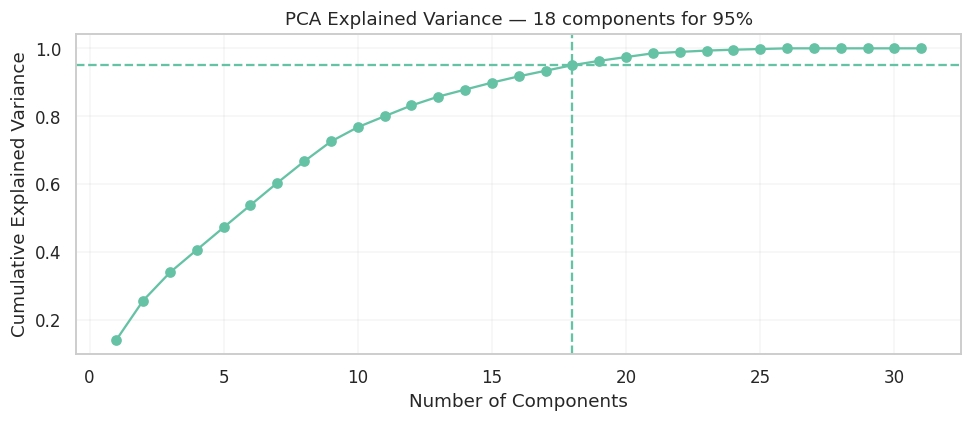


PCA clustering space: (60000, 18)
PCA visualization space: (60000, 2)

✅ Cell 17 completed.


In [20]:
# ============================================================
# CELL 17 : Clustering Data Preparation
# Scaling + PCA
# ============================================================

from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("=" * 80)
print("⑦ CLUSTERING DATA PREPARATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Sample data for clustering
# ------------------------------------------------------------

cluster_n = min(
    SAMPLE_CLUSTER,
    len(work)
)

seg_source = (
    work
    .sample(
        cluster_n,
        random_state=RANDOM_STATE
    )
    .copy()
    .reset_index(drop=True)
)

print(
    f"\nClustering sample: {len(seg_source):,} rows"
)


# ------------------------------------------------------------
# 2. Select numerical features
# ------------------------------------------------------------

seg_feats_num = [
    c for c in num_cols
    if c in seg_source.columns
][:12]


# ------------------------------------------------------------
# 3. Select low-cardinality categorical features
# ------------------------------------------------------------

seg_feats_cat = [
    c for c in cat_cols
    if c in seg_source.columns
    and seg_source[c].nunique(dropna=True) <= 8
][:5]


print(
    "\nNumerical features:"
)

print(seg_feats_num)

print(
    "\nCategorical features:"
)

print(seg_feats_cat)


if len(seg_feats_num) == 0 and len(seg_feats_cat) == 0:
    raise ValueError(
        "No suitable clustering features were found."
    )


# ------------------------------------------------------------
# 4. Prepare data
# ------------------------------------------------------------

seg_features = (
    seg_feats_num +
    seg_feats_cat
)

seg_X = (
    seg_source[
        seg_features
    ]
    .copy()
)


if seg_feats_cat:

    seg_X[seg_feats_cat] = (
        seg_X[seg_feats_cat]
        .astype(str)
    )


# ------------------------------------------------------------
# 5. Preprocessing
# ------------------------------------------------------------

transformers = []

if seg_feats_num:

    transformers.append(
        (
            "num",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            seg_feats_num
        )
    )


if seg_feats_cat:

    transformers.append(
        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "ohe",
                    make_ohe()
                )
            ]),
            seg_feats_cat
        )
    )


seg_prep = ColumnTransformer(
    transformers=transformers,
    sparse_threshold=0
)


# ------------------------------------------------------------
# 6. Transform
# ------------------------------------------------------------

Z = seg_prep.fit_transform(
    seg_X
)

Z = (
    Z.toarray()
    if hasattr(Z, "toarray")
    else np.asarray(Z)
)

print(
    f"\nScaled matrix shape: {Z.shape}"
)


# ------------------------------------------------------------
# 7. PCA
# ------------------------------------------------------------

pca_full = PCA(
    random_state=RANDOM_STATE
)

pca_full.fit(Z)

cum = np.cumsum(
    pca_full.explained_variance_ratio_
)

n95 = int(
    np.argmax(
        cum >= 0.95
    ) + 1
)


print(
    f"\nComponents required for 95% variance: {n95}"
)


# ------------------------------------------------------------
# 8. Explained variance plot
# ------------------------------------------------------------

plt.figure(
    figsize=(9, 4)
)

plt.plot(
    range(1, len(cum) + 1),
    cum,
    "o-"
)

plt.axhline(
    0.95,
    linestyle="--"
)

plt.axvline(
    n95,
    linestyle="--"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    f"PCA Explained Variance — {n95} components for 95%"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 9. PCA representation for clustering
# ------------------------------------------------------------

pca_components = min(
    n95,
    Z.shape[1]
)

pca_model = PCA(
    n_components=pca_components,
    random_state=RANDOM_STATE
)

Zp = pca_model.fit_transform(
    Z
)


# ------------------------------------------------------------
# 10. 2D PCA only for visualization
# ------------------------------------------------------------

pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

Z2 = pca_2d.fit_transform(
    Z
)


print(
    f"\nPCA clustering space: {Zp.shape}"
)

print(
    f"PCA visualization space: {Z2.shape}"
)

print(
    "\n✅ Cell 17 completed."
)

⑧ K-MEANS: ELBOW + SILHOUETTE ANALYSIS
k= 2 | Inertia=776,215 | Silhouette=0.1578 | DB=2.0119 | CH=6,889
k= 3 | Inertia=700,104 | Silhouette=0.1382 | DB=2.3029 | CH=7,080
k= 4 | Inertia=658,418 | Silhouette=0.1093 | DB=2.5537 | CH=6,285
k= 5 | Inertia=625,907 | Silhouette=0.1087 | DB=2.4239 | CH=5,738
k= 6 | Inertia=602,780 | Silhouette=0.1032 | DB=2.3265 | CH=5,226
k= 7 | Inertia=584,907 | Silhouette=0.0946 | DB=2.2514 | CH=4,794
k= 8 | Inertia=570,636 | Silhouette=0.0822 | DB=2.2004 | CH=4,426
k= 9 | Inertia=558,712 | Silhouette=0.0833 | DB=2.3123 | CH=4,115
k=10 | Inertia=548,105 | Silhouette=0.0789 | DB=2.2450 | CH=3,858

✅ BEST K BY SILHOUETTE = 2
   Silhouette = 0.1578


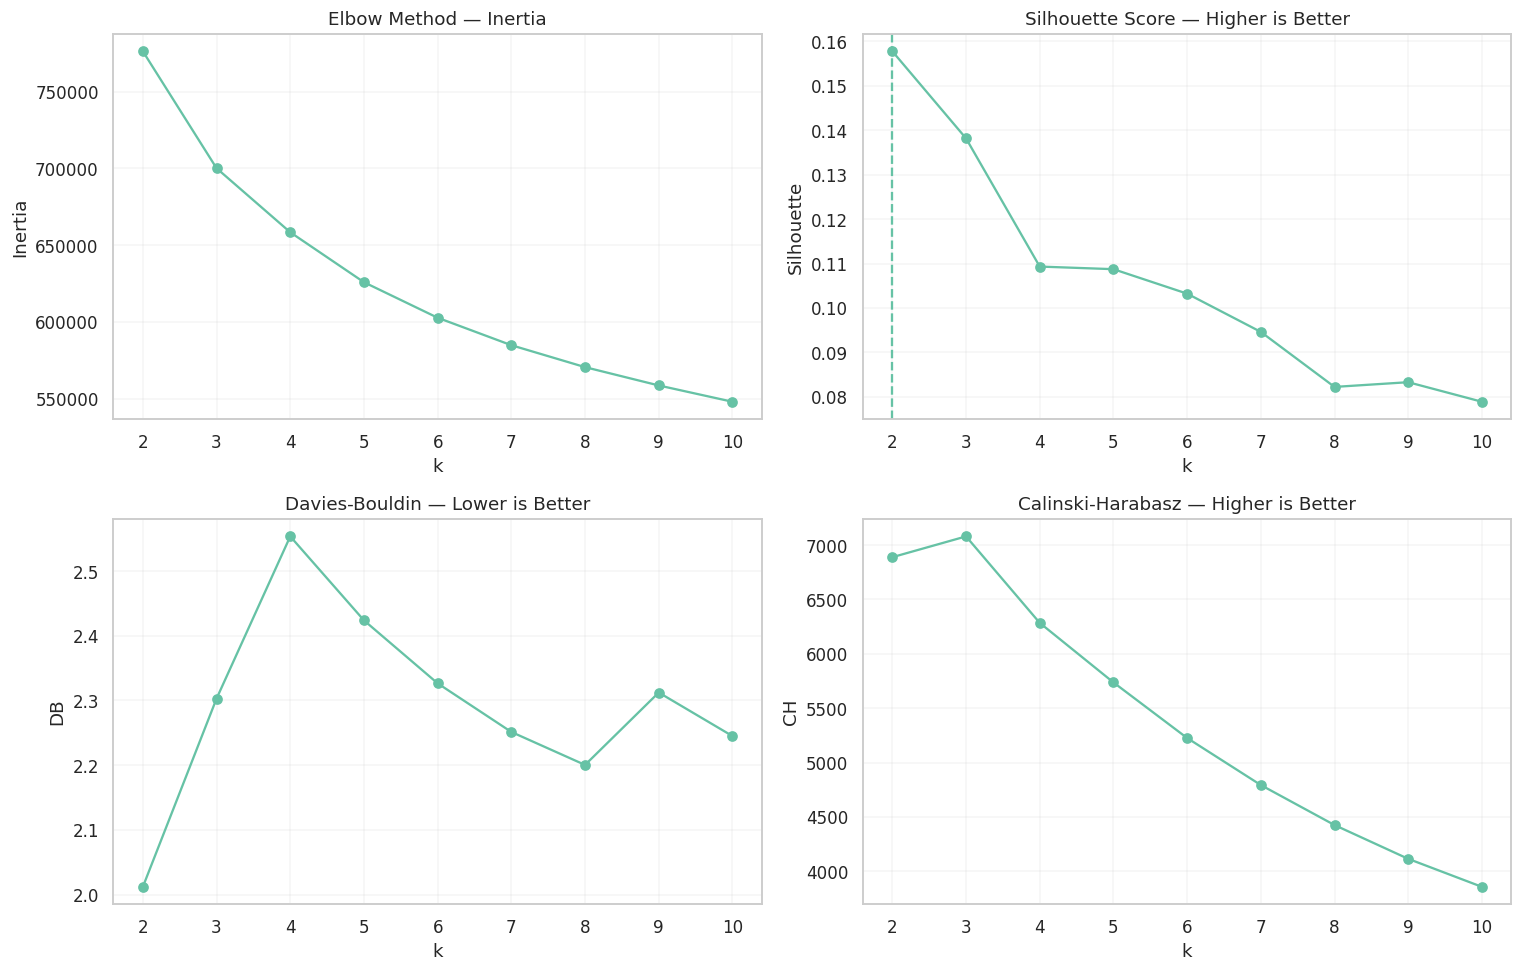

In [21]:
# ============================================================
# CELL 18 : KMeans — Elbow + Silhouette
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

print("=" * 80)
print("⑧ K-MEANS: ELBOW + SILHOUETTE ANALYSIS")
print("=" * 80)


# ------------------------------------------------------------
# K range
# ------------------------------------------------------------

K_RANGE = range(2, 11)

inertias = []
sils = []
dbs = []
chs = []

sil_sample = min(
    10_000,
    len(Zp)
)


# ------------------------------------------------------------
# Test different k
# ------------------------------------------------------------

for k in K_RANGE:

    km = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=RANDOM_STATE
    )

    labels = km.fit_predict(
        Zp
    )

    inertia = km.inertia_

    sil = silhouette_score(
        Zp,
        labels,
        sample_size=sil_sample,
        random_state=RANDOM_STATE
    )

    db = davies_bouldin_score(
        Zp,
        labels
    )

    ch = calinski_harabasz_score(
        Zp,
        labels
    )

    inertias.append(
        inertia
    )

    sils.append(
        sil
    )

    dbs.append(
        db
    )

    chs.append(
        ch
    )

    print(
        f"k={k:2d} | "
        f"Inertia={inertia:,.0f} | "
        f"Silhouette={sil:.4f} | "
        f"DB={db:.4f} | "
        f"CH={ch:,.0f}"
    )


# ------------------------------------------------------------
# Best k according to Silhouette
# ------------------------------------------------------------

BEST_K = list(
    K_RANGE
)[
    int(
        np.argmax(sils)
    )
]


best_silhouette = max(
    sils
)


print(
    "\n" + "=" * 80
)

print(
    f"✅ BEST K BY SILHOUETTE = {BEST_K}"
)

print(
    f"   Silhouette = {best_silhouette:.4f}"
)

print(
    "=" * 80
)


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9)
)

k_values = list(
    K_RANGE
)


axes[0, 0].plot(
    k_values,
    inertias,
    "o-"
)

axes[0, 0].set_title(
    "Elbow Method — Inertia"
)

axes[0, 0].set_xlabel(
    "k"
)

axes[0, 0].set_ylabel(
    "Inertia"
)


axes[0, 1].plot(
    k_values,
    sils,
    "o-"
)

axes[0, 1].axvline(
    BEST_K,
    linestyle="--"
)

axes[0, 1].set_title(
    "Silhouette Score — Higher is Better"
)

axes[0, 1].set_xlabel(
    "k"
)

axes[0, 1].set_ylabel(
    "Silhouette"
)


axes[1, 0].plot(
    k_values,
    dbs,
    "o-"
)

axes[1, 0].set_title(
    "Davies-Bouldin — Lower is Better"
)

axes[1, 0].set_xlabel(
    "k"
)

axes[1, 0].set_ylabel(
    "DB"
)


axes[1, 1].plot(
    k_values,
    chs,
    "o-"
)

axes[1, 1].set_title(
    "Calinski-Harabasz — Higher is Better"
)

axes[1, 1].set_xlabel(
    "k"
)

axes[1, 1].set_ylabel(
    "CH"
)


for ax in axes.ravel():

    ax.grid(
        alpha=0.2
    )


plt.tight_layout()
plt.show()

⑨ CLUSTERING ALGORITHMS COMPARISON — FAST VERSION

🔷 1. K-Means
✔ KMeans (k=2)                        k=2 | Sil=0.1569 | DB=2.0152 | CH=546.1 | Dunn=0.3365 | Noise=0

🔷 2. MiniBatch K-Means
✔ MiniBatchKMeans (k=2)               k=2 | Sil=0.0807 | DB=3.1698 | CH=476.5 | Dunn=0.1455 | Noise=0

🔷 3. Hierarchical Clustering
✔ Hierarchical (ward)                 k=2 | Sil=0.1563 | DB=1.997 | CH=215.6 | Dunn=0.3235 | Noise=0
✔ Hierarchical (average)              k=2 | Sil=0.1966 | DB=1.4493 | CH=4.5 | Dunn=0.3585 | Noise=0
✔ Hierarchical (complete)             k=2 | Sil=0.1176 | DB=2.5435 | CH=176.1 | Dunn=0.1697 | Noise=0

🔷 4. DBSCAN


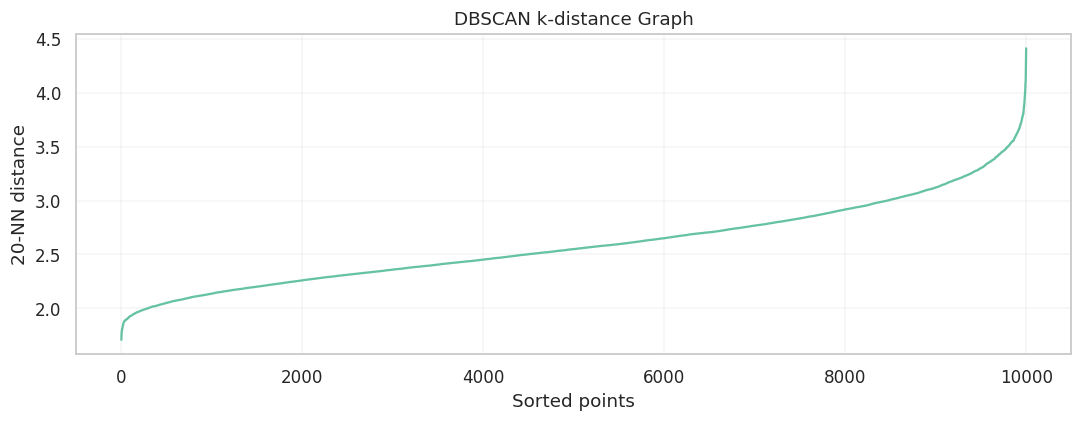


DBSCAN eps candidates: [3.1213, 3.3009]
✘ DBSCAN (eps=3.1213): insufficient clusters
✘ DBSCAN (eps=3.3009): insufficient clusters

🔷 5. HDBSCAN
✔ HDBSCAN                             k=2 | Sil=0.1732 | DB=1.8233 | CH=644.5 | Dunn=0.3794 | Noise=2291

🔷 6. Gaussian Mixture Models
✔ GMM (diag)                          k=2 | Sil=0.1458 | DB=2.1014 | CH=433.3 | Dunn=0.1638 | Noise=0

🔷 7. BIRCH
✔ BIRCH (threshold=0.5)               k=2 | Sil=0.1576 | DB=1.9953 | CH=551.2 | Dunn=0.3377 | Noise=0
✔ BIRCH (threshold=0.8)               k=2 | Sil=0.1576 | DB=1.9953 | CH=551.2 | Dunn=0.3377 | Noise=0

📊 CLUSTERING COMPARISON


,Model,n_clusters,Noise_pts,Noise_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Dunn_Index,Note
0,Hierarchical (average),2,0,0.00,0.1966,1.4493,4.5,0.3585,"Sample=2,000"
1,HDBSCAN,2,2291,22.91,0.1732,1.8233,644.5,0.3794,Density-based | Sample
2,BIRCH (threshold=0.5),2,0,0.00,0.1576,1.9953,551.2,0.3377,"Sample=20,000"
3,BIRCH (threshold=0.8),2,0,0.00,0.1576,1.9953,551.2,0.3377,"Sample=20,000"
4,KMeans (k=2),2,0,0.00,0.1569,2.0152,546.1,0.3365,Centroid-based | Full clustering sample
5,Hierarchical (ward),2,0,0.00,0.1563,1.9970,215.6,0.3235,"Sample=2,000"
6,GMM (diag),2,0,0.00,0.1458,2.1014,433.3,0.1638,"Sample=10,000 | BIC=432672"
7,Hierarchical (complete),2,0,0.00,0.1176,2.5435,176.1,0.1697,"Sample=2,000"
8,MiniBatchKMeans (k=2),2,0,0.00,0.0807,3.1698,476.5,0.1455,Scalable | Full clustering sample
9,DBSCAN (eps=3.1213),1,84,0.84,NaN,NaN,NaN,NaN,Density-based | Sample



✅ Saved: clustering_comparison.csv

📌 Highest Silhouette in this exploratory comparison:
Model: Hierarchical (average)
Silhouette: 0.1966
Davies-Bouldin: 1.4493
Calinski-Harabasz: 4.5
Dunn Index: 0.3585
Clusters: 2

⚠ Clustering results are exploratory.
✓ clu_X has been created for Cell 20.


In [30]:
# ============================================================
# CELL 19 : Clustering Algorithms Comparison — FAST & SAFE
# ============================================================

from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    DBSCAN,
    Birch
)

from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.spatial.distance import pdist, squareform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")


print("=" * 85)
print("⑨ CLUSTERING ALGORITHMS COMPARISON — FAST VERSION")
print("=" * 85)


# ============================================================
# 1. Dunn Index
# ============================================================

def dunn_index(X, labels, max_n=1000):

    X = np.asarray(X)
    labels = np.asarray(labels)

    valid = labels >= 0

    X = X[valid]
    labels = labels[valid]

    unique = np.unique(labels)

    if len(unique) < 2:
        return np.nan

    # Limit calculation for speed
    if len(X) > max_n:

        rng = np.random.RandomState(
            RANDOM_STATE
        )

        idx = rng.choice(
            len(X),
            max_n,
            replace=False
        )

        X = X[idx]
        labels = labels[idx]

        unique = np.unique(labels)

        if len(unique) < 2:
            return np.nan

    try:

        D = squareform(
            pdist(X)
        )

    except Exception:

        return np.nan


    # --------------------------------------------------------
    # Maximum intra-cluster distance
    # --------------------------------------------------------

    max_intra = 0.0

    for c in unique:

        members = np.where(
            labels == c
        )[0]

        if len(members) > 1:

            diameter = D[
                np.ix_(
                    members,
                    members
                )
            ].max()

            max_intra = max(
                max_intra,
                diameter
            )


    if max_intra <= 0:
        return np.nan


    # --------------------------------------------------------
    # Minimum inter-cluster distance
    # --------------------------------------------------------

    min_inter = np.inf

    for i in range(
        len(unique)
    ):

        for j in range(
            i + 1,
            len(unique)
        ):

            a = np.where(
                labels == unique[i]
            )[0]

            b = np.where(
                labels == unique[j]
            )[0]

            if len(a) and len(b):

                distance = D[
                    np.ix_(
                        a,
                        b
                    )
                ].min()

                min_inter = min(
                    min_inter,
                    distance
                )


    if not np.isfinite(
        min_inter
    ):

        return np.nan


    return (
        min_inter /
        max_intra
    )


# ============================================================
# 2. Evaluation Function
# ============================================================

clu_results = []

clu_labels = {}

# IMPORTANT:
# Store the exact X used by each clustering algorithm.
clu_X = {}


def eval_clu(
    name,
    labels,
    X,
    note=""
):

    labels = np.asarray(
        labels
    )

    X = np.asarray(
        X
    )


    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if len(labels) != len(X):

        print(
            f"✘ {name}: "
            f"X={len(X)} != labels={len(labels)}"
        )

        return


    # --------------------------------------------------------
    # Save exact data + labels
    # --------------------------------------------------------

    clu_labels[name] = labels
    clu_X[name] = X


    # --------------------------------------------------------
    # Remove noise for density-based algorithms
    # --------------------------------------------------------

    valid_mask = labels >= 0

    valid_labels = labels[
        valid_mask
    ]

    valid_X = X[
        valid_mask
    ]


    n_clusters = len(
        np.unique(
            valid_labels
        )
    )

    noise = int(
        (~valid_mask).sum()
    )


    # --------------------------------------------------------
    # Insufficient clusters
    # --------------------------------------------------------

    if (
        len(valid_X) == 0
        or n_clusters < 2
    ):

        print(
            f"✘ {name}: insufficient clusters"
        )

        clu_results.append({

            "Model": name,

            "n_clusters":
                n_clusters,

            "Noise_pts":
                noise,

            "Noise_%":
                round(
                    100 * noise / len(labels),
                    2
                ),

            "Silhouette":
                np.nan,

            "Davies_Bouldin":
                np.nan,

            "Calinski_Harabasz":
                np.nan,

            "Dunn_Index":
                np.nan,

            "Note":
                note

        })

        return


    # ========================================================
    # Metric Sample
    # ========================================================

    metric_n = min(
        5000,
        len(valid_X)
    )


    if len(valid_X) > metric_n:

        rng = np.random.RandomState(
            RANDOM_STATE
        )

        idx = rng.choice(
            len(valid_X),
            metric_n,
            replace=False
        )

        metric_X = valid_X[
            idx
        ]

        metric_labels = valid_labels[
            idx
        ]

    else:

        metric_X = valid_X
        metric_labels = valid_labels


    # --------------------------------------------------------
    # Make sure metric sample has >= 2 clusters
    # --------------------------------------------------------

    if len(
        np.unique(metric_labels)
    ) < 2:

        ss = np.nan
        db = np.nan
        ch = np.nan
        di = np.nan

    else:

        # Silhouette
        try:

            ss = silhouette_score(
                metric_X,
                metric_labels
            )

        except Exception:

            ss = np.nan


        # Davies-Bouldin
        try:

            db = davies_bouldin_score(
                metric_X,
                metric_labels
            )

        except Exception:

            db = np.nan


        # Calinski-Harabasz
        try:

            ch = calinski_harabasz_score(
                metric_X,
                metric_labels
            )

        except Exception:

            ch = np.nan


        # Dunn
        try:

            di = dunn_index(
                metric_X,
                metric_labels
            )

        except Exception:

            di = np.nan


    # ========================================================
    # Store Results
    # ========================================================

    result = {

        "Model":
            name,

        "n_clusters":
            n_clusters,

        "Noise_pts":
            noise,

        "Noise_%":
            round(
                100 * noise / len(labels),
                2
            ),

        "Silhouette":
            round(
                float(ss),
                4
            )
            if not np.isnan(ss)
            else np.nan,

        "Davies_Bouldin":
            round(
                float(db),
                4
            )
            if not np.isnan(db)
            else np.nan,

        "Calinski_Harabasz":
            round(
                float(ch),
                1
            )
            if not np.isnan(ch)
            else np.nan,

        "Dunn_Index":
            round(
                float(di),
                4
            )
            if not np.isnan(di)
            else np.nan,

        "Note":
            note
    }


    clu_results.append(
        result
    )


    print(
        f"✔ {name:<35} "
        f"k={n_clusters} | "
        f"Sil={result['Silhouette']} | "
        f"DB={result['Davies_Bouldin']} | "
        f"CH={result['Calinski_Harabasz']} | "
        f"Dunn={result['Dunn_Index']} | "
        f"Noise={noise}"
    )


# ============================================================
# 3. K-Means
# ============================================================

print("\n🔷 1. K-Means")


km = KMeans(
    n_clusters=BEST_K,
    n_init=10,
    random_state=RANDOM_STATE
)


km_labels = km.fit_predict(
    Zp
)


eval_clu(
    f"KMeans (k={BEST_K})",
    km_labels,
    Zp,
    "Centroid-based | Full clustering sample"
)


# ============================================================
# 4. MiniBatch K-Means
# ============================================================

print("\n🔷 2. MiniBatch K-Means")


mbk = MiniBatchKMeans(
    n_clusters=BEST_K,
    batch_size=4096,
    n_init=5,
    random_state=RANDOM_STATE
)


mbk_labels = mbk.fit_predict(
    Zp
)


eval_clu(
    f"MiniBatchKMeans (k={BEST_K})",
    mbk_labels,
    Zp,
    "Scalable | Full clustering sample"
)


# ============================================================
# 5. Hierarchical Clustering
# SAMPLE ONLY
# ============================================================

print("\n🔷 3. Hierarchical Clustering")


SAMPLE_HIER_SIZE = min(
    2000,
    len(Zp)
)


rng = np.random.RandomState(
    RANDOM_STATE
)


hs = rng.choice(
    len(Zp),
    SAMPLE_HIER_SIZE,
    replace=False
)


Zh = Zp[
    hs
]


for link in [
    "ward",
    "average",
    "complete"
]:

    try:

        labels = AgglomerativeClustering(
            n_clusters=BEST_K,
            linkage=link
        ).fit_predict(
            Zh
        )


        eval_clu(
            f"Hierarchical ({link})",
            labels,
            Zh,
            f"Sample={SAMPLE_HIER_SIZE:,}"
        )

    except Exception as e:

        print(
            f"✘ Hierarchical {link}: {e}"
        )


# ============================================================
# 6. DBSCAN
# SAMPLE ONLY
# ============================================================

print("\n🔷 4. DBSCAN")


SAMPLE_DBSCAN = min(
    10_000,
    len(Zp)
)


ds = rng.choice(
    len(Zp),
    SAMPLE_DBSCAN,
    replace=False
)


Zd = Zp[
    ds
]


min_pts = max(
    5,
    min(
        20,
        2 * Zd.shape[1]
    )
)


# ------------------------------------------------------------
# k-distance
# ------------------------------------------------------------

nn = NearestNeighbors(
    n_neighbors=min_pts,
    n_jobs=-1
)


nn.fit(
    Zd
)


distances, _ = nn.kneighbors(
    Zd
)


kdist = np.sort(
    distances[:, -1]
)


plt.figure(
    figsize=(10, 4)
)


plt.plot(
    kdist
)


plt.xlabel(
    "Sorted points"
)


plt.ylabel(
    f"{min_pts}-NN distance"
)


plt.title(
    "DBSCAN k-distance Graph"
)


plt.grid(
    alpha=0.2
)


plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# EPS candidates
# ------------------------------------------------------------

eps_values = sorted(
    set([
        round(
            float(
                np.percentile(
                    kdist,
                    90
                )
            ),
            4
        ),

        round(
            float(
                np.percentile(
                    kdist,
                    95
                )
            ),
            4
        )
    ])
)


print(
    "\nDBSCAN eps candidates:",
    eps_values
)


for eps in eps_values:

    try:

        labels = DBSCAN(
            eps=eps,
            min_samples=min_pts,
            n_jobs=-1
        ).fit_predict(
            Zd
        )


        eval_clu(
            f"DBSCAN (eps={eps})",
            labels,
            Zd,
            "Density-based | Sample"
        )

    except Exception as e:

        print(
            f"✘ DBSCAN eps={eps}: {e}"
        )


# ============================================================
# 7. HDBSCAN
# SAMPLE ONLY
# ============================================================

print("\n🔷 5. HDBSCAN")


try:

    import hdbscan


    hdb = hdbscan.HDBSCAN(
        min_cluster_size=200,
        min_samples=20,
        core_dist_n_jobs=-1
    )


    hdb_labels = hdb.fit_predict(
        Zd
    )


    eval_clu(
        "HDBSCAN",
        hdb_labels,
        Zd,
        "Density-based | Sample"
    )


except Exception as e:

    print(
        f"⚠ HDBSCAN skipped: "
        f"{type(e).__name__}: {e}"
    )


# ============================================================
# 8. Gaussian Mixture
# SAMPLE ONLY
# ============================================================

print("\n🔷 6. Gaussian Mixture Models")


GMM_SIZE = min(
    10_000,
    len(Zp)
)


gm_idx = rng.choice(
    len(Zp),
    GMM_SIZE,
    replace=False
)


Zg = Zp[
    gm_idx
]


try:

    gmm = GaussianMixture(
        n_components=BEST_K,
        covariance_type="diag",
        n_init=1,
        max_iter=100,
        random_state=RANDOM_STATE
    )


    labels = gmm.fit_predict(
        Zg
    )


    eval_clu(
        "GMM (diag)",
        labels,
        Zg,
        f"Sample={GMM_SIZE:,} | BIC={gmm.bic(Zg):.0f}"
    )


except Exception as e:

    print(
        f"✘ GMM failed: {e}"
    )


# ============================================================
# 9. BIRCH
# SAMPLE ONLY
# ============================================================

print("\n🔷 7. BIRCH")


# IMPORTANT:
# Never use full Zp here.
# This sample prevents the previous long runtime.

BIRCH_SIZE = min(
    20_000,
    len(Zp)
)


birch_idx = rng.choice(
    len(Zp),
    BIRCH_SIZE,
    replace=False
)


Zb = Zp[
    birch_idx
]


for threshold in [
    0.5,
    0.8
]:

    try:

        birch = Birch(
            n_clusters=BEST_K,
            threshold=threshold,
            branching_factor=50
        )


        labels = birch.fit_predict(
            Zb
        )


        eval_clu(
            f"BIRCH (threshold={threshold})",
            labels,
            Zb,
            f"Sample={BIRCH_SIZE:,}"
        )


    except Exception as e:

        print(
            f"✘ BIRCH {threshold}: {e}"
        )


# ============================================================
# 10. Comparison Table
# ============================================================

clu_table = (
    pd.DataFrame(
        clu_results
    )
    .sort_values(
        "Silhouette",
        ascending=False,
        na_position="last"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\n" + "=" * 85
)


print(
    "📊 CLUSTERING COMPARISON"
)


print(
    "=" * 85
)


display(
    clu_table
)


# ============================================================
# 11. Save Results
# ============================================================

clu_table.to_csv(
    "clustering_comparison.csv",
    index=False
)


print(
    "\n✅ Saved: clustering_comparison.csv"
)


# ============================================================
# 12. Exploratory Highest Silhouette
# ============================================================

valid_results = clu_table.dropna(
    subset=[
        "Silhouette"
    ]
)


if not valid_results.empty:

    best_row = valid_results.iloc[0]


    print(
        "\n📌 Highest Silhouette in this exploratory comparison:"
    )


    print(
        f"Model: {best_row['Model']}"
    )


    print(
        f"Silhouette: "
        f"{best_row['Silhouette']:.4f}"
    )


    print(
        f"Davies-Bouldin: "
        f"{best_row['Davies_Bouldin']:.4f}"
    )


    print(
        f"Calinski-Harabasz: "
        f"{best_row['Calinski_Harabasz']:.1f}"
    )


    print(
        f"Dunn Index: "
        f"{best_row['Dunn_Index']}"
    )


    print(
        f"Clusters: "
        f"{best_row['n_clusters']}"
    )


print(
    "\n⚠ Clustering results are exploratory."
)


print(
    "✓ clu_X has been created for Cell 20."
)

⑩ CLUSTER VISUALIZATION


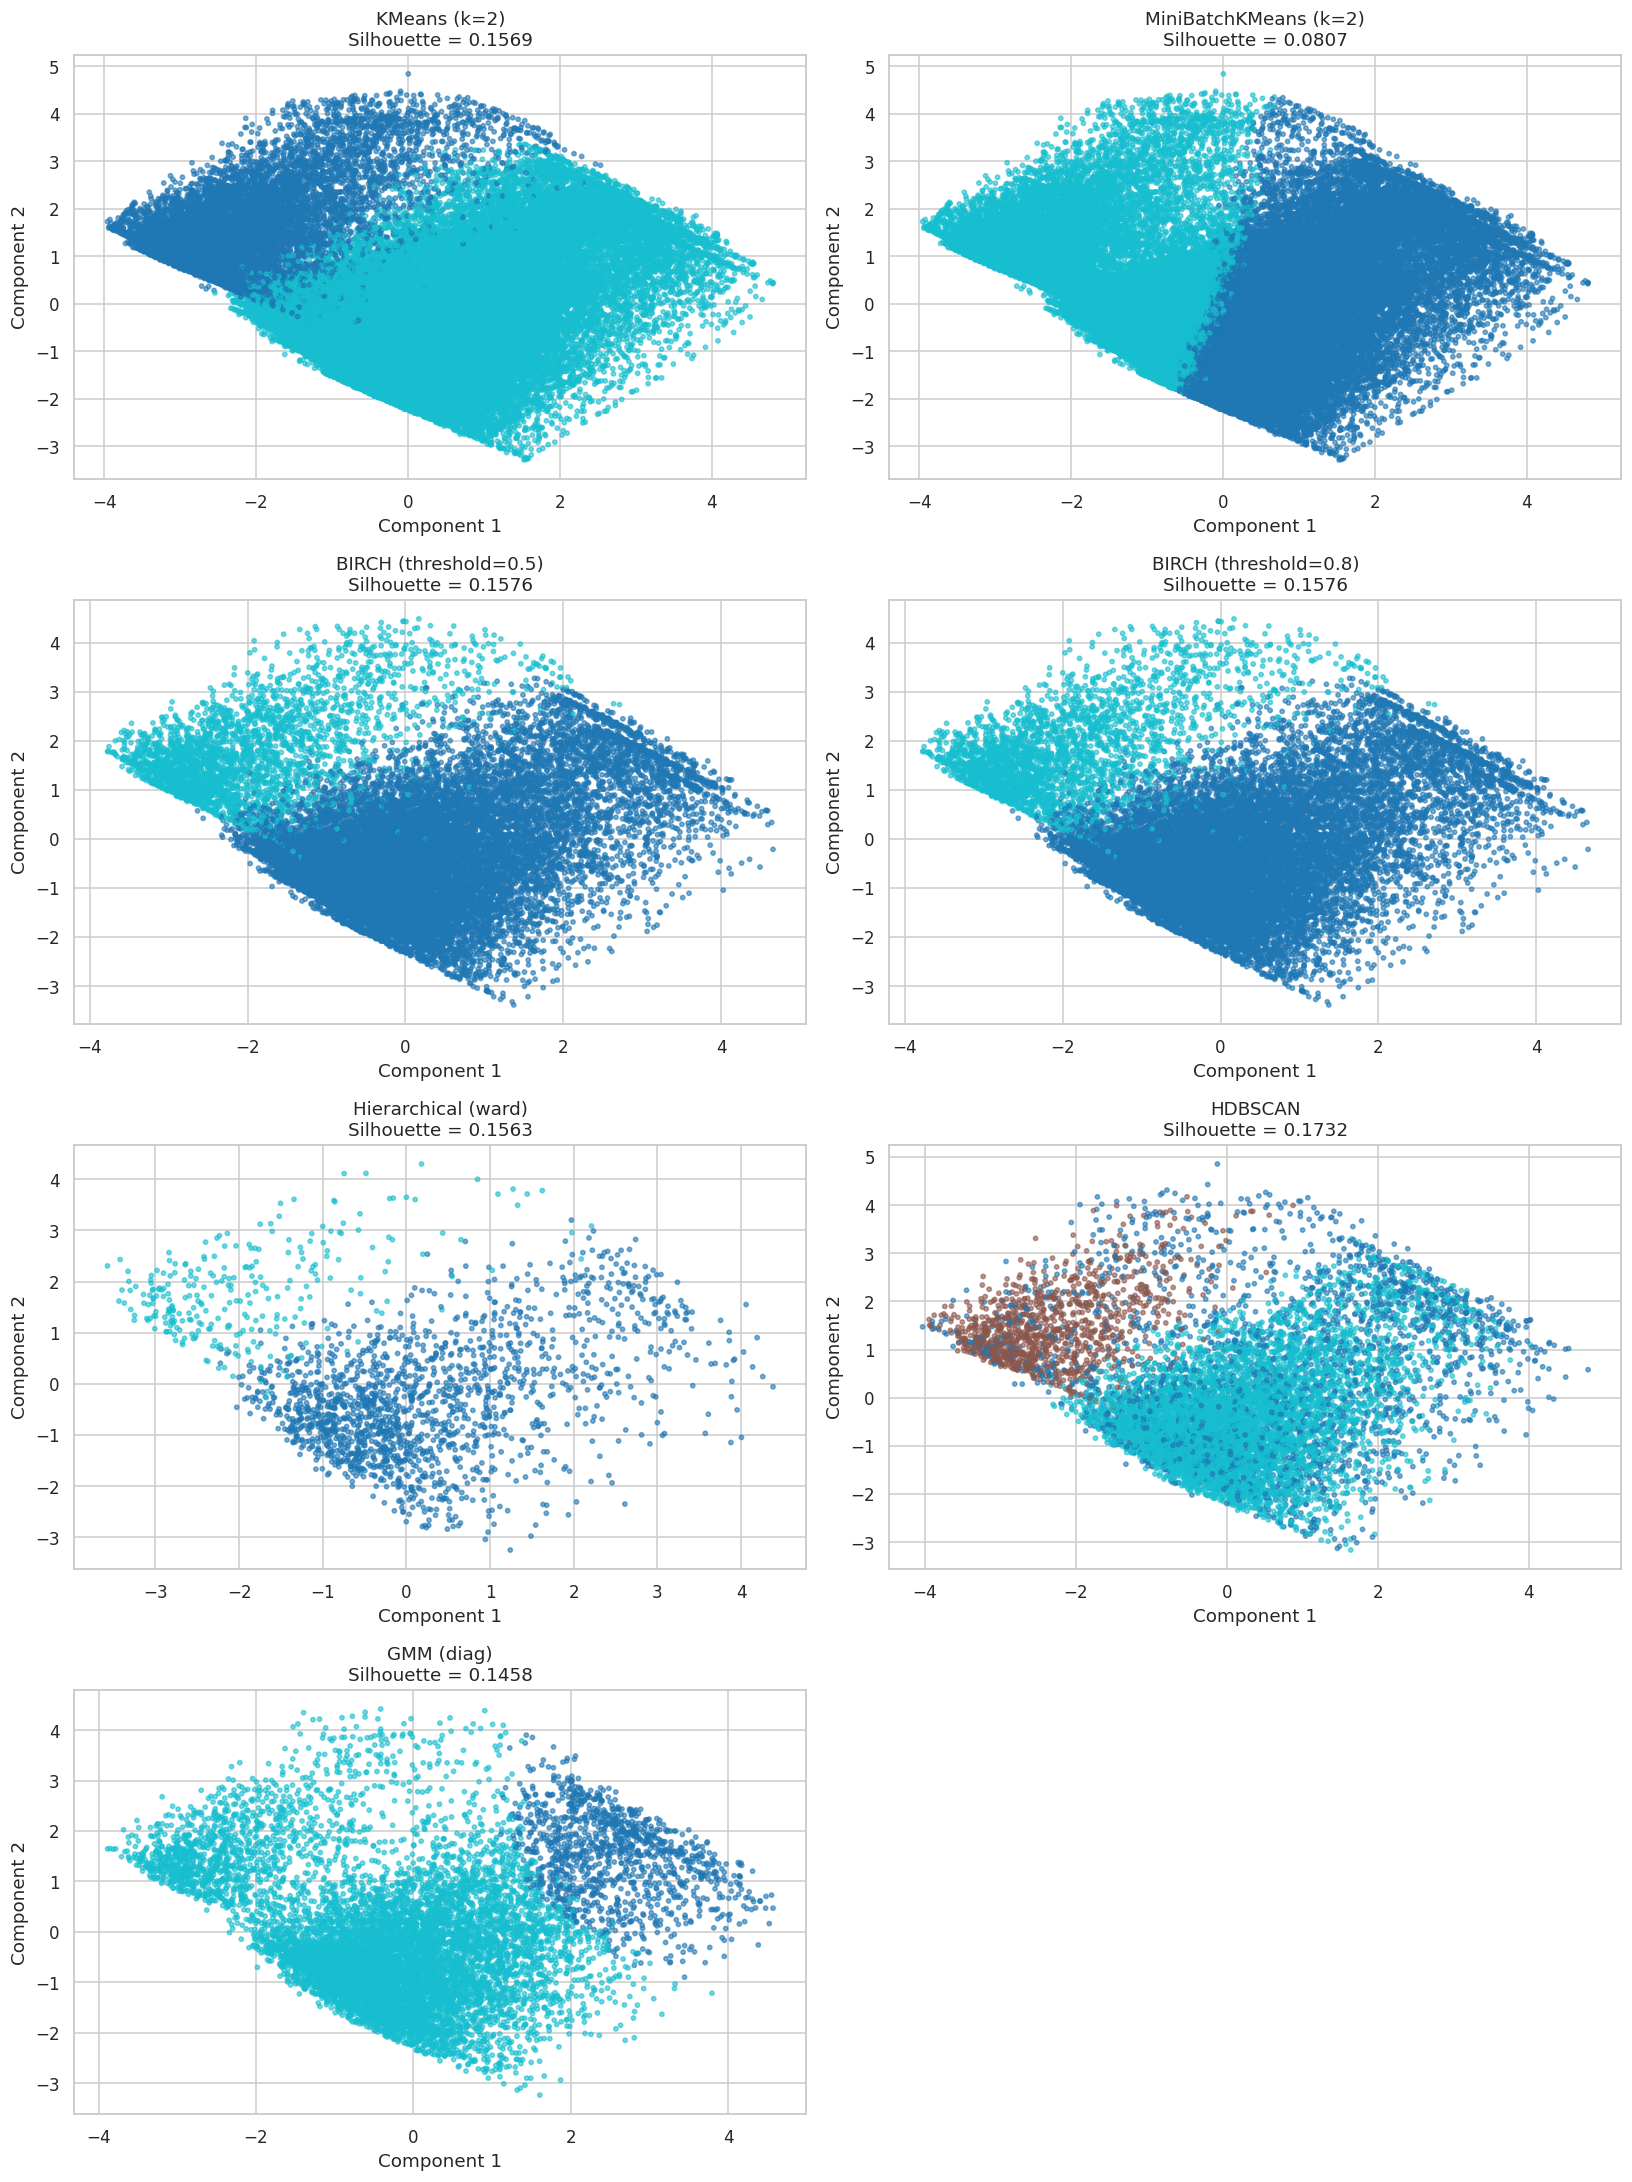


✓ Visualization completed.
✓ Each model is visualized using the exact data sample used for clustering.

⚠ Important:
KMeans / MiniBatchKMeans use the full Zp sample.
Hierarchical / DBSCAN / HDBSCAN / GMM / BIRCH use their respective samples.


In [31]:
# ============================================================
# CELL 20 : Cluster Visualization
# ============================================================

print("=" * 80)
print("⑩ CLUSTER VISUALIZATION")
print("=" * 80)


from sklearn.decomposition import PCA
import math
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Check required objects
# ============================================================

if "clu_X" not in globals():

    print(
        "❌ clu_X is not available."
    )

    print(
        "Please rerun CELL 19 first."
    )

else:

    # --------------------------------------------------------
    # Models to visualize
    # --------------------------------------------------------

    preferred_models = [

        f"KMeans (k={BEST_K})",

        f"MiniBatchKMeans (k={BEST_K})",

        "BIRCH (threshold=0.5)",

        "BIRCH (threshold=0.8)",

        "Hierarchical (ward)",

        "HDBSCAN",

        "GMM (diag)"
    ]


    viz_models = [
        name
        for name in preferred_models
        if (
            name in clu_labels
            and name in clu_X
        )
    ]


    # --------------------------------------------------------
    # Add DBSCAN if it produced >= 2 clusters
    # --------------------------------------------------------

    dbscan_models = [

        name
        for name in clu_labels

        if (
            name.startswith("DBSCAN")
            and name in clu_X
            and
            clu_table.loc[
                clu_table["Model"] == name,
                "n_clusters"
            ].iloc[0] >= 2
        )
    ]


    if dbscan_models:

        viz_models.append(
            dbscan_models[0]
        )


    # Limit number of plots
    viz_models = viz_models[:8]


    # ========================================================
    # Plot
    # ========================================================

    if not viz_models:

        print(
            "⚠ No valid clustering models available."
        )

    else:

        n = len(
            viz_models
        )


        cols = min(
            2,
            n
        )


        rows = math.ceil(
            n / cols
        )


        fig, axes = plt.subplots(
            rows,
            cols,
            figsize=(15, 5 * rows)
        )


        axes = np.atleast_1d(
            axes
        ).ravel()


        # ----------------------------------------------------
        # Plot each model
        # ----------------------------------------------------

        for i, name in enumerate(
            viz_models
        ):


            X_used = np.asarray(
                clu_X[name]
            )


            labels = np.asarray(
                clu_labels[name]
            )


            # ------------------------------------------------
            # Safety check
            # ------------------------------------------------

            if len(X_used) != len(labels):

                print(
                    f"⚠ Skipping {name}: "
                    f"X={len(X_used)}, "
                    f"labels={len(labels)}"
                )

                axes[i].axis(
                    "off"
                )

                continue


            # ------------------------------------------------
            # Convert to 2D for visualization
            # ------------------------------------------------

            if X_used.shape[1] == 2:

                X_2d = X_used

            else:

                pca_2d = PCA(
                    n_components=2,
                    random_state=RANDOM_STATE
                )


                X_2d = pca_2d.fit_transform(
                    X_used
                )


            # ------------------------------------------------
            # Get silhouette
            # ------------------------------------------------

            try:

                sil_value = (
                    clu_table
                    .loc[
                        clu_table["Model"] == name,
                        "Silhouette"
                    ]
                    .iloc[0]
                )

            except Exception:

                sil_value = np.nan


            # ------------------------------------------------
            # Plot
            # ------------------------------------------------

            axes[i].scatter(

                X_2d[:, 0],

                X_2d[:, 1],

                c=labels,

                cmap="tab10",

                s=8,

                alpha=0.6
            )


            if np.isnan(
                sil_value
            ):

                title = name

            else:

                title = (
                    f"{name}\n"
                    f"Silhouette = "
                    f"{sil_value:.4f}"
                )


            axes[i].set_title(
                title
            )


            axes[i].set_xlabel(
                "Component 1"
            )


            axes[i].set_ylabel(
                "Component 2"
            )


        # ----------------------------------------------------
        # Hide unused axes
        # ----------------------------------------------------

        for j in range(
            len(viz_models),
            len(axes)
        ):

            axes[j].axis(
                "off"
            )


        plt.tight_layout()

        plt.show()


    print(
        "\n✓ Visualization completed."
    )


    print(
        "✓ Each model is visualized using "
        "the exact data sample used for clustering."
    )


    print(
        "\n⚠ Important:"
    )


    print(
        "KMeans / MiniBatchKMeans use the full Zp sample."
    )


    print(
        "Hierarchical / DBSCAN / HDBSCAN / GMM / BIRCH "
        "use their respective samples."
    )

⑪ BUSINESS PROFILING OF CUSTOMER SEGMENTS

📊 FULL SEGMENT PROFILE


,Customers,avg_age,avg_annual_income,avg_dependents,avg_tenure,avg_senior_citizen,avg_monthlycharges,avg_totalcharges,avg_num_services,avg_has_phone_service,avg_has_internet_service,avg_has_online_security,avg_has_online_backup,Churn_Rate,Share_%,Segment_Name
Cluster,,,,,,,,,,,,,,,,
0,9055,44.659,56510.587,0.751,22.527,0.202,60.664001,1296.115967,2.573,0.600,0.001,0.000,0.000,11.31,15.09,Low-Value At-Risk
1,50945,44.738,56481.565,0.767,22.376,0.198,90.426003,1867.274048,2.562,0.801,1.000,0.397,0.501,9.65,84.91,High-Value Loyal



🏷️ BUSINESS SEGMENTS


,Segment_Name,Customers,Share_%,Churn_Rate,avg_totalcharges
Cluster,,,,,
0,Low-Value At-Risk,9055,15.09,11.31,1296.115967
1,High-Value Loyal,50945,84.91,9.65,1867.274048


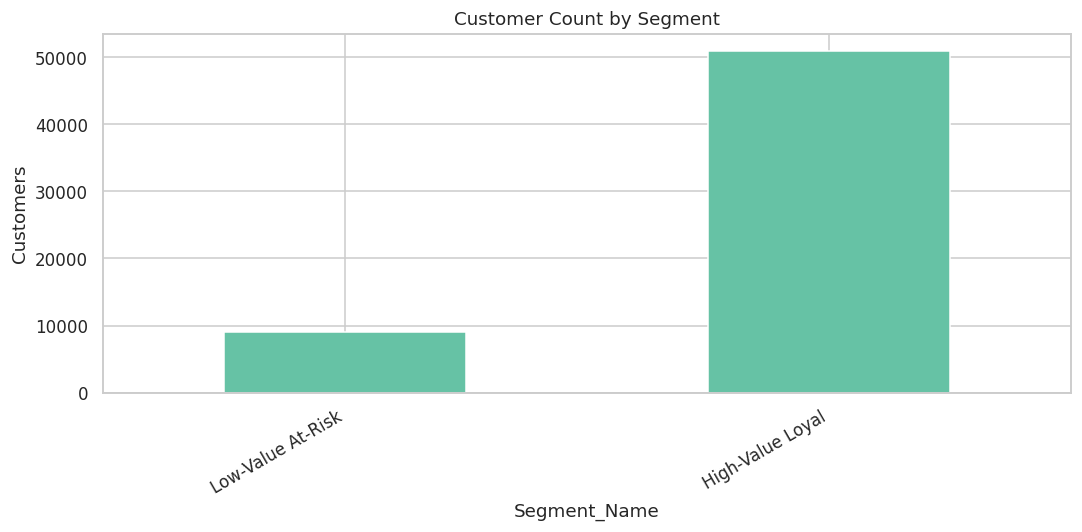

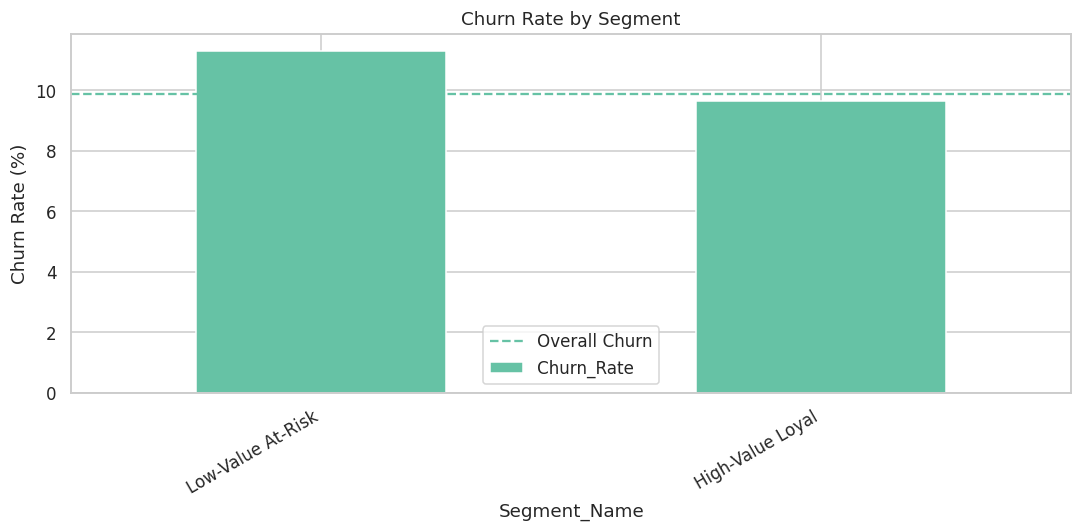

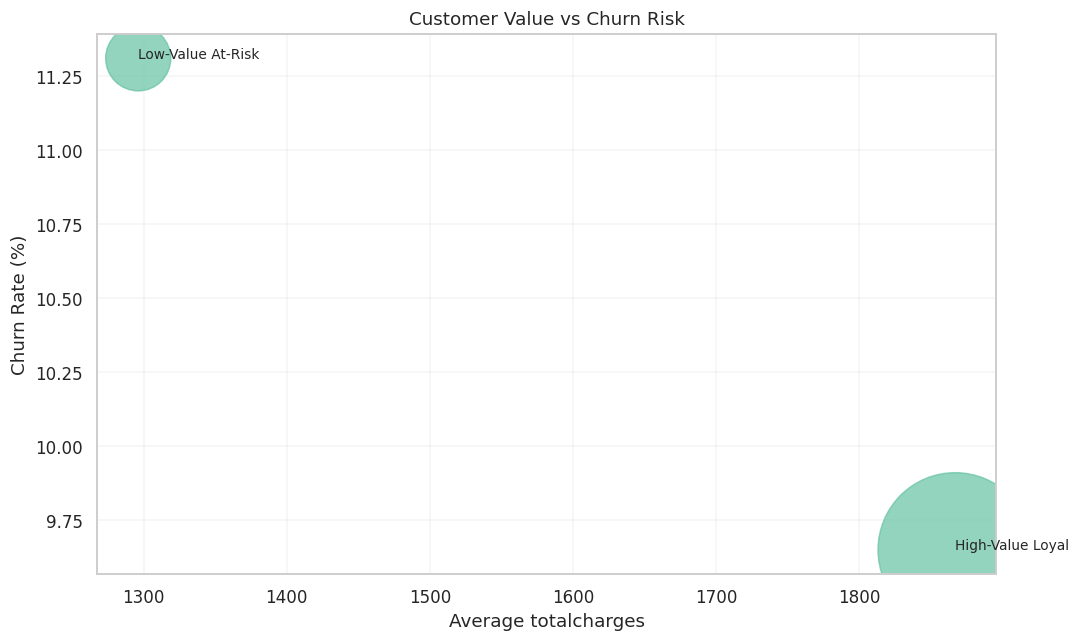

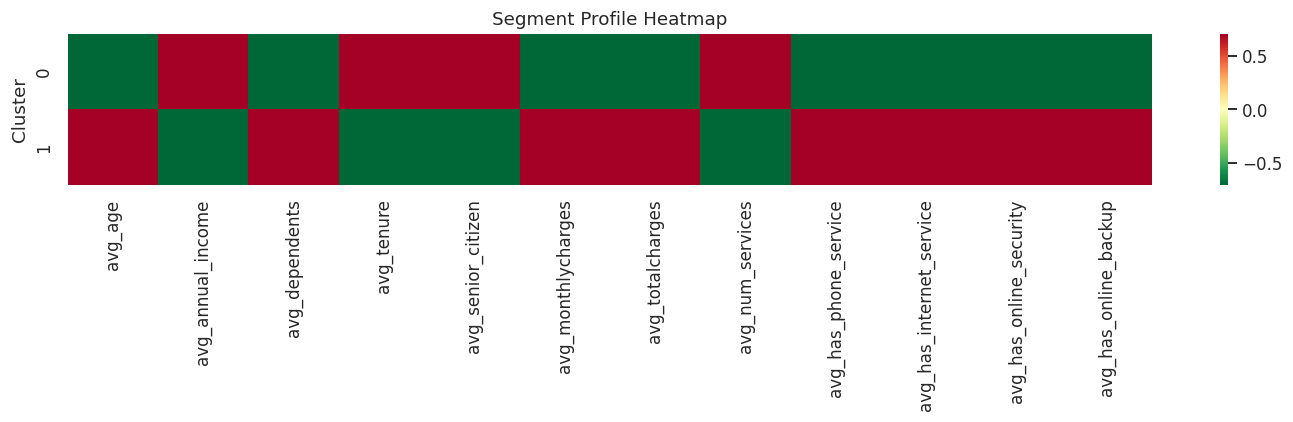


✅ Saved:
   customer_segments.csv
   segment_profiles.csv


In [32]:
# ============================================================
# CELL 21 : Business Profiling of Customer Segments
# ============================================================

print("=" * 80)
print("⑪ BUSINESS PROFILING OF CUSTOMER SEGMENTS")
print("=" * 80)


# ------------------------------------------------------------
# Use KMeans for business profiling
# ------------------------------------------------------------

BEST_CLU = (
    f"KMeans (k={BEST_K})"
)


if BEST_CLU not in clu_labels:

    raise ValueError(
        "KMeans labels were not found."
    )


seg_source = (
    seg_source
    .reset_index(drop=True)
    .copy()
)

seg_source[
    "Cluster"
] = clu_labels[
    BEST_CLU
]


# ------------------------------------------------------------
# Numerical profiling
# ------------------------------------------------------------

profile_dict = {
    "Customers": (
        "Cluster",
        "size"
    )
}

for c in seg_feats_num:

    profile_dict[
        f"avg_{c}"
    ] = (
        c,
        "mean"
    )


profile = (
    seg_source
    .groupby("Cluster")
    .agg(
        **profile_dict
    )
    .round(3)
)


# ------------------------------------------------------------
# Churn rate
# ------------------------------------------------------------

if "_CHURN_" in seg_source.columns:

    churn_by_cluster = (
        seg_source
        .groupby("Cluster")[
            "_CHURN_"
        ]
        .mean()
        * 100
    )

    profile[
        "Churn_Rate"
    ] = (
        churn_by_cluster
        .round(2)
    )

else:

    profile[
        "Churn_Rate"
    ] = np.nan


# ------------------------------------------------------------
# Segment share
# ------------------------------------------------------------

profile[
    "Share_%"
] = (
    profile["Customers"]
    / len(seg_source)
    * 100
).round(2)


# ------------------------------------------------------------
# Choose value feature
# ------------------------------------------------------------

if (
    REG_TARGET in seg_feats_num
):

    value_col = REG_TARGET

else:

    value_col = (
        seg_feats_num[0]
        if seg_feats_num
        else None
    )


# ------------------------------------------------------------
# Automatic business labels
# ------------------------------------------------------------

names = {}


if (
    value_col is not None
    and "Churn_Rate" in profile.columns
):

    value_median = profile[
        f"avg_{value_col}"
    ].median()

    churn_median = profile[
        "Churn_Rate"
    ].median()


    for cluster in profile.index:

        value = profile.loc[
            cluster,
            f"avg_{value_col}"
        ]

        churn = profile.loc[
            cluster,
            "Churn_Rate"
        ]


        high_value = (
            value >= value_median
        )

        high_churn = (
            churn >= churn_median
        )


        if high_value and high_churn:

            name = (
                "High-Value At-Risk"
            )

        elif high_value:

            name = (
                "High-Value Loyal"
            )

        elif high_churn:

            name = (
                "Low-Value At-Risk"
            )

        else:

            name = (
                "Low-Value Stable"
            )


        names[
            cluster
        ] = name


else:

    names = {
        cluster:
        f"Segment {cluster}"
        for cluster in profile.index
    }


profile[
    "Segment_Name"
] = pd.Series(
    names
)


seg_source[
    "Segment_Name"
] = seg_source[
    "Cluster"
].map(
    names
)


# ------------------------------------------------------------
# Display profile
# ------------------------------------------------------------

print(
    "\n📊 FULL SEGMENT PROFILE"
)

display(
    profile
)


print(
    "\n🏷️ BUSINESS SEGMENTS"
)

display(
    profile[
        [
            "Segment_Name",
            "Customers",
            "Share_%",
            "Churn_Rate"
        ]
        +
        (
            [f"avg_{value_col}"]
            if value_col
            else []
        )
    ]
)


# ------------------------------------------------------------
# Visualization 1: Segment size
# ------------------------------------------------------------

profile_plot = (
    profile
    .set_index(
        "Segment_Name"
    )
)


plt.figure(
    figsize=(10, 5)
)

profile_plot[
    "Customers"
].plot(
    kind="bar"
)

plt.title(
    "Customer Count by Segment"
)

plt.ylabel(
    "Customers"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Visualization 2: Churn rate
# ------------------------------------------------------------

if "Churn_Rate" in profile:

    plt.figure(
        figsize=(10, 5)
    )

    profile_plot[
        "Churn_Rate"
    ].plot(
        kind="bar"
    )

    if (
        "_CHURN_" in seg_source.columns
    ):

        overall_churn = (
            seg_source[
                "_CHURN_"
            ]
            .mean()
            * 100
        )

        plt.axhline(
            overall_churn,
            linestyle="--",
            label="Overall Churn"
        )

        plt.legend()


    plt.title(
        "Churn Rate by Segment"
    )

    plt.ylabel(
        "Churn Rate (%)"
    )

    plt.xticks(
        rotation=30,
        ha="right"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Visualization 3: Value vs Risk
# ------------------------------------------------------------

if (
    value_col is not None
    and "Churn_Rate" in profile.columns
):

    plt.figure(
        figsize=(10, 6)
    )

    plt.scatter(
        profile[
            f"avg_{value_col}"
        ],
        profile[
            "Churn_Rate"
        ],
        s=profile[
            "Customers"
        ] / 5,
        alpha=0.7
    )


    for cluster in profile.index:

        plt.annotate(
            profile.loc[
                cluster,
                "Segment_Name"
            ],
            (
                profile.loc[
                    cluster,
                    f"avg_{value_col}"
                ],
                profile.loc[
                    cluster,
                    "Churn_Rate"
                ]
            ),
            fontsize=9
        )


    plt.xlabel(
        f"Average {value_col}"
    )

    plt.ylabel(
        "Churn Rate (%)"
    )

    plt.title(
        "Customer Value vs Churn Risk"
    )

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

if len(seg_feats_num) > 1:

    heatmap_data = profile[
        [
            f"avg_{c}"
            for c in seg_feats_num
        ]
    ]

    heatmap_norm = (
        heatmap_data -
        heatmap_data.mean()
    ) / heatmap_data.std()

    plt.figure(
        figsize=(
            max(10, 1.1 * len(seg_feats_num)),
            max(4, 0.7 * len(profile))
        )
    )

    sns.heatmap(
        heatmap_norm,
        annot=False,
        cmap="RdYlGn_r",
        center=0
    )

    plt.title(
        "Segment Profile Heatmap"
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

seg_source[
    [
        "Cluster",
        "Segment_Name"
    ]
    +
    (
        ["_CHURN_"]
        if "_CHURN_" in seg_source.columns
        else []
    )
].to_csv(
    "customer_segments.csv",
    index=False
)


profile.to_csv(
    "segment_profiles.csv"
)


print(
    "\n✅ Saved:"
)

print(
    "   customer_segments.csv"
)

print(
    "   segment_profiles.csv"
)

⑫ FAST FINAL VALIDATION + THRESHOLD SELECTION

Data split:
Training:   192,000
Validation: 48,000
Test:       60,000 (untouched)

Model-selection training sample: 100,000

FAST VALIDATION COMPARISON
✔ Extra Trees               F1=0.2523 | Recall=0.5284 | PR-AUC=0.1894 | Time=4.8s
✔ HistGradientBoosting      F1=0.2517 | Recall=0.6003 | PR-AUC=0.1947 | Time=2.4s
✔ LightGBM                  F1=0.2527 | Recall=0.5677 | PR-AUC=0.1913 | Time=2.6s

📊 VALIDATION RESULTS


,Model,F1,Recall,Precision,ROC_AUC,PR_AUC,Time_s
0,LightGBM,0.252675,0.567709,0.162500,0.670692,0.191346,2.635450
1,Extra Trees,0.252318,0.528448,0.165723,0.672517,0.189391,4.821218
2,HistGradientBoosting,0.251661,0.600252,0.159205,0.675702,0.194697,2.357706



✅ Selected model:
   LightGBM

⏳ Running lightweight 3-fold CV...

3-Fold CV:
F1:     0.2467 +/- 0.0024
PR-AUC: 0.1779 +/- 0.0037
ROC-AUC:0.6572 +/- 0.0048

VALIDATION THRESHOLD
Selected threshold: 0.57
Validation F1:      0.2552
Validation Recall:  0.4067
Validation Precision: 0.1860


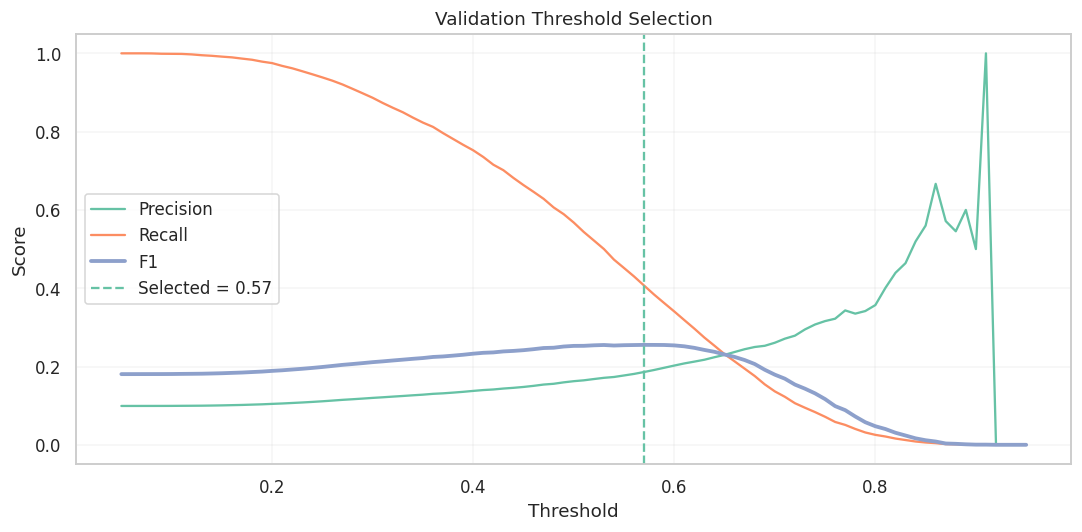


✅ CELL 22 COMPLETED
Selected model : LightGBM
Threshold      : 0.57
Test set       : NOT USED

Next:
Cell 23 will retrain the selected model on ALL Xc_tr / yc_tr and evaluate ONCE on Xc_te.


In [34]:
# ============================================================
# CELL 22 : FAST FINAL VALIDATION + THRESHOLD SELECTION
# ============================================================

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.base import clone

print("=" * 85)
print("⑫ FAST FINAL VALIDATION + THRESHOLD SELECTION")
print("=" * 85)


# ============================================================
# 1. Train / Validation Split
# ============================================================

X_train_model, X_val, y_train_model, y_val = train_test_split(

    Xc_tr,

    yc_tr,

    test_size=0.20,

    stratify=yc_tr,

    random_state=RANDOM_STATE
)


print("\nData split:")

print(
    f"Training:   {len(X_train_model):,}"
)

print(
    f"Validation: {len(X_val):,}"
)

print(
    f"Test:       {len(Xc_te):,} (untouched)"
)


# ============================================================
# 2. Smaller training sample
# ============================================================

VALIDATION_TRAIN_SIZE = min(
    100_000,
    len(X_train_model)
)


X_val_train, y_val_train = subsample(

    X_train_model,

    y_train_model,

    VALIDATION_TRAIN_SIZE,

    stratify=y_train_model
)


print(
    f"\nModel-selection training sample: "
    f"{len(X_val_train):,}"
)


# ============================================================
# 3. Fast Candidate Models
# ============================================================

candidate_models = {}


# ------------------------------------------------------------
# Extra Trees
# ------------------------------------------------------------

candidate_models["Extra Trees"] = Pipeline([

    (
        "prep",
        clone(prep_tree_c)
    ),

    (
        "model",

        ExtraTreesClassifier(

            n_estimators=120,

            max_depth=15,

            min_samples_leaf=20,

            class_weight="balanced",

            n_jobs=-1,

            random_state=RANDOM_STATE
        )
    )
])


# ------------------------------------------------------------
# HistGradientBoosting
# ------------------------------------------------------------

candidate_models["HistGradientBoosting"] = Pipeline([

    (
        "prep",
        clone(prep_tree_c)
    ),

    (
        "model",

        HistGradientBoostingClassifier(

            max_iter=150,

            learning_rate=0.08,

            max_leaf_nodes=31,

            min_samples_leaf=50,

            class_weight="balanced",

            early_stopping=True,

            random_state=RANDOM_STATE
        )
    )
])


# ------------------------------------------------------------
# LightGBM
# ------------------------------------------------------------

if HAS_LGB:

    candidate_models["LightGBM"] = Pipeline([

        (
            "prep",
            clone(prep_tree_c)
        ),

        (
            "model",

            lgb.LGBMClassifier(

                n_estimators=250,

                learning_rate=0.06,

                num_leaves=31,

                class_weight="balanced",

                n_jobs=-1,

                random_state=RANDOM_STATE,

                verbose=-1
            )
        )
    ])


# ============================================================
# 4. Fast Validation Comparison
# ============================================================

validation_results = []

validation_fitted = {}


print(
    "\n" + "=" * 85
)

print(
    "FAST VALIDATION COMPARISON"
)

print(
    "=" * 85
)


for name, pipe in candidate_models.items():

    t0 = time.time()

    try:

        # -----------------------------------------------
        # Fit
        # -----------------------------------------------

        pipe.fit(
            X_val_train,
            y_val_train
        )


        # -----------------------------------------------
        # Probability
        # -----------------------------------------------

        proba = pipe.predict_proba(
            X_val
        )[:, 1]


        # Default threshold
        pred = (
            proba >= 0.50
        ).astype(int)


        # -----------------------------------------------
        # Metrics
        # -----------------------------------------------

        row = {

            "Model":
                name,

            "F1":
                f1_score(
                    y_val,
                    pred,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_val,
                    pred,
                    zero_division=0
                ),

            "Precision":
                precision_score(
                    y_val,
                    pred,
                    zero_division=0
                ),

            "ROC_AUC":
                roc_auc_score(
                    y_val,
                    proba
                ),

            "PR_AUC":
                average_precision_score(
                    y_val,
                    proba
                ),

            "Time_s":
                time.time() - t0
        }


        validation_results.append(
            row
        )


        validation_fitted[
            name
        ] = pipe


        print(

            f"✔ {name:<25} "

            f"F1={row['F1']:.4f} | "

            f"Recall={row['Recall']:.4f} | "

            f"PR-AUC={row['PR_AUC']:.4f} | "

            f"Time={row['Time_s']:.1f}s"
        )


    except Exception as e:

        print(

            f"✘ {name}: "

            f"{type(e).__name__} -> {e}"
        )


# ============================================================
# 5. Validation Table
# ============================================================

validation_table = (

    pd.DataFrame(
        validation_results
    )

    .sort_values(
        "F1",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print(
    "\n📊 VALIDATION RESULTS"
)


display(
    validation_table
)


if validation_table.empty:

    raise RuntimeError(
        "No model completed validation."
    )


# ============================================================
# 6. Select Model
# ============================================================

SELECTED_BASELINE = (

    validation_table
    .iloc[0]["Model"]
)


tuned_model = validation_fitted[
    SELECTED_BASELINE
]


print(
    "\n✅ Selected model:"
)

print(
    f"   {SELECTED_BASELINE}"
)


# ============================================================
# 7. 3-Fold CV Stability Check
# ============================================================

print(
    "\n⏳ Running lightweight 3-fold CV..."
)


# Use an even smaller sample for CV
CV_SIZE = min(
    50_000,
    len(X_val_train)
)


X_cv, y_cv = subsample(

    X_val_train,

    y_val_train,

    CV_SIZE,

    stratify=y_val_train
)


cv_strategy = StratifiedKFold(

    n_splits=3,

    shuffle=True,

    random_state=RANDOM_STATE
)


cv_results = cross_validate(

    clone(tuned_model),

    X_cv,

    y_cv,

    cv=cv_strategy,

    scoring={
        "F1": "f1",
        "PR_AUC": "average_precision",
        "ROC_AUC": "roc_auc"
    },

    n_jobs=1,

    return_train_score=False
)


print(
    "\n3-Fold CV:"
)

print(
    f"F1:     "
    f"{cv_results['test_F1'].mean():.4f} "
    f"+/- "
    f"{cv_results['test_F1'].std():.4f}"
)

print(
    f"PR-AUC: "
    f"{cv_results['test_PR_AUC'].mean():.4f} "
    f"+/- "
    f"{cv_results['test_PR_AUC'].std():.4f}"
)

print(
    f"ROC-AUC:"
    f"{cv_results['test_ROC_AUC'].mean():.4f} "
    f"+/- "
    f"{cv_results['test_ROC_AUC'].std():.4f}"
)


# ============================================================
# 8. Threshold Selection — VALIDATION ONLY
# ============================================================

val_proba = tuned_model.predict_proba(
    X_val
)[:, 1]


thresholds = np.arange(
    0.05,
    0.96,
    0.01
)


threshold_rows = []


for threshold in thresholds:

    pred = (
        val_proba >= threshold
    ).astype(int)


    threshold_rows.append({

        "Threshold":
            round(
                float(threshold),
                2
            ),

        "Precision":
            precision_score(
                y_val,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_val,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_val,
                pred,
                zero_division=0
            )
    })


threshold_val_table = pd.DataFrame(
    threshold_rows
)


# ============================================================
# 9. Best F1 Threshold
# ============================================================

best_f1_row = (

    threshold_val_table

    .loc[
        threshold_val_table["F1"].idxmax()
    ]
)


FINAL_THRESHOLD = float(
    best_f1_row["Threshold"]
)


print(
    "\n" + "=" * 85
)

print(
    "VALIDATION THRESHOLD"
)

print(
    "=" * 85
)

print(
    f"Selected threshold: "
    f"{FINAL_THRESHOLD:.2f}"
)

print(
    f"Validation F1:      "
    f"{best_f1_row['F1']:.4f}"
)

print(
    f"Validation Recall:  "
    f"{best_f1_row['Recall']:.4f}"
)

print(
    f"Validation Precision:"
    f" {best_f1_row['Precision']:.4f}"
)


# ============================================================
# 10. Threshold Plot
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    threshold_val_table["Threshold"],
    threshold_val_table["Precision"],
    label="Precision"
)


plt.plot(
    threshold_val_table["Threshold"],
    threshold_val_table["Recall"],
    label="Recall"
)


plt.plot(
    threshold_val_table["Threshold"],
    threshold_val_table["F1"],
    label="F1",
    linewidth=2.5
)


plt.axvline(
    FINAL_THRESHOLD,
    linestyle="--",
    label=f"Selected = {FINAL_THRESHOLD:.2f}"
)


plt.xlabel(
    "Threshold"
)

plt.ylabel(
    "Score"
)

plt.title(
    "Validation Threshold Selection"
)

plt.legend()

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. Save Validation Results
# ============================================================

validation_table.to_csv(
    "validation_model_comparison.csv",
    index=False
)


threshold_val_table.to_csv(
    "validation_threshold_analysis.csv",
    index=False
)


# ============================================================
# 12. Final Variables for Cell 23
# ============================================================

BEST_CLF_NAME = SELECTED_BASELINE


FINAL_CLF_TEMPLATE = clone(
    tuned_model
)


print(
    "\n" + "=" * 85
)

print(
    "✅ CELL 22 COMPLETED"
)

print(
    "=" * 85
)

print(
    f"Selected model : {BEST_CLF_NAME}"
)

print(
    f"Threshold      : {FINAL_THRESHOLD:.2f}"
)

print(
    "Test set       : NOT USED"
)

print(
    "\nNext:"
)

print(
    "Cell 23 will retrain the selected model "
    "on ALL Xc_tr / yc_tr and evaluate ONCE on Xc_te."
)

⑬ FINAL MODEL TRAINING + UNTOUCHED TEST EVALUATION

Final model: LightGBM
Final threshold: 0.57

⏳ Preparing validation metrics...
✔ Validation metrics prepared

⏳ Retraining final model on ALL training data...
✔ Training completed in 5.2s

⏳ Evaluating on untouched test set...

🏆 FINAL TEST RESULTS

Default threshold = 0.50
Accuracy              : 0.6479
Balanced_Accuracy     : 0.6312
Precision             : 0.1620
Recall                : 0.6103
F1                    : 0.2560
ROC_AUC               : 0.6816
PR_AUC                : 0.1987
MCC                   : 0.1621
LogLoss               : 0.6182

Selected validation threshold = 0.57
Accuracy              : 0.7587
Balanced_Accuracy     : 0.6191
Precision             : 0.1916
Recall                : 0.4449
F1                    : 0.2679
ROC_AUC               : 0.6816
PR_AUC                : 0.1987
MCC                   : 0.1691
LogLoss               : 0.6182

Confusion Matrix @ selected threshold:
TN = 42,872
FP = 11,174
FN = 3,305
TP

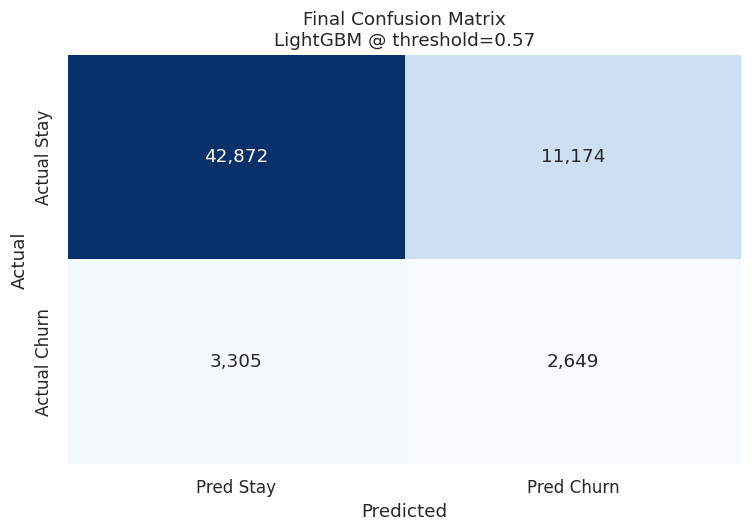


Classification Report:
              precision    recall  f1-score   support

        Stay     0.9284    0.7933    0.8555     54046
       Churn     0.1916    0.4449    0.2679      5954

    accuracy                         0.7587     60000
   macro avg     0.5600    0.6191    0.5617     60000
weighted avg     0.8553    0.7587    0.7972     60000


✅ Saved:
   best_classification_model.pkl
   segmentation_model.pkl
   best_regression_model.pkl
   validation_model_comparison.csv
   validation_threshold_analysis.csv
   clustering_comparison.csv
   customer_segments.csv
   segment_profiles.csv
   project_summary.json

📋 FINAL EXECUTIVE SUMMARY

📁 Dataset:
   1,000,000 rows × 31 columns
   Churn rate = 9.92%

1️⃣ CLASSIFICATION
   Model     = LightGBM
   Threshold = 0.57

   Test F1        = 0.2679
   Test Recall    = 0.4449
   Test Precision = 0.1916
   Test ROC-AUC   = 0.6816
   Test PR-AUC    = 0.1987

2️⃣ CLUSTERING
   Profiling model = KMeans (k=2)
   k = 2

3️⃣ IMPORTANT METHODOLOGY

In [36]:
# ============================================================
# CELL 23 : FINAL MODEL + UNTOUCHED TEST EVALUATION
# ============================================================

import joblib
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    log_loss,
    confusion_matrix,
    classification_report
)

print("=" * 85)
print("⑬ FINAL MODEL TRAINING + UNTOUCHED TEST EVALUATION")
print("=" * 85)


# ============================================================
# 1. Final model configuration
# ============================================================

FINAL_MODEL_NAME = SELECTED_BASELINE

print(f"\nFinal model: {FINAL_MODEL_NAME}")
print(f"Final threshold: {FINAL_THRESHOLD:.2f}")


# ============================================================
# 2. Recreate validation predictions
#    Used ONLY for the project summary
# ============================================================

print("\n⏳ Preparing validation metrics...")

# Use the validation model selected in CELL 22
validation_model = clone(FINAL_CLF_TEMPLATE)

validation_model.fit(
    X_train_model,
    y_train_model
)

val_proba = validation_model.predict_proba(
    X_val
)[:, 1]

final_val_pred = (
    val_proba >= FINAL_THRESHOLD
).astype(int)

validation_metrics_final = {
    "Accuracy": accuracy_score(
        y_val,
        final_val_pred
    ),

    "Balanced_Accuracy": balanced_accuracy_score(
        y_val,
        final_val_pred
    ),

    "Precision": precision_score(
        y_val,
        final_val_pred,
        zero_division=0
    ),

    "Recall": recall_score(
        y_val,
        final_val_pred,
        zero_division=0
    ),

    "F1": f1_score(
        y_val,
        final_val_pred,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        y_val,
        val_proba
    ),

    "PR_AUC": average_precision_score(
        y_val,
        val_proba
    )
}

print("✔ Validation metrics prepared")


# ============================================================
# 3. Final model
#    Retrain on ALL training data
# ============================================================

print(
    "\n⏳ Retraining final model on ALL training data..."
)

final_model = clone(
    FINAL_CLF_TEMPLATE
)

t0 = time.time()

final_model.fit(
    Xc_tr,
    yc_tr
)

print(
    f"✔ Training completed in "
    f"{time.time() - t0:.1f}s"
)


# ============================================================
# 4. Evaluate ONCE on untouched test set
# ============================================================

print(
    "\n⏳ Evaluating on untouched test set..."
)

test_proba = (
    final_model
    .predict_proba(
        Xc_te
    )[:, 1]
)


# Default threshold
test_pred_050 = (
    test_proba >= 0.50
).astype(int)


# Validation-selected threshold
test_pred_final = (
    test_proba >= FINAL_THRESHOLD
).astype(int)


# ============================================================
# 5. Final metrics @ 0.50
# ============================================================

test_metrics_050 = {

    "Accuracy": accuracy_score(
        yc_te,
        test_pred_050
    ),

    "Balanced_Accuracy": balanced_accuracy_score(
        yc_te,
        test_pred_050
    ),

    "Precision": precision_score(
        yc_te,
        test_pred_050,
        zero_division=0
    ),

    "Recall": recall_score(
        yc_te,
        test_pred_050,
        zero_division=0
    ),

    "F1": f1_score(
        yc_te,
        test_pred_050,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        yc_te,
        test_proba
    ),

    "PR_AUC": average_precision_score(
        yc_te,
        test_proba
    ),

    "MCC": matthews_corrcoef(
        yc_te,
        test_pred_050
    ),

    "LogLoss": log_loss(
        yc_te,
        np.clip(
            test_proba,
            1e-6,
            1 - 1e-6
        )
    )
}


# ============================================================
# 6. Final metrics @ selected threshold
# ============================================================

test_metrics_final = {

    "Accuracy": accuracy_score(
        yc_te,
        test_pred_final
    ),

    "Balanced_Accuracy": balanced_accuracy_score(
        yc_te,
        test_pred_final
    ),

    "Precision": precision_score(
        yc_te,
        test_pred_final,
        zero_division=0
    ),

    "Recall": recall_score(
        yc_te,
        test_pred_final,
        zero_division=0
    ),

    "F1": f1_score(
        yc_te,
        test_pred_final,
        zero_division=0
    ),

    "ROC_AUC": roc_auc_score(
        yc_te,
        test_proba
    ),

    "PR_AUC": average_precision_score(
        yc_te,
        test_proba
    ),

    "MCC": matthews_corrcoef(
        yc_te,
        test_pred_final
    ),

    "LogLoss": log_loss(
        yc_te,
        np.clip(
            test_proba,
            1e-6,
            1 - 1e-6
        )
    )
}


# ============================================================
# 7. Display final results
# ============================================================

print("\n" + "=" * 85)
print("🏆 FINAL TEST RESULTS")
print("=" * 85)

print("\nDefault threshold = 0.50")

for metric, value in test_metrics_050.items():
    print(
        f"{metric:<22}: {value:.4f}"
    )


print(
    f"\nSelected validation threshold = "
    f"{FINAL_THRESHOLD:.2f}"
)

for metric, value in test_metrics_final.items():
    print(
        f"{metric:<22}: {value:.4f}"
    )


# ============================================================
# 8. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    yc_te,
    test_pred_final
)

tn, fp, fn, tp = cm.ravel()

print(
    "\nConfusion Matrix @ selected threshold:"
)

print(f"TN = {tn:,}")
print(f"FP = {fp:,}")
print(f"FN = {fn:,}")
print(f"TP = {tp:,}")


plt.figure(
    figsize=(7, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Pred Stay",
        "Pred Churn"
    ],
    yticklabels=[
        "Actual Stay",
        "Actual Churn"
    ]
)

plt.title(
    f"Final Confusion Matrix\n"
    f"{FINAL_MODEL_NAME} @ threshold={FINAL_THRESHOLD:.2f}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# ============================================================
# 9. Classification report
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        yc_te,
        test_pred_final,
        target_names=[
            "Stay",
            "Churn"
        ],
        digits=4
    )
)


# ============================================================
# 10. Save final classification model
# ============================================================

joblib.dump(
    final_model,
    "best_classification_model.pkl"
)

print("\n✅ Saved:")
print("   best_classification_model.pkl")


# ============================================================
# 11. Save segmentation model
# ============================================================

joblib.dump(
    {
        "prep": seg_prep,
        "pca": pca_model,
        "kmeans": km,
        "segment_names": names,
        "features": (
            seg_feats_num +
            seg_feats_cat
        ),
        "best_k": BEST_K
    },
    "segmentation_model.pkl"
)

print("   segmentation_model.pkl")


# ============================================================
# 12. Save regression model
# ============================================================

if (
    "reg_fitted" in globals()
    and "best_reg_name" in globals()
):

    joblib.dump(
        reg_fitted[
            best_reg_name
        ],
        "best_regression_model.pkl"
    )

    print(
        "   best_regression_model.pkl"
    )


# ============================================================
# 13. Save validation model comparison
# ============================================================

if "validation_results" in globals():

    validation_model_table = pd.DataFrame(
        validation_results
    )

    validation_model_table.to_csv(
        "validation_model_comparison.csv",
        index=False
    )

    print(
        "   validation_model_comparison.csv"
    )


# ============================================================
# 14. Save threshold analysis
# ============================================================

if "threshold_val_table" in globals():

    threshold_val_table.to_csv(
        "validation_threshold_analysis.csv",
        index=False
    )

    print(
        "   validation_threshold_analysis.csv"
    )


# ============================================================
# 15. Save clustering comparison
# ============================================================

if "clu_table" in globals():

    clu_table.to_csv(
        "clustering_comparison.csv",
        index=False
    )

    print(
        "   clustering_comparison.csv"
    )


# ============================================================
# 16. Save customer segments
# ============================================================

if (
    "seg_source" in globals()
    and "BEST_CLU" in globals()
    and BEST_CLU in clu_labels
):

    customer_segments = seg_source.copy()

    customer_segments["Cluster"] = (
        clu_labels[BEST_CLU]
    )

    customer_segments.to_csv(
        "customer_segments.csv",
        index=False
    )

    print(
        "   customer_segments.csv"
    )


# ============================================================
# 17. Save segment profiles
# ============================================================

if (
    "seg_source" in globals()
    and "BEST_CLU" in globals()
    and BEST_CLU in clu_labels
):

    profile_data = seg_source.copy()

    profile_data["Cluster"] = (
        clu_labels[BEST_CLU]
    )

    profile_numeric = (
        profile_data
        .select_dtypes(
            include=np.number
        )
        .columns
        .tolist()
    )

    profile_numeric = [
        c for c in profile_numeric
        if c != "Cluster"
    ]

    segment_profiles = (
        profile_data
        .groupby("Cluster")[profile_numeric]
        .mean()
        .reset_index()
    )

    segment_profiles["Customer_Count"] = (
        profile_data
        .groupby("Cluster")
        .size()
        .values
    )

    segment_profiles.to_csv(
        "segment_profiles.csv",
        index=False
    )

    print(
        "   segment_profiles.csv"
    )


# ============================================================
# 18. Final project summary
# ============================================================

summary = {

    "dataset": {

        "rows_total": int(
            len(work)
        ),

        "columns_total": int(
            work.shape[1]
        ),

        "churn_rate": round(
            float(churn_rate),
            4
        )
    },


    "classification": {

        "model": FINAL_MODEL_NAME,

        "threshold": float(
            FINAL_THRESHOLD
        ),

        "validation": {
            k: float(v)
            for k, v
            in validation_metrics_final.items()
        },

        "test": {
            k: float(v)
            for k, v
            in test_metrics_final.items()
        }
    },


    "clustering": {

        "profiling_model": (
            BEST_CLU
            if "BEST_CLU" in globals()
            else None
        ),

        "k": int(
            BEST_K
        )
        if "BEST_K" in globals()
        else None,

        "best_silhouette_benchmark": (
            float(
                clu_table.iloc[0]["Silhouette"]
            )
            if (
                "clu_table" in globals()
                and not clu_table.empty
                and "Silhouette" in clu_table.columns
                and not pd.isna(
                    clu_table.iloc[0]["Silhouette"]
                )
            )
            else None
        )
    }
}


# ============================================================
# 19. Add regression summary if available
# ============================================================

if (
    "reg_table" in globals()
    and "best_reg_name" in globals()
):

    # Find selected regression model row
    reg_selected = reg_table[
        reg_table["Model"] == best_reg_name
    ]

    if not reg_selected.empty:

        reg_row = reg_selected.iloc[0]

        summary["regression"] = {

            "model": best_reg_name,

            "R2": float(
                reg_row["R2"]
            ),

            "RMSE": float(
                reg_row["RMSE"]
            ),

            "MAE": float(
                reg_row["MAE"]
            )
        }


# ============================================================
# 20. Save project summary
# ============================================================

with open(
    "project_summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )

print(
    "   project_summary.json"
)


# ============================================================
# 21. Final executive summary
# ============================================================

print(
    "\n" + "=" * 85
)

print(
    "📋 FINAL EXECUTIVE SUMMARY"
)

print(
    "=" * 85
)

print(
    f"""
📁 Dataset:
   {len(work):,} rows × {work.shape[1]} columns
   Churn rate = {churn_rate:.2%}

1️⃣ CLASSIFICATION
   Model     = {FINAL_MODEL_NAME}
   Threshold = {FINAL_THRESHOLD:.2f}

   Test F1        = {test_metrics_final['F1']:.4f}
   Test Recall    = {test_metrics_final['Recall']:.4f}
   Test Precision = {test_metrics_final['Precision']:.4f}
   Test ROC-AUC   = {test_metrics_final['ROC_AUC']:.4f}
   Test PR-AUC    = {test_metrics_final['PR_AUC']:.4f}

2️⃣ CLUSTERING
   Profiling model = {
       BEST_CLU
       if "BEST_CLU" in globals()
       else "KMeans"
   }
   k = {
       BEST_K
       if "BEST_K" in globals()
       else "N/A"
   }

3️⃣ IMPORTANT METHODOLOGY
   ✓ Model selection was performed using validation data.
   ✓ Threshold selection was performed using validation data.
   ✓ Final model was retrained on the complete training set.
   ✓ Test set was kept untouched until final evaluation.
"""
)

print("=" * 85)

print("\n📦 Final files:")

print("   best_classification_model.pkl")
print("   segmentation_model.pkl")

if (
    "reg_fitted" in globals()
    and "best_reg_name" in globals()
):
    print("   best_regression_model.pkl")

print("   project_summary.json")

if "validation_results" in globals():
    print("   validation_model_comparison.csv")

if "threshold_val_table" in globals():
    print("   validation_threshold_analysis.csv")

if "clu_table" in globals():
    print("   clustering_comparison.csv")

if (
    "seg_source" in globals()
    and "BEST_CLU" in globals()
):
    print("   customer_segments.csv")
    print("   segment_profiles.csv")


print(
    "\n✅ CELL 23 COMPLETED — FINAL TEST EVALUATION DONE."
)

In [37]:
# ============================================================
# CELL 24A : INTERACTIVE GUI - GRADIO
# ============================================================

import joblib
import pandas as pd
import numpy as np

print("=" * 85)
print("⑭ CUSTOMER CHURN GUI — GRADIO")
print("=" * 85)


# ============================================================
# 1. Load final model
# ============================================================

MODEL_PATH = "best_classification_model.pkl"
FINAL_THRESHOLD_GUI = 0.57

gui_model = joblib.load(MODEL_PATH)

print(f"\n✔ Model loaded: {MODEL_PATH}")
print(f"✔ Decision threshold: {FINAL_THRESHOLD_GUI}")


# ============================================================
# 2. Get original feature names
# ============================================================

GUI_FEATURES = Xc_tr.columns.tolist()

print(
    f"✔ Number of input features: "
    f"{len(GUI_FEATURES)}"
)

print("\nFeatures:")
for i, col in enumerate(GUI_FEATURES, 1):
    print(f"{i:>2}. {col}")


# ============================================================
# 3. Prediction function
# ============================================================

def predict_churn(*values):

    input_data = pd.DataFrame(
        [values],
        columns=GUI_FEATURES
    )

    probability = float(
        gui_model.predict_proba(
            input_data
        )[0, 1]
    )

    prediction = (
        probability >= FINAL_THRESHOLD_GUI
    )

    if prediction:
        result = "⚠️ HIGH CHURN RISK"
        status = "Customer is predicted to churn."
    else:
        result = "✅ LOW CHURN RISK"
        status = "Customer is predicted to stay."

    return (
        result,
        status,
        f"{probability:.2%}"
    )


# ============================================================
# 4. Build Gradio inputs
# ============================================================

try:
    import gradio as gr

    inputs = []

    for col in GUI_FEATURES:

        dtype = Xc_tr[col].dtype

        # Numeric feature
        if pd.api.types.is_numeric_dtype(dtype):

            median_value = float(
                Xc_tr[col].median()
            )

            inputs.append(
                gr.Number(
                    label=col,
                    value=median_value
                )
            )

        # Categorical / text feature
        else:

            values = (
                Xc_tr[col]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )

            values = sorted(values)[:100]

            if len(values) > 0:

                inputs.append(
                    gr.Dropdown(
                        choices=values,
                        value=values[0],
                        label=col
                    )
                )

            else:

                inputs.append(
                    gr.Textbox(
                        label=col
                    )
                )


    # ========================================================
    # 5. Create interface
    # ========================================================

    demo = gr.Interface(

        fn=predict_churn,

        inputs=inputs,

        outputs=[
            gr.Textbox(
                label="Prediction"
            ),

            gr.Textbox(
                label="Status"
            ),

            gr.Textbox(
                label="Churn Probability"
            )
        ],

        title="Customer Churn Prediction",

        description=(
            "Enter customer information to estimate "
            "the probability of churn."
        ),

        flagging_mode="never"
    )


    # ========================================================
    # 6. Launch
    # ========================================================

    print("\n🚀 Launching Gradio GUI...")

    demo.launch(
        share=True,
        debug=False
    )

except ImportError:

    print(
        "\n❌ Gradio is not installed."
    )

    print(
        "Run: !pip install -q gradio"
    )

⑭ CUSTOMER CHURN GUI — GRADIO

✔ Model loaded: best_classification_model.pkl
✔ Decision threshold: 0.57
✔ Number of input features: 29

Features:
 1. age
 2. gender
 3. annual_income
 4. education
 5. marital_status
 6. dependents
 7. tenure
 8. contract
 9. payment_method
10. paperless_billing
11. senior_citizen
12. monthlycharges
13. totalcharges
14. num_services
15. has_phone_service
16. has_internet_service
17. has_online_security
18. has_online_backup
19. has_device_protection
20. has_tech_support
21. has_streaming_tv
22. has_streaming_movies
23. customer_satisfaction
24. num_complaints
25. num_service_calls
26. late_payments
27. avg_monthly_gb
28. days_since_last_interaction
29. credit_score

🚀 Launching Gradio GUI...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://b829f7c7ddde110802.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy t